## 0. Constants/Imports

In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import argparse
from tqdm import tqdm
import glob

#CAFPYANA working directory
CAFPYANA_WD = '/exp/sbnd/app/users/brindenc/develop/cafpyana'
os.environ['CAFPYANA_WD'] = CAFPYANA_WD

cafpyana_wd = os.environ.get('CAFPYANA_WD')
if cafpyana_wd and cafpyana_wd not in sys.path:
    sys.path.insert(0, cafpyana_wd)
    sys.path.insert(0, cafpyana_wd + '/pyanalib')

#My imports 
SBNDANA_DIR = '/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd'
sys.path.insert(0,SBNDANA_DIR)
sys.path.insert(0,f'{SBNDANA_DIR.replace("/numuincl/sbnd","/numuincl")}')
plt.style.use(f'{SBNDANA_DIR}/plotlibrary/numu2025.mplstyle')

from sbnd.cafclasses.slice import CAFSlice
from sbnd.stats.systematics import Systematics
from sbnd.constants import *
from sbnd.numu.numu_constants import *
from sbnd.detector.definitions import * # >= v2.2
from sbnd.general import plotters
from sbnd.plotlibrary import makeplot
from sbnd.general.utils import read_hdf
from sbnd.general import utils
from naming import *

%load_ext autoreload
%autoreload 2

In [2]:
# Fill these
checkpoint = 'checkpoint7_xsec_contsig2'
VERSION = 'v8'
NCPU = 16
SMALL = False
CONTAINED = True
CATEGORIES = [0] #Use both contained and uncontained for xsec

PLOT_DIR = f'{DATA_DIR}/plots/{checkpoint}/xsec'
SAVE_DIR = f'{DATA_DIR}/data/{checkpoint}/xsec'

#MC Fnames
MC_FNAMES = glob.glob(
  f'{DATA_DIR}/mc_syst/{VERSION}/*_nosyst*/*.df'
)
DATA_OFFBEAM_FNAMES = glob.glob(
  f'{DATA_DIR}/offbeam/{VERSION}/*data*/*.df'
)
DATA_FNAMES = glob.glob(
  f'{DATA_DIR}/data/{VERSION}/*dataonbeam*/*.df'
)
MC_LOWE_FNAMES = glob.glob(
  f'{DATA_DIR}/mc_lowe/{VERSION}/*_mclowe_*/*.df'
)

if SMALL:
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)//50]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)//30]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)//30]
else:
  MC_FNAMES = MC_FNAMES[:len(MC_FNAMES)]
  DATA_OFFBEAM_FNAMES = DATA_OFFBEAM_FNAMES[:len(DATA_OFFBEAM_FNAMES)]
  MC_LOWE_FNAMES = MC_LOWE_FNAMES[:len(MC_LOWE_FNAMES)]

cuts_to_apply = PAND_CUTS_CONT.copy()
cuts_to_apply.pop(-2)

signal_cuts = ['cut.truth.cosmic', 'cut.truth.fv','cut.truth.muon', 'cut.truth.cont']


print('*' * 70)
print('checkpoint: ',checkpoint)
print('VERSION: ',VERSION)
print('NCPU: ',NCPU)
print('SMALL: ',SMALL)
print('CONTAINED: ',CONTAINED)
print('CATEGORIES: ',CATEGORIES)
print('PLOT_DIR: ',PLOT_DIR)
print('SAVE_DIR: ',SAVE_DIR)
print('cuts_to_apply: ',cuts_to_apply)
print('*' * 70)

os.makedirs(SAVE_DIR,exist_ok=True)

**********************************************************************
checkpoint:  checkpoint7_xsec_contsig2
VERSION:  v8
NCPU:  16
SMALL:  False
CONTAINED:  True
CATEGORIES:  [0]
PLOT_DIR:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/plots/checkpoint7_xsec_contsig2/xsec
SAVE_DIR:  /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_xsec_contsig2/xsec
cuts_to_apply:  ['flashpe', 'flashmatch', 'cosmic', 'fv', 'muon', 'cont']
**********************************************************************


## 1. Load Data

In [3]:
POT_LOWE = read_hdf(MC_LOWE_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
print(f'POT_LOWE: {POT_LOWE:.2e}')
POT_MC = read_hdf(MC_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
print(f'POT_MC: {POT_MC:.2e}')
LIVETIME_OFFBEAM = read_hdf(DATA_OFFBEAM_FNAMES,key=HDR_KEY, ncpu=NCPU, show_progress=True).noffbeambnb.values.sum()
print(f'LIVETIME_OFFBEAM: {LIVETIME_OFFBEAM:.2e}')
POT_DATA = read_hdf(DATA_FNAMES,key=POT_KEY, ncpu=NCPU, show_progress=True).TotalPOT.sum()
LIVETIME_DATA = 9.51e5 # Temporary override
print(f'LIVETIME_DATA: {LIVETIME_DATA:.2e}')
POT_LABEL = f'{POT_DATA:.2e} POT'
print(f'POT_LABEL: {POT_LABEL}')

read_hdf: 100%|██████████| 500/500 [00:30<00:00, 16.23it/s]


POT_LOWE: 1.31e+20


read_hdf: 100%|██████████| 1000/1000 [01:11<00:00, 13.90it/s]


POT_MC: 5.62e+20


read_hdf: 100%|██████████| 500/500 [00:40<00:00, 12.20it/s]


LIVETIME_OFFBEAM: 1.72e+07


read_hdf: 100%|██████████| 10/10 [00:14<00:00,  1.41s/it]


LIVETIME_DATA: 9.51e+05
POT_LABEL: 5.95e+18 POT


In [4]:
# Get slices (apply cosmic cuts)
slc_mc_sel = CAFSlice.load(MC_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=['cut.all'],
  show_progress=False
)
slc_lowe_sel= CAFSlice.load(MC_LOWE_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=['cut.all'],
  show_progress=False
)
slc_offbeam_sel = CAFSlice.load(DATA_OFFBEAM_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=['cut.all'],
  show_progress=False
)
print('Got the slices')
# Signal
slc_mc_signal = CAFSlice.load(MC_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  categories=CATEGORIES,
  show_progress=False
)
print(' - Got the signal')
#Data
slc_data = CAFSlice.load(DATA_FNAMES,
  key=PAND_KEY,
  ncpu=NCPU,
  cuts=['cut.all'],
  show_progress=False
)
print(' - Got the data')

Got the slices
 - Got the signal
 - Got the data


In [5]:
# Test cuts
# slc_mc = CAFSlice.load(MC_FNAMES,
#   key=PAND_KEY,
#   ncpu=NCPU,
#   #cuts=['cut.all'],
#   show_progress=True
# )

# _slc_mc_sel = slc_mc.copy()
# _slc_mc_sel.cut_all(cut=True,cont=CONTAINED)

# _slc_mc_signal = slc_mc.copy()
# _slc_mc_signal.cut_all(cut=True,cont=False,mode='truth')

# print(f'len(_slc_mc_sel): {len(_slc_mc_sel.data)}, len(slc_mc_sel): {len(slc_mc_sel.data)}')
# print(f'len(_slc_mc_signal): {len(_slc_mc_signal.data)}, len(slc_mc_signal): {len(slc_mc_signal.data)}')

### 1.2 Rescale to POT

In [6]:
# Rescale to POT_DATA
from sbnd.detector.definitions import F_SCALE
slc_mc_sel.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)
slc_lowe_sel.scale_to_pot(POT_DATA,sample_pot=POT_LOWE,overwrite=True)
slc_offbeam_sel.scale_to_livetime(LIVETIME_DATA,sample_livetime=LIVETIME_OFFBEAM,overwrite=True,f=F_SCALE)

slc_mc_signal.scale_to_pot(POT_DATA,sample_pot=POT_MC,overwrite=True)

--scaling to POT (1.06e-02): 5.62e+20 -> 5.95e+18
--scaling to POT (4.53e-02): 1.31e+20 -> 5.95e+18
--scaling to livetime (5.12e-02): 1.72e+07 --> 9.51e+05
---scale factor without f: 5.5221e-02
--- f: 0.0725
--scaling to POT (1.06e-02): 5.62e+20 -> 5.95e+18


### 1.3 Combine samples

In [7]:
#Combine
slc_mc_sel.combine(slc_lowe_sel,duplicate_ok=True)
#del slc_lowe_sel
slc_mc_sel.combine(slc_offbeam_sel,duplicate_ok=True,offset=int(2e5))
#del slc_offbeam_sel

### 1.4. Load Systematics

In [8]:
ncpus = NCPU
SYST_DIR = f'{DATA_DIR}/data/checkpoint7_full_contsig/syst/full'
#del csystematics_rw, msystematics_rw, dsystematics_rw
csystematics_rw = Systematics.from_saved(SYST_DIR,'costheta',metadata_dir='metadata',ncpus=ncpus)
msystematics_rw = Systematics.from_saved(SYST_DIR,'momentum',metadata_dir='metadata',ncpus=ncpus)
dsystematics_rw = Systematics.from_saved(SYST_DIR,'differential',metadata_dir='metadata',ncpus=ncpus)

Loading systematics: 100%|██████████| 121/121 [02:05<00:00,  1.03s/ subfolder]


Loaded 121 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/full


Loading systematics: 100%|██████████| 121/121 [02:03<00:00,  1.02s/ subfolder]


Loaded 121 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/full


Loading systematics: 100%|██████████| 121/121 [02:07<00:00,  1.06s/ subfolder]

Loaded 121 systematics from /exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_full_contsig/syst/full


In [130]:
msystematics_rw.systematics['total']['xsec_totalunc']

0.10225890353728591

In [10]:
0.28757136759538593

0.28757136759538593

#### 1.4.1 Add a xsec syst which includes only the AR23 systs

In [11]:
for s in [csystematics_rw,msystematics_rw,dsystematics_rw]:
  # Add a new syst key which includes only the AR23 systs
  s.add_syst('xsec_AR23')
  s.add_syst('total_AR23')
  # Specify covariances to fill
  cov_keys = ['xsec_fraccov','xsec_cov','event_fraccov','event_cov']
  empty_cov = np.zeros((s.bins.shape[0]-1,s.bins.shape[0]-1))
  # Add to xsec_AR23
  for key in cov_keys:
    s.systematics['xsec_AR23'][key] = empty_cov.copy()
    s.systematics['total_AR23'][key] = empty_cov.copy()
  for key,val in s.systematics.items():
    if 'GENIEReWeight_SBN_v1_' in key:
      for cov_key in cov_keys:
        s.systematics['xsec_AR23'][cov_key] += val[cov_key]
  # Once we have the xsec_AR23 syst add all other systs to make total_AR23
  for syst_type in s.types:
    if syst_type == 'total': continue
    if syst_type == 'xsec':
      syst_type = 'xsec_AR23'
    for cov_key in cov_keys:
      s.systematics['total_AR23'][cov_key] += s.systematics[syst_type][cov_key]
  


In [12]:
# plt.imshow(dsystematics_rw.systematics['total_AR23']['xsec_fraccov'])
# plt.colorbar()

In [13]:
# plt.imshow(dsystematics_rw.systematics['total']['xsec_fraccov'])
# plt.colorbar()

### 1.5. Establish 2D binning

In [14]:
from sbnd.cafclasses.binning import Binning2D
diff_momentum_bins_2d = DIFF_MOMENTUM_BINS_2D.copy()
# Fix the last bin to 2 GeV for xsec
for i,row in enumerate(diff_momentum_bins_2d):
  row[-1] = MAX_PMOM
binning2D = Binning2D(diff_momentum_bins_2d=diff_momentum_bins_2d,keep_null=False)

In [15]:
costheta_bins = COSTHETA_BINS
_costheta_bins = COSTHETA_BINS.copy()
_costheta_bins[-1] = 1.001
momentum_bins = MOMENTUM_BINS
differential_edges = binning2D.differential_edges

In [16]:
# # Fix binning (optional)
# for i,s in tqdm(enumerate([slc_data,slc_mc_sel,slc_mc_signal]),desc='Fixing binning'):
#   if i != 0:
#     # Fix the costheta and momentum for slices that don't have a true muon
#     mask = (s.data.truth.mu.dir.z == -1) | (np.isnan(s.data.truth.mu.dir.z))
#     dir_col = s.get_key([f'mu.pfp.trk.truth.p.dir.z'])[0]
#     truth_dir_col = s.get_key([f'truth.mu.dir.z'])[0]
#     s.data.loc[mask,truth_dir_col] = s.data.loc[mask,dir_col]

#     mask = (s.data.truth.mu.totp == -1) | (np.isnan(s.data.truth.mu.totp))
#     totp_col = s.get_key([f'mu.pfp.trk.truth.p.totp'])[0]
#     truth_totp_col = s.get_key([f'truth.mu.totp'])[0]
#     m2 = np.isnan(s.data.loc[:,totp_col])
#     if mask.sum() > 0:
#       s.data.loc[mask,truth_totp_col] = s.data.loc[mask,totp_col]
  
#   s.add_2d_binning(costheta_bins=_costheta_bins,include_truth = i!=0)

In [17]:
costheta_sel_vals = slc_mc_sel.data.truth.mu.dir.z.values
momentum_sel_vals = slc_mc_sel.data.truth.mu.totp.values

In [18]:
for i,(key,ddict) in enumerate(binning2D.differential_dicts.items()):
  mask = slc_mc_signal.data.bin.differential == key
  mask.sum()
  #print(f'{key}: {mask.sum()}/{len(_s.data)}')
  if mask.sum() <= 0:
    print(f'{key} has no entries')

In [19]:
#This should be empty
for i,s in enumerate([slc_mc_signal]):
  m1 = s.data.true_bin.differential == -1
  assert len(s.data[m1]) == 0, f'{len(s.data[m1])} slices have no differential bin for {i}th slice'

### 1.6. Get the nominal values, bins, weights, etc.

In [20]:
momentum_bins[-1] = 1e10
overall_bins = np.array([-0.5,0.5]) # Single bin at 1 GeV

In [21]:
#Signal
col = slc_mc_signal.get_key('genweight')
# Variables
genweights_sig = slc_mc_signal.data[col].values.flatten()

# --truth
costheta_sig_vals = slc_mc_signal.data.truth.mu.dir.z.values
momentum_sig_vals = slc_mc_signal.data.truth.mu.totp.values
diff_sig_vals = slc_mc_signal.data.true_bin.differential.values
overall_sig_vals = np.zeros(len(slc_mc_signal.data))
# --reco
costheta_sig_reco_vals = slc_mc_signal.data.mu.pfp.trk.costheta.values
momentum_sig_reco_vals = slc_mc_signal.data.mu.pfp.trk.P.p_muon.values
diff_sig_reco_vals = slc_mc_signal.data.bin.differential.values
overall_sig_reco_vals = np.zeros(len(slc_mc_signal.data))

# Histograms
# --truth
costheta_sig,_ = np.histogram(costheta_sig_vals,bins=costheta_bins,weights=genweights_sig)
momentum_sig,_ = np.histogram(momentum_sig_vals,bins=momentum_bins,weights=genweights_sig)
diff_sig,_ = np.histogram(diff_sig_vals,bins=binning2D.differential_edges,weights=genweights_sig)
overall_sig,_ = np.histogram(overall_sig_vals,bins=overall_bins,weights=genweights_sig)
# --reco
costheta_sig_reco,_ = np.histogram(costheta_sig_reco_vals,bins=costheta_bins,weights=genweights_sig)
momentum_sig_reco,_ = np.histogram(momentum_sig_reco_vals,bins=momentum_bins,weights=genweights_sig)
diff_sig_reco,_ = np.histogram(diff_sig_reco_vals,bins=binning2D.differential_edges,weights=genweights_sig)
overall_sig_reco,_ = np.histogram(overall_sig_reco_vals,bins=overall_bins,weights=genweights_sig)

# Selected
col = slc_mc_sel.get_key('genweight')
# Variables
genweights_sel = slc_mc_sel.data[col].values.flatten()
# --truth
costheta_sel_vals = slc_mc_sel.data.truth.mu.dir.z.values
momentum_sel_vals = slc_mc_sel.data.truth.mu.totp.values
diff_sel_vals = slc_mc_sel.data.true_bin.differential.values
overall_sel_vals = np.zeros(len(slc_mc_sel.data))
# --reco
costheta_sel_reco_vals = slc_mc_sel.data.mu.pfp.trk.costheta.values
momentum_sel_reco_vals = slc_mc_sel.data.mu.pfp.trk.P.p_muon.values
diff_sel_reco_vals = slc_mc_sel.data.bin.differential.values
overall_sel_reco_vals = np.zeros(len(slc_mc_sel.data))
# --data
costheta_sel_data_vals = slc_data.data.mu.pfp.trk.costheta.values
momentum_sel_data_vals = slc_data.data.mu.pfp.trk.P.p_muon.values
diff_sel_data_vals = slc_data.data.bin.differential.values
overall_sel_data_vals = np.zeros(len(slc_data.data))

# Histograms
# --truth
costheta_sel,_ = np.histogram(costheta_sel_vals,bins=costheta_bins,weights=genweights_sel)
momentum_sel,_ = np.histogram(momentum_sel_vals,bins=momentum_bins,weights=genweights_sel)
diff_sel,_ = np.histogram(diff_sel_vals,bins=binning2D.differential_edges,weights=genweights_sel)
overall_sel,_ = np.histogram(overall_sel_vals,bins=overall_bins,weights=genweights_sel)

# --reco
costheta_sel_reco,_ = np.histogram(costheta_sel_reco_vals,bins=costheta_bins,weights=genweights_sel)
momentum_sel_reco,_ = np.histogram(momentum_sel_reco_vals,bins=momentum_bins,weights=genweights_sel)
diff_sel_reco,_ = np.histogram(diff_sel_reco_vals,bins=binning2D.differential_edges,weights=genweights_sel)
overall_sel_reco,_ = np.histogram(overall_sel_reco_vals,bins=overall_bins,weights=genweights_sel)

# --data
costheta_sel_data,_ = np.histogram(costheta_sel_data_vals,bins=costheta_bins)
momentum_sel_data,_ = np.histogram(momentum_sel_data_vals,bins=momentum_bins)
diff_sel_data,_ = np.histogram(diff_sel_data_vals,bins=binning2D.differential_edges)
overall_sel_data,_ = np.histogram(overall_sel_data_vals,bins=overall_bins)

#Selected signal
m2 = np.isin(slc_mc_sel.data.truth.event_type,CATEGORIES)
#Variables
genweights_sel_sig = genweights_sel[m2]
# --truth
costheta_sel_sig_vals = costheta_sel_vals[m2]
momentum_sel_sig_vals = momentum_sel_vals[m2]
diff_sel_sig_vals = diff_sel_vals[m2]
overall_sel_sig_vals = overall_sel_vals[m2]
# --reco
costheta_sel_sig_reco_vals = costheta_sel_reco_vals[m2]
momentum_sel_sig_reco_vals = momentum_sel_reco_vals[m2]
diff_sel_sig_reco_vals = diff_sel_reco_vals[m2]
overall_sel_sig_reco_vals = overall_sel_reco_vals[m2]

# Histograms
# --truth
costheta_sel_sig,_ = np.histogram(costheta_sel_sig_vals,bins=costheta_bins,weights=genweights_sel_sig)
momentum_sel_sig,_ = np.histogram(momentum_sel_sig_vals,bins=momentum_bins,weights=genweights_sel_sig)
diff_sel_sig,_ = np.histogram(diff_sel_sig_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig)
overall_sel_sig,_ = np.histogram(overall_sel_sig_vals,bins=overall_bins,weights=genweights_sel_sig)

# --reco
costheta_sel_sig_reco,_ = np.histogram(costheta_sel_sig_reco_vals,bins=costheta_bins,weights=genweights_sel_sig)
momentum_sel_sig_reco,_ = np.histogram(momentum_sel_sig_reco_vals,bins=momentum_bins,weights=genweights_sel_sig)
diff_sel_sig_reco,_ = np.histogram(diff_sel_sig_reco_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig)
overall_sel_sig_reco,_ = np.histogram(overall_sel_sig_reco_vals,bins=overall_bins,weights=genweights_sel_sig)

# Selected background
# --truth
costheta_sel_bkg = costheta_sel - costheta_sel_sig
momentum_sel_bkg = momentum_sel - momentum_sel_sig
diff_sel_bkg = diff_sel - diff_sel_sig
overall_sel_bkg = overall_sel - overall_sel_sig
# --reco
costheta_sel_bkg_reco = costheta_sel_reco - costheta_sel_sig_reco
momentum_sel_bkg_reco = momentum_sel_reco - momentum_sel_sig_reco
diff_sel_bkg_reco = diff_sel_reco - diff_sel_sig_reco
overall_sel_bkg_reco = overall_sel_reco - overall_sel_sig_reco
# -- data
costheta_sel_sig_data = costheta_sel_data - costheta_sel_bkg_reco
momentum_sel_sig_data = momentum_sel_data - momentum_sel_bkg_reco
diff_sel_sig_data = diff_sel_data - diff_sel_bkg_reco
overall_sel_sig_data = overall_sel_data - overall_sel_bkg_reco

## 2. Unfolding tests

In [22]:
from analysis_village.unfolding import wienersvd
from sbnd.cafclasses.xsec import XSec

C_type = 2
Norm_type = 0.5
yscale = 1e39
tikhonov = False

### 2.1. Asimov (closure test)

In [23]:
np.array([[csystematics_rw.systematics['stat']['xsec_totalunc']]])

array([[0.01066071]])

array([[0.01245143]])

In [24]:
len(overall_sel_vals),sum(overall_sel_vals)

(689853, 0.0)

In [25]:
#Costheta
xsec_cov_asimov = csystematics_rw.systematics['stat']['xsec_fraccov']
xsec_cov_stat_asimov = csystematics_rw.systematics['stat']['xsec_fraccov']

xsec_costheta = XSec(
  csystematics_rw.xsec_unit, #xsec unit
  csystematics_rw.bins, #bins
  name='asimov',
  variable='costheta',
  yscale=yscale
  )

xsec_costheta.unfold(xsec_cov_asimov,  #fractional covariance
  costheta_sel_sig_reco, #selection
  costheta_sig, #signal
  sel_background=costheta_sel_bkg_reco, #background
  name='asimov',
  #response=csystematics_rw.response, #construct it
  sel_truth=costheta_sel_sig, #selected truth distribution
  sel_sig_reco=costheta_sel_sig_reco_vals, #selected reco distribution
  sel_sig_truth=costheta_sel_sig_vals, #selected & signal truth distribution
  genweights_sel_sig=genweights_sel_sig, #gen weights for selected signal
  fractional_cov=True, #fractional covariance
  stat_cov=xsec_cov_stat_asimov, # stat-only cov
  C_type=C_type, Norm_type=Norm_type,
  tikhonov=tikhonov,
  verbose=False)

# Overall
# -- From costheta
xsec_cov_asimov = np.array([[np.sum(xsec_costheta.unfold_results['asimov']['input_cov'])]])
xsec_cov_stat_asimov = np.array([[np.sum(xsec_costheta.unfold_results['asimov']['input_stat_cov'])]])

xsec_overall = XSec(
  csystematics_rw.xsec_unit, #xsec unit
  overall_bins, #bins
  name='asimov',
  variable='overall',
  yscale=yscale
  )
xsec_overall.unfold(xsec_cov_asimov,  #fractional covariance
  overall_sel_sig_reco, #selection
  overall_sig, #signal
  sel_background=overall_sel_bkg_reco, #background
  name='asimov',
  #response=csystematics_rw.response, #construct it
  sel_truth=overall_sel_sig, #selected truth distribution
  sel_sig_reco=overall_sel_sig_reco_vals, #selected reco distribution
  sel_sig_truth=overall_sel_sig_vals, #selected & signal truth distribution
  genweights_sel_sig=genweights_sel_sig, #gen weights for selected signal
  fractional_cov=False, #fractional covariance
  stat_cov=xsec_cov_stat_asimov, # stat-only cov
  C_type=C_type, Norm_type=Norm_type,
  tikhonov=tikhonov,
  verbose=False
  )

#Momentum
xsec_cov_asimov = msystematics_rw.systematics['stat']['xsec_fraccov']
xsec_cov_stat_asimov = msystematics_rw.systematics['stat']['xsec_fraccov']
_mbins = msystematics_rw.bins.copy() #bins
mbins = _mbins.copy()
_mbins[-1] = 1e10 #Set this to very large number for unfolding matrix
mbins[-1] = MAX_PMOM #Set last bin for unfolding bin widths

xsec_momentum = XSec(
  msystematics_rw.xsec_unit, #xsec unit
  mbins, #bins
  name='asimov',
  variable='momentum',
  yscale=yscale
  )
xsec_momentum.unfold(xsec_cov_asimov, 
  momentum_sel_sig_reco, #selection
  momentum_sig, #signal
  sel_background=momentum_sel_bkg_reco, #background
  name='asimov',
  #response=msystematics_rw.response,
  bins = _mbins,
  sel_truth=momentum_sel_sig, #selected truth distribution
  sel_sig_reco=momentum_sel_sig_reco_vals, #selected reco distribution
  sel_sig_truth=momentum_sel_sig_vals, #selected & signal truth distribution
  genweights_sel_sig=genweights_sel_sig, #gen weights for selected signal
  fractional_cov=True, #fractional covariance
  stat_cov=xsec_cov_stat_asimov, # stat-only cov
  C_type=C_type, Norm_type=Norm_type,
  tikhonov=tikhonov,
  verbose=False)


#Differential
xsec_cov_asimov = dsystematics_rw.systematics['stat']['xsec_fraccov'][1:,1:]
xsec_cov_stat_asimov = dsystematics_rw.systematics['stat']['xsec_fraccov'][1:,1:]

xsec_differential = XSec(
  dsystematics_rw.xsec_unit, #xsec unit
  dsystematics_rw.bins[1:], #bins
  bin_widths=binning2D.bin_widths, #overwrite bin widths
  name='asimov',
  variable='differential',
  yscale=yscale
  )

xsec_differential.unfold(xsec_cov_asimov,  #fractional covariance
  diff_sel_sig_reco, #selection
  diff_sig, #signal
  sel_background=diff_sel_bkg_reco, #background
  name='asimov',
  #response=dsystematics_rw.response,
  sel_truth=diff_sel_sig, #selected truth distribution
  sel_sig_reco=diff_sel_sig_reco_vals, #selected reco distribution
  sel_sig_truth=diff_sel_sig_vals, #selected & signal truth distribution
  genweights_sel_sig=genweights_sel_sig, #gen weights for selected signal
  fractional_cov=True, #fractional covariance
  stat_cov=xsec_cov_stat_asimov, # stat-only cov
  C_type=C_type, Norm_type=Norm_type,
  tikhonov=tikhonov,
  verbose=False)

# Variables for plotting
names = ['asimov']
model_labels = ['Asimov']
data_label = 'Asimov Data'

/exp/sbnd/app/users/brindenc/develop/cafpyana/analysis_village/numuincl/sbnd/stats/stats.py:164: RuntimeWarning: invalid value encountered in sqrt
  stds = np.sqrt(np.diag(covariance_matrix))


In [26]:
from sbnd.general.utils import get_scientific_str

In [27]:
INTERNAL_LABEL = 'SBND Internal Simulation'

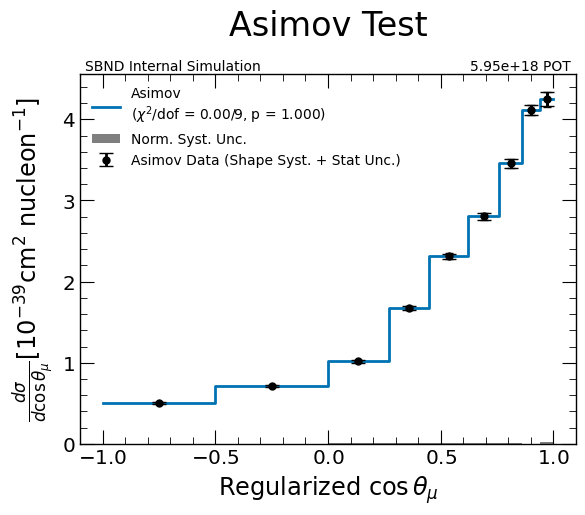

In [28]:
fig,ax = xsec_costheta.plot_unfold(names, model_labels, title='Asimov Test', label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('asimov_unfold_costheta',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

In [29]:
xsec_costheta.unfold_results['asimov']['fracunc_unfold_shape']*100

array([2.00196986, 1.77546327, 1.61430779, 1.65716609, 1.41318057,
       1.51564136, 1.52106264, 1.49443734, 2.04212484])

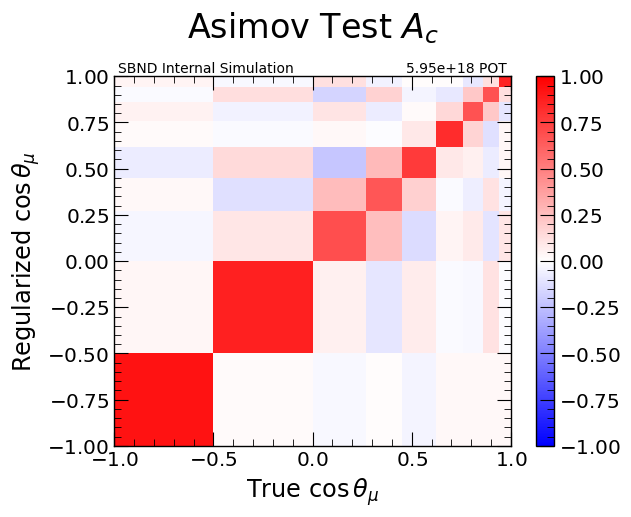

In [30]:
fig,ax = xsec_costheta.plot_smear('asimov', title=r'Asimov Test $A_c$', label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('asimov_ac_costheta',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

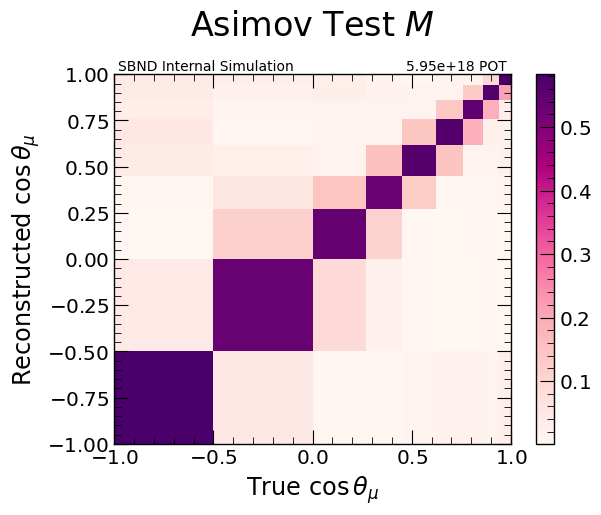

In [31]:
fig,ax = xsec_costheta.plot_response('asimov', title=r'Asimov Test $M$', label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('asimov_response_costheta',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

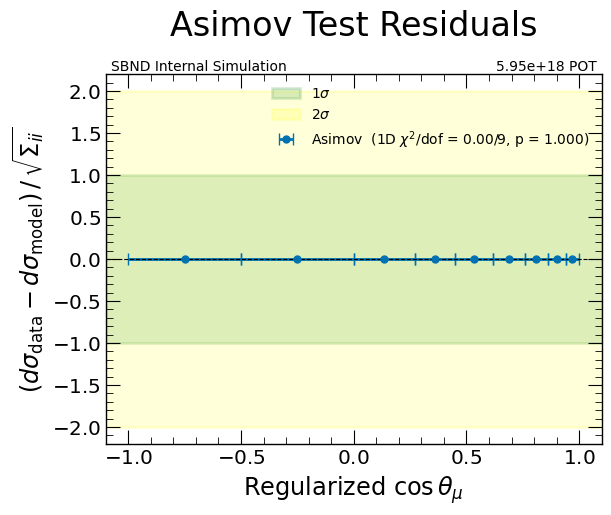

In [32]:
fig,ax = xsec_costheta.plot_residuals(names, model_labels, title='Asimov Test Residuals', label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('asimov_residuals_costheta',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

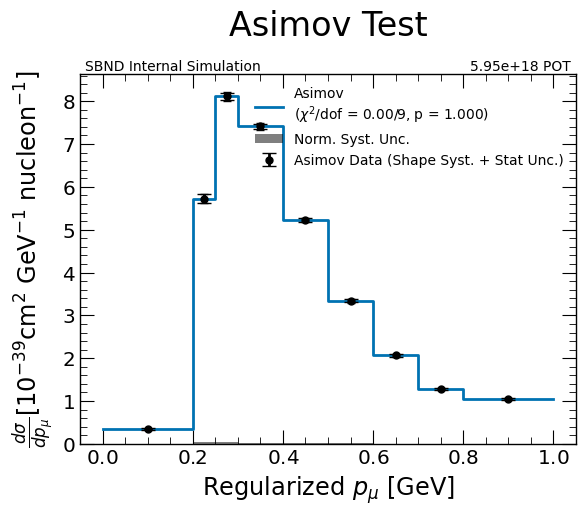

In [33]:
fig,ax = xsec_momentum.plot_unfold(names, model_labels, title='Asimov Test', label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('asimov_unfold_momentum',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

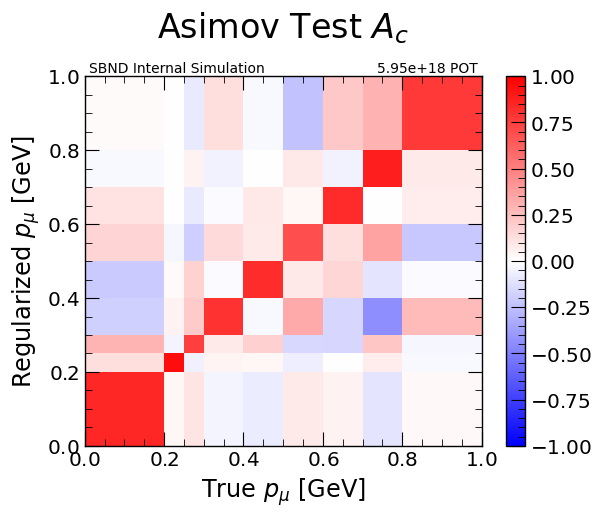

In [34]:
fig,ax = xsec_momentum.plot_smear('asimov', title=r'Asimov Test $A_c$', label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('asimov_ac_momentum',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

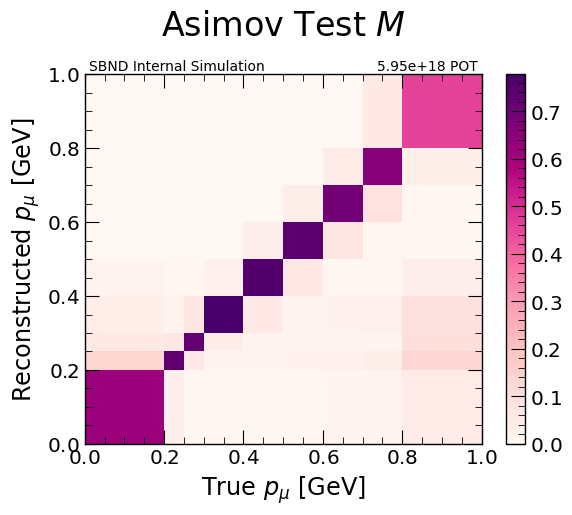

In [35]:
fig,ax = xsec_momentum.plot_response('asimov', title=r'Asimov Test $M$', label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('asimov_response_momentum',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

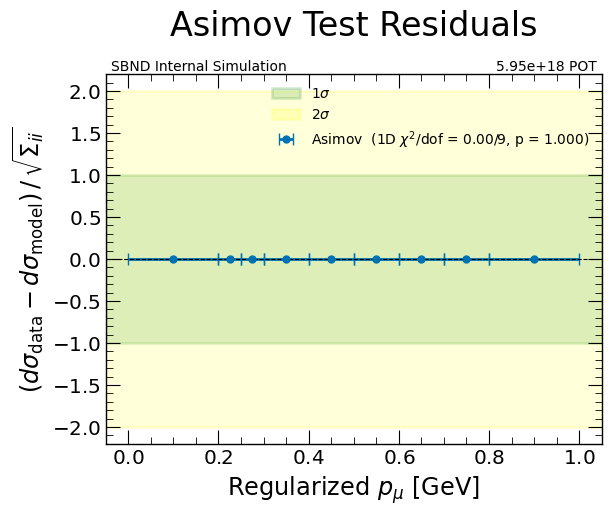

In [36]:
fig,ax = xsec_momentum.plot_residuals(names, model_labels, title='Asimov Test Residuals', label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('asimov_residuals_momentum',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

In [ ]:
xsec_differential.plot_unfold_2d(names, model_labels, binning2D, title='Asimov Test', label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('asimov_unfold_differential',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

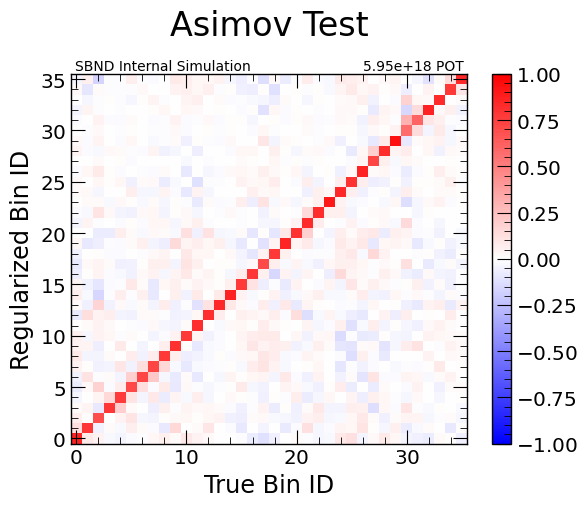

In [38]:
fig,ax = xsec_differential.plot_smear('asimov', title='Asimov Test', label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('asimov_ac_differential',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

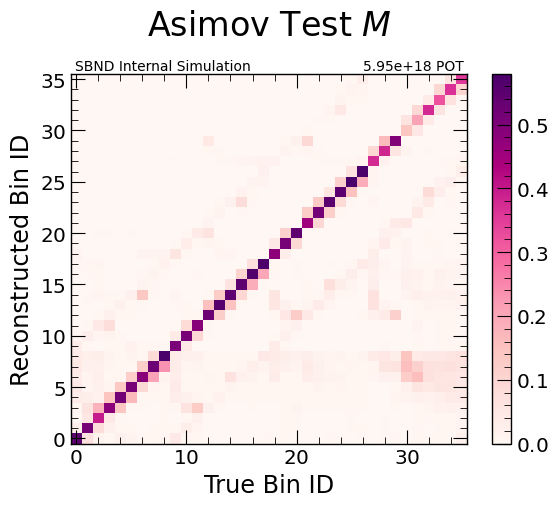

In [39]:
fig,ax = xsec_differential.plot_response('asimov', title=r'Asimov Test $M$', label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('asimov_response_differential',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

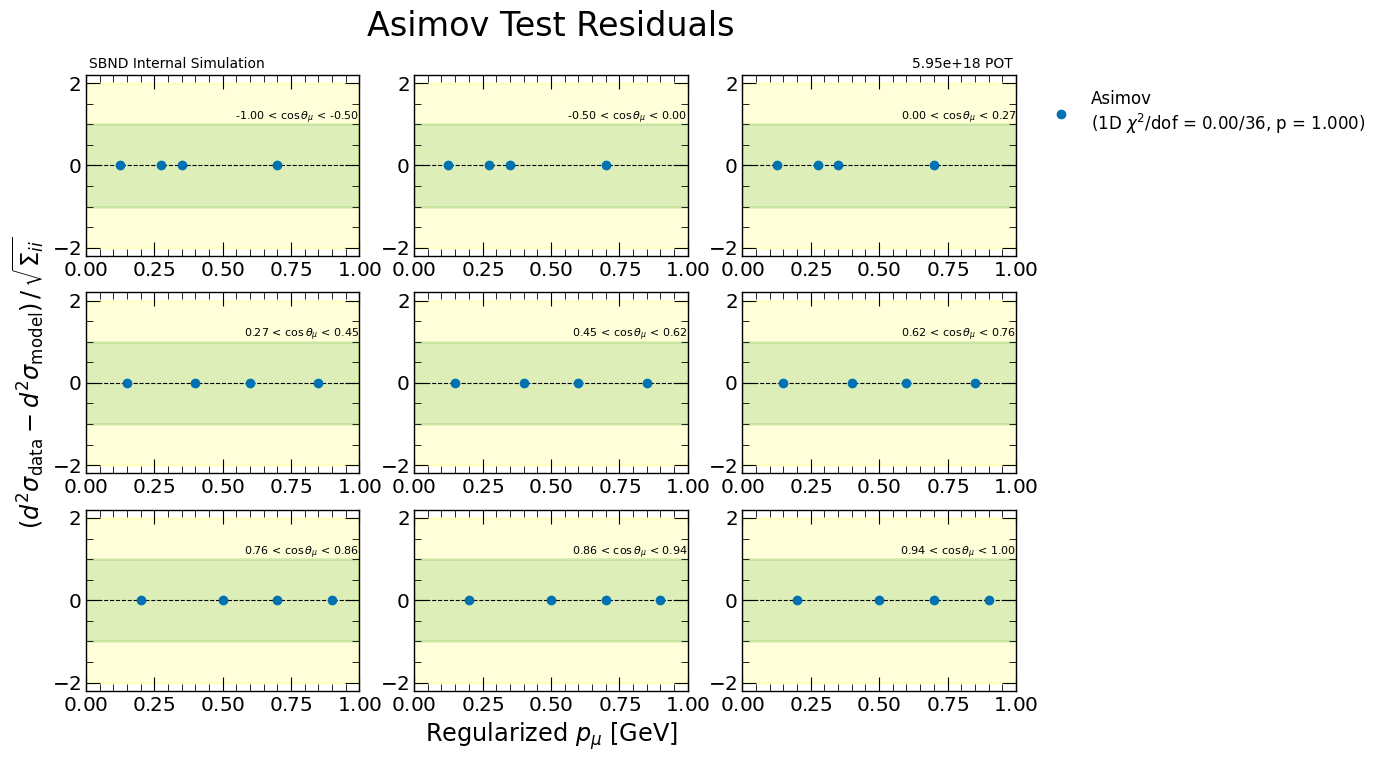

In [40]:
fig,ax = xsec_differential.plot_residuals_2d(names, model_labels, binning2D, title='Asimov Test Residuals', label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('asimov_residuals_differential',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

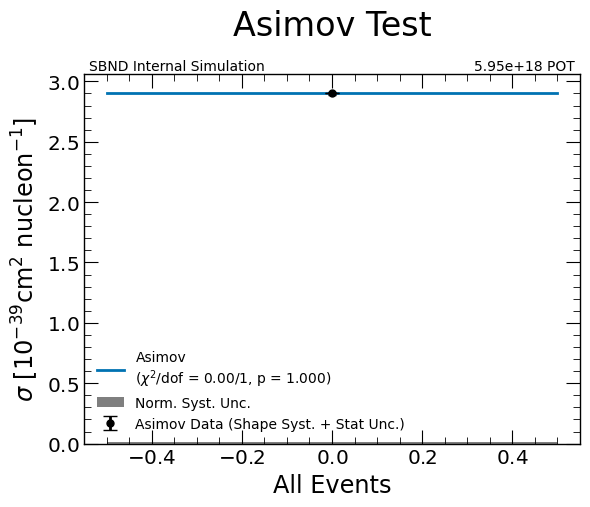

In [41]:
fig,ax = xsec_overall.plot_unfold(names, model_labels, title='Asimov Test', label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('asimov_unfold_overall',fig=fig,folder_name=f'{PLOT_DIR}/asimov')

### 2.2. Scale MEC (fake data)

In [42]:
mec_scale = 1.5

#Signal
mask = slc_mc_signal.data.truth.genie_mode == 10
# Variables
genweights_sig_mec = genweights_sig.copy()
genweights_sig_mec[mask]*=mec_scale

# Histograms
# --truth
costheta_sig_mec,_ = np.histogram(costheta_sig_vals,bins=costheta_bins,weights=genweights_sig_mec)
momentum_sig_mec,_ = np.histogram(momentum_sig_vals,bins=momentum_bins,weights=genweights_sig_mec)
diff_sig_mec,_ = np.histogram(diff_sig_vals,bins=binning2D.differential_edges,weights=genweights_sig_mec)
overall_sig_mec,_ = np.histogram(overall_sig_vals,bins=overall_bins,weights=genweights_sig_mec)

# --reco
costheta_sig_mec_reco,_ = np.histogram(costheta_sig_reco_vals,bins=costheta_bins,weights=genweights_sig_mec)
momentum_sig_mec_reco,_ = np.histogram(momentum_sig_reco_vals,bins=momentum_bins,weights=genweights_sig_mec)
diff_sig_mec_reco,_ = np.histogram(diff_sig_reco_vals,bins=binning2D.differential_edges,weights=genweights_sig_mec)
overall_sig_mec_reco,_ = np.histogram(overall_sig_reco_vals,bins=overall_bins,weights=genweights_sig_mec)

#Selected
mask = slc_mc_sel.data.truth.genie_mode == 10
# Variables
genweights_sel_mec = genweights_sel.copy()
genweights_sel_mec[mask]*=mec_scale

# Histograms
# --truth
costheta_sel_mec,_ = np.histogram(costheta_sel_vals,bins=costheta_bins,weights=genweights_sel_mec)
momentum_sel_mec,_ = np.histogram(momentum_sel_vals,bins=momentum_bins,weights=genweights_sel_mec)
diff_sel_mec,_ = np.histogram(diff_sel_vals,bins=binning2D.differential_edges,weights=genweights_sel_mec)
overall_sel_mec,_ = np.histogram(overall_sel_vals,bins=overall_bins,weights=genweights_sel_mec)

# --reco
costheta_sel_mec_reco,_ = np.histogram(costheta_sel_reco_vals,bins=costheta_bins,weights=genweights_sel_mec)
momentum_sel_mec_reco,_ = np.histogram(momentum_sel_reco_vals,bins=momentum_bins,weights=genweights_sel_mec)
diff_sel_mec_reco,_ = np.histogram(diff_sel_reco_vals,bins=binning2D.differential_edges,weights=genweights_sel_mec)
overall_sel_mec_reco,_ = np.histogram(overall_sel_reco_vals,bins=overall_bins,weights=genweights_sel_mec)

#Selected signal
m2 = np.isin(slc_mc_sel.data.truth.event_type,CATEGORIES)
#Variables
genweights_sel_sig_mec = genweights_sel_mec[m2]

# Histograms
# --truth
costheta_sel_sig_mec,_ = np.histogram(costheta_sel_sig_vals,bins=costheta_bins,weights=genweights_sel_sig_mec)
momentum_sel_sig_mec,_ = np.histogram(momentum_sel_sig_vals,bins=momentum_bins,weights=genweights_sel_sig_mec)
diff_sel_sig_mec,_ = np.histogram(diff_sel_sig_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig_mec)
overall_sel_sig_mec,_ = np.histogram(overall_sel_sig_vals,bins=overall_bins,weights=genweights_sel_sig_mec)

# --reco
costheta_sel_sig_mec_reco,_ = np.histogram(costheta_sel_sig_reco_vals,bins=costheta_bins,weights=genweights_sel_sig_mec)
momentum_sel_sig_mec_reco,_ = np.histogram(momentum_sel_sig_reco_vals,bins=momentum_bins,weights=genweights_sel_sig_mec)
diff_sel_sig_mec_reco,_ = np.histogram(diff_sel_sig_reco_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig_mec)
overall_sel_sig_mec_reco,_ = np.histogram(overall_sel_sig_reco_vals,bins=overall_bins,weights=genweights_sel_sig_mec)

# Selected background
# --truth
costheta_sel_bkg_mec = costheta_sel_mec - costheta_sel_sig_mec
momentum_sel_bkg_mec = momentum_sel_mec - momentum_sel_sig_mec
diff_sel_bkg_mec = diff_sel_mec - diff_sel_sig_mec
overall_sel_bkg_mec = overall_sel_mec - overall_sel_sig_mec

# --reco
costheta_sel_bkg_mec_reco = costheta_sel_mec_reco - costheta_sel_sig_mec_reco
momentum_sel_bkg_mec_reco = momentum_sel_mec_reco - momentum_sel_sig_mec_reco
diff_sel_bkg_mec_reco = diff_sel_mec_reco - diff_sel_sig_mec_reco
overall_sel_bkg_mec_reco = overall_sel_mec_reco - overall_sel_sig_mec_reco

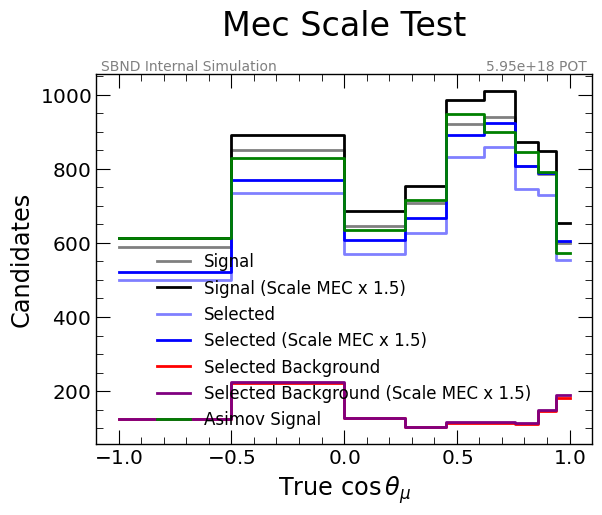

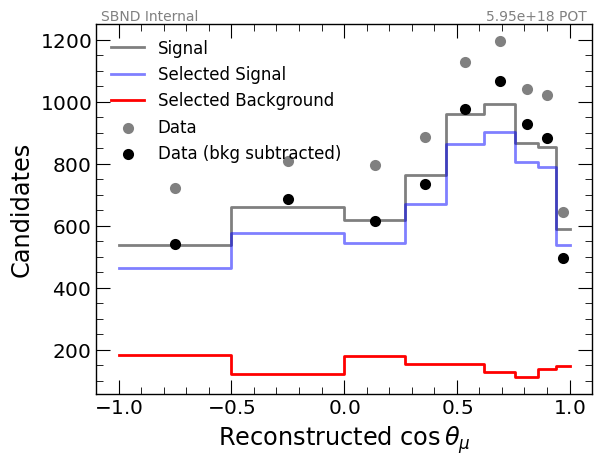

In [43]:
#Check the scaled distributions - costheta
## -truth
fig,ax = plt.subplots()

makeplot.plot_hist_edges(costheta_bins,costheta_sig,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sig_mec,errors=None,label=f'Signal (Scale MEC x {mec_scale})',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig_mec,errors=None,label=f'Selected (Scale MEC x {mec_scale})',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg,errors=None,label='Selected Background',ax=ax,color='red',alpha=1.)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg_mec,errors=None,label=f'Selected Background (Scale MEC x {mec_scale})',ax=ax,color='purple',alpha=1)
makeplot.plot_hist_edges(costheta_bins,csystematics_rw.sig_truth,errors=None,label=f'Asimov Signal',ax=ax,color='green',alpha=1)

ax.legend()
ax.set_xlabel(r'True $\cos\theta_\mu$')
ax.set_ylabel(r'Candidates')
ax.set_title('Mec Scale Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside',color='gray')
plotters.save_plot('mec_scale_eventrate_costheta_truth',fig=fig,folder_name=f'{PLOT_DIR}/mec')

## reco
fig,ax = plt.subplots()

makeplot.plot_hist_edges(costheta_bins,costheta_sig_reco,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
#makeplot.plot_hist_edges(costheta_bins,costheta_sig_mec_reco,errors=None,label=f'Signal (Scale MEC x {mec_scale})',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig_reco,errors=None,label='Selected Signal',ax=ax,color='blue',alpha=0.5)
#makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig_mec_reco,errors=None,label=f'Selected (Scale MEC x {mec_scale})',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg_reco,errors=None,label='Selected Background',ax=ax,color='red',alpha=1.)
#makeplot.plot_hist_edges(costheta_bins,csystematics_rw.sel,errors=None,label=f'Asimov Selected',ax=ax,color='green',alpha=1)
#makeplot.plot_hist_edges(costheta_bins,csystematics_rw.sel_background,errors=None,label=f'Asimov Background',ax=ax,color='orange',alpha=1)
ax.scatter((costheta_bins[1:]+costheta_bins[:-1])/2,costheta_sel_data,label=f'Data',color='gray',alpha=1)
ax.scatter((costheta_bins[1:]+costheta_bins[:-1])/2,costheta_sel_sig_data,label=f'Data (bkg subtracted)',color='black',alpha=1)

ax.legend()
ax.set_xlabel(r'Reconstructed $\cos\theta_\mu$')
ax.set_ylabel(r'Candidates')
#ax.set_title('Mec Scale Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_DATA_LABEL,where='topleftoutside',color='gray')
#plotters.save_plot('mec_scale_eventrate_costheta_reco',fig=fig,folder_name=f'{PLOT_DIR}/mec')

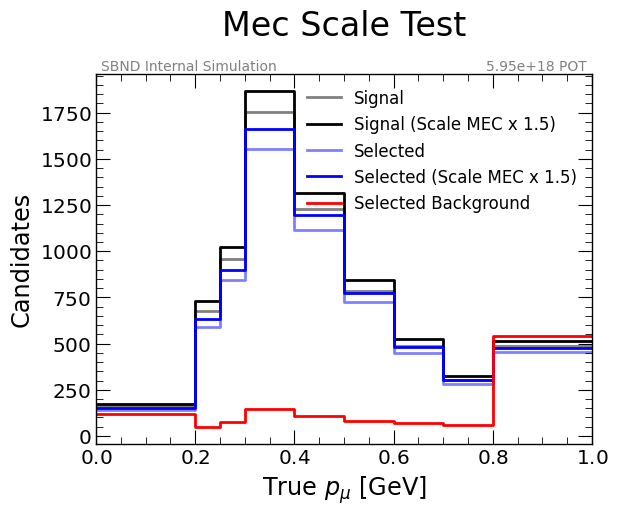

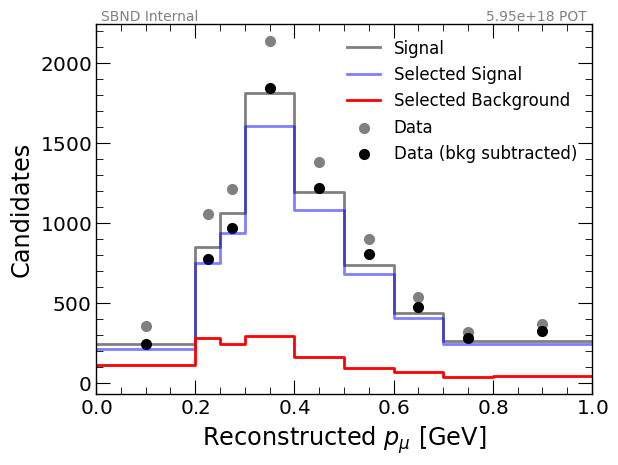

In [44]:
# Check the scaled distributions - momentum
## -truth
fig,ax = plt.subplots()

makeplot.plot_hist_edges(momentum_bins,momentum_sig,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sig_mec,errors=None,label=f'Signal (Scale MEC x {mec_scale})',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig_mec,errors=None,label=f'Selected (Scale MEC x {mec_scale})',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg,errors=None,label='Selected Background',ax=ax,color='red',alpha=1.)

ax.set_xlim(0,MAX_PMOM)
ax.legend()
ax.set_xlabel(r'True $p_\mu$ [GeV]')
ax.set_ylabel(r'Candidates')
ax.set_title('Mec Scale Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside',color='gray')
plotters.save_plot('mec_scale_eventrate_momentum_truth',fig=fig,folder_name=f'{PLOT_DIR}/mec')

## reco
fig,ax = plt.subplots()

makeplot.plot_hist_edges(momentum_bins,momentum_sig_reco,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
#makeplot.plot_hist_edges(momentum_bins,momentum_sig_mec_reco,errors=None,label=f'Signal (Scale MEC x {mec_scale})',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig_reco,errors=None,label='Selected Signal',ax=ax,color='blue',alpha=0.5)
#makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig_mec_reco,errors=None,label=f'Selected (Scale MEC x {mec_scale})',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg_reco,errors=None,label='Selected Background',ax=ax,color='red',alpha=1.)
ax.scatter((mbins[1:]+mbins[:-1])/2,momentum_sel_data,label=f'Data',color='gray',alpha=1)
ax.scatter((mbins[1:]+mbins[:-1])/2,momentum_sel_sig_data,label=f'Data (bkg subtracted)',color='black',alpha=1)

ax.set_xlim(0,MAX_PMOM)
ax.legend()
ax.set_xlabel(r'Reconstructed $p_\mu$ [GeV]')
ax.set_ylabel(r'Candidates')
#ax.set_title('Mec Scale Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_DATA_LABEL,where='topleftoutside',color='gray')
#plotters.save_plot('mec_scale_eventrate_momentum_reco',fig=fig,folder_name=f'{PLOT_DIR}/mec')

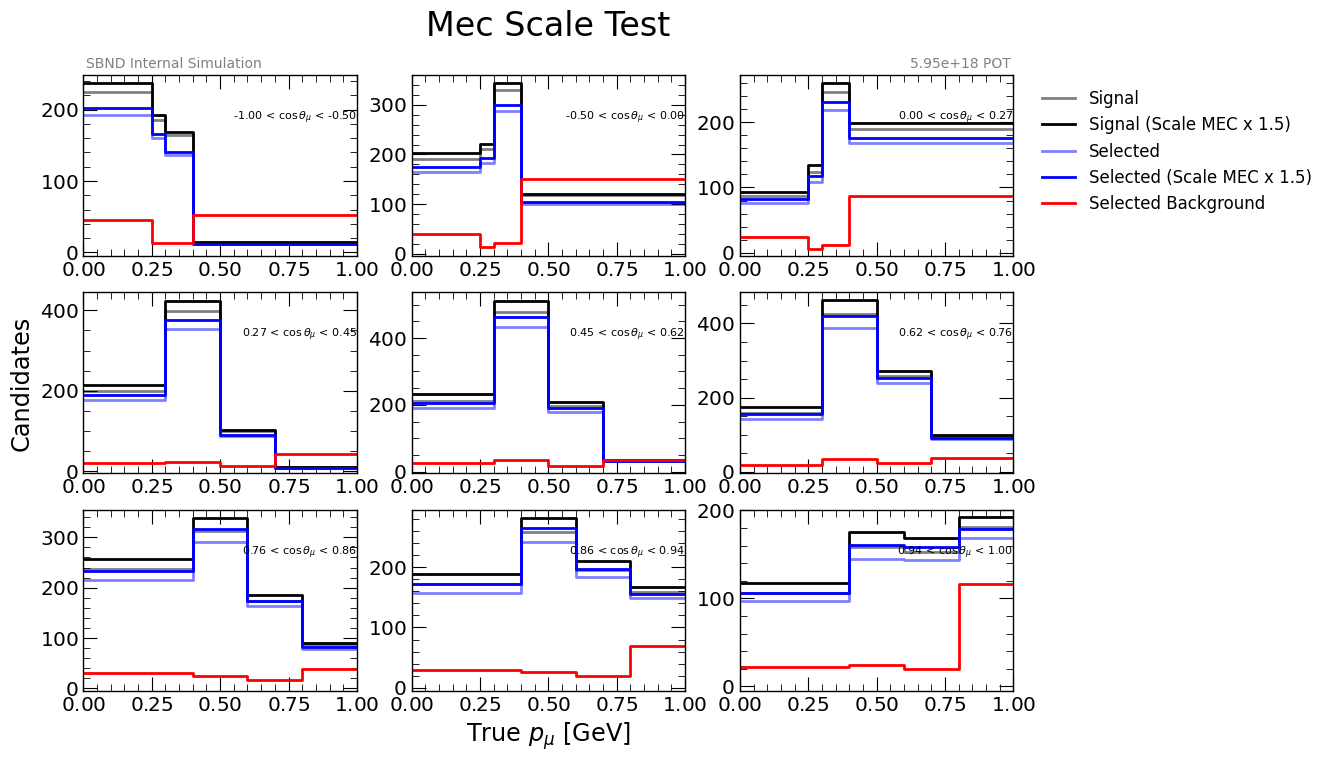

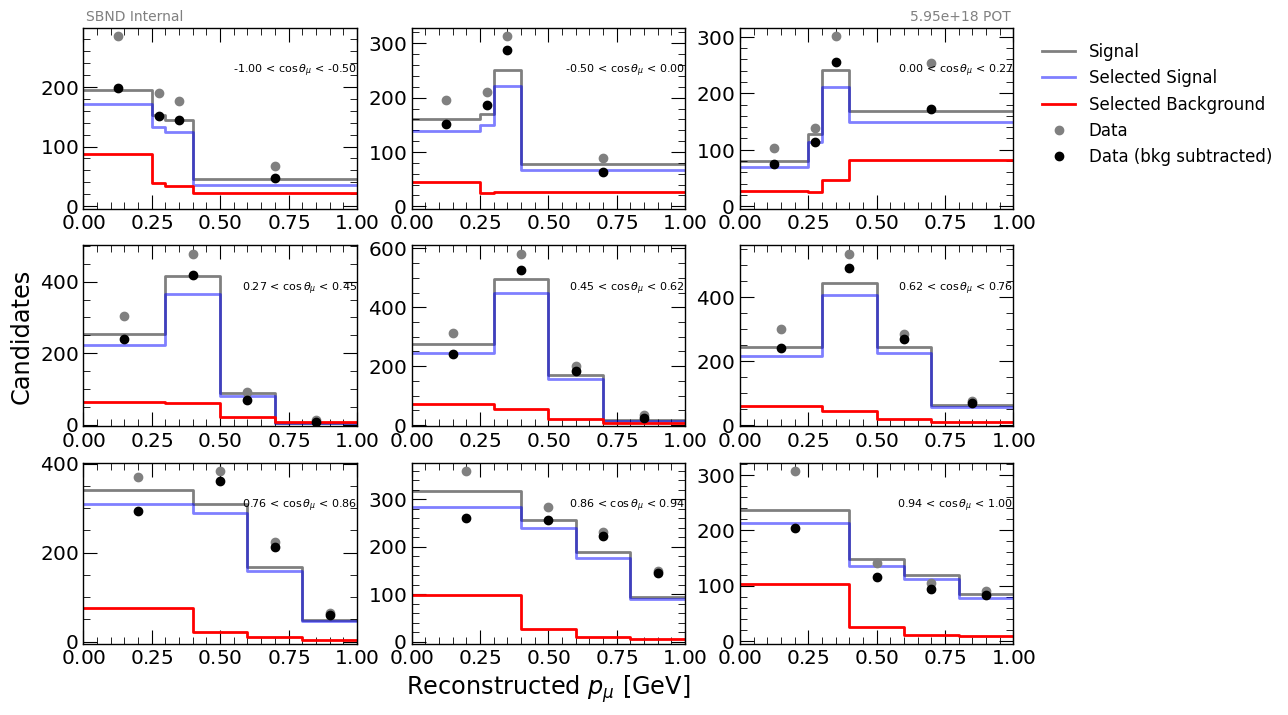

In [45]:
# Check the scaled distributions - differential
# --truth
fig,axs = binning2D.plot_differential_hist_binned(diff_sig,yerrs=None,label='Signal',color='black',alpha=0.5)
fig,axs = binning2D.plot_differential_hist_binned(diff_sig_mec,yerrs=None,label=f'Signal (Scale MEC x {mec_scale})',color='black',alpha=1,fig=fig,axs=axs)
#fig,axs = binning2D.plot_differential_hist_binned(dsystematics_rw.sig_truth,yerrs=None,label=f'Signal',color='black',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig,yerrs=None,label='Selected',color='blue',alpha=0.5,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig_mec,yerrs=None,label=f'Selected (Scale MEC x {mec_scale})',color='blue',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_bkg,yerrs=None,label='Selected Background',color='red',alpha=1,fig=fig,axs=axs,
  xlabel=r'True $p_\mu$ [GeV]',ylabel=r'Candidates',add_labels=True,legend=True)

axs[0,1].set_title('Mec Scale Test')
for ax in axs.flatten():
  ylims = ax.get_ylim()
  ax.set_ylim(-5,None)
plotters.add_label(axs[0,2],POT_LABEL,where='toprightoutsidepad',color='gray')
plotters.add_label(axs[0,0],INTERNAL_LABEL,where='topleftoutsidepad',color='gray')
plotters.save_plot('mec_scale_eventrate_differential_truth',fig=fig,folder_name=f'{PLOT_DIR}/mec')

#--reco
fig,axs = binning2D.plot_differential_hist_binned(diff_sig_reco,yerrs=None,label='Signal',color='black',alpha=0.5)
#fig,axs = binning2D.plot_differential_hist_binned(diff_sig_mec_reco,yerrs=None,label=f'Signal (Scale MEC x {mec_scale})',color='black',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig_reco,yerrs=None,label='Selected Signal',color='blue',alpha=0.5,fig=fig,axs=axs)
#fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig_mec_reco,yerrs=None,label=f'Selected (Scale MEC x {mec_scale})',color='blue',alpha=1,fig=fig,axs=axs)  
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_bkg_reco,yerrs=None,label='Selected Background',color='red',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_scatter_binned(diff_sel_data,yerrs=None,label='Data',color='gray',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_scatter_binned(diff_sel_sig_data,yerrs=None,label='Data (bkg subtracted)',color='black',alpha=1,fig=fig,axs=axs,
  xlabel=r'Reconstructed $p_\mu$ [GeV]',ylabel=r'Candidates',add_labels=True,legend=True)

#axs[0,1].set_title('Mec Scale Test')
for ax in axs.flatten():
  ylims = ax.get_ylim()
  ax.set_ylim(-5,None)
plotters.add_label(axs[0,2],POT_LABEL,where='toprightoutsidepad',color='gray')
plotters.add_label(axs[0,0],INTERNAL_DATA_LABEL,where='topleftoutsidepad',color='gray')
#plotters.save_plot('mec_scale_eventrate_differential_reco',fig=fig,folder_name=f'{PLOT_DIR}/mec')

In [46]:
#Costheta
fracxsec_cov_costheta_mec = (csystematics_rw.systematics['xsec']['xsec_fraccov'] \
  + csystematics_rw.systematics['stat']['xsec_fraccov'])
xsec_cov_stat_costheta_mec = csystematics_rw.systematics['stat']['xsec_fraccov']

xsec_costheta.unfold(fracxsec_cov_costheta_mec, #fractional covariance
  costheta_sel_sig_mec_reco, #selected signal
  costheta_sig_mec, #truth signal
  costheta_sel_bkg_mec_reco, #selected background
  name='mec',
  response=xsec_costheta.unfold_results['asimov']['response'],
  stat_cov=xsec_cov_stat_costheta_mec,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=True,
  tikhonov=tikhonov)

fracxsec_cov_momentum_mec = (msystematics_rw.systematics['xsec']['xsec_fraccov'] \
  + msystematics_rw.systematics['stat']['xsec_fraccov'])
xsec_cov_stat_momentum_mec = msystematics_rw.systematics['stat']['xsec_fraccov']

#Overall
xsec_cov_overall_mec = np.array([[np.sum(xsec_costheta.unfold_results['mec']['input_cov'])]])
xsec_cov_stat_overall_mec = np.array([[np.sum(xsec_costheta.unfold_results['mec']['input_stat_cov'])]])

xsec_overall.unfold(xsec_cov_overall_mec, #covariance
  overall_sel_sig_mec_reco, #selected signal
  overall_sig_mec, #truth signal
  overall_sel_bkg_mec, #selected background
  name='mec',
  response=xsec_overall.unfold_results['asimov']['response'],
  stat_cov=xsec_cov_stat_overall_mec,
  C_type=C_type, Norm_type=Norm_type,verbose=True,fractional_cov=False,
  tikhonov=tikhonov)
# Momentum
xsec_momentum.unfold(fracxsec_cov_momentum_mec, #fractional covariance
  momentum_sel_sig_mec_reco, #selected signal
  momentum_sig_mec, #truth signal
  momentum_sel_bkg_mec, #selected background
  name='mec',
  response=xsec_momentum.unfold_results['asimov']['response'],
  stat_cov=xsec_cov_stat_momentum_mec,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=True,
  tikhonov=tikhonov)

fracxsec_cov_differential_mec = (dsystematics_rw.systematics['xsec']['xsec_fraccov'] \
  + dsystematics_rw.systematics['stat']['xsec_fraccov'])[1:,1:]
xsec_cov_stat_differential_mec = dsystematics_rw.systematics['stat']['xsec_fraccov'][1:,1:]

xsec_differential.unfold(fracxsec_cov_differential_mec, #fractional covariance
  diff_sel_sig_mec_reco, #selected signal
  diff_sig_mec, #truth signal
  diff_sel_bkg_mec, #selected background
  name='mec',
  response=xsec_differential.unfold_results['asimov']['response'],
  stat_cov=xsec_cov_stat_differential_mec,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=True,
  tikhonov=tikhonov)

# Variables for plotting
names = ['mec','asimov']
model_labels = ['Mec Test','Asimov Truth']
title=f'MEC Scale x {mec_scale}'
data_label = 'MEC Data'

sig: [3.10096691e-39]
sel: [2.79035404e-39]
response shape: (1, 1)
sig@response: [2.78817352e-39]
sig@response - sel: [-2.18052592e-42]
sqrt(cov diag): [1.05150326e-40]
sqrt(cov diag)/sel*100: [3.76835069]
sigma_tilde: [3.35713896e-39]
xsec_unit: 4.242545575082938e-43
bins: [-0.5  0.5]
bin_widths: [1.]
sig_unfold_bw: [3.09898447e-39]
sig_smear_bw: [3.09656277e-39]
unfold cov diag: [1.36377092e-80]
- Dropping 0 bins with pred or true values less than -inf
cov eigenvalues: min=1.363771e-80 max=1.363771e-80 cond=1.000000e+00
    eigvalue 0: 1.36e-80
  pinv_rcond=0.0001 -> drop eig < 1.363771e-84 (0 modes)
  retained variance: 1.000000e+00
inv_cov = [[7.33260981e+79]]
inv_cov diagonal: [7.33260981e+79]
diff**2 = [5.86465792e-84]
diff = [2.42170558e-42]
inv_cov @ diff**2 = [0.00043003]
chi2_val = 0.00043003248225433435
- Dropping 0 bins with pred or true values less than -inf
Mode-space chi2 diagnostics for unfold result
  sum(mode_chi2) = 0.000430  (sum in eigenbasis = 0.000430)
  mode  ei

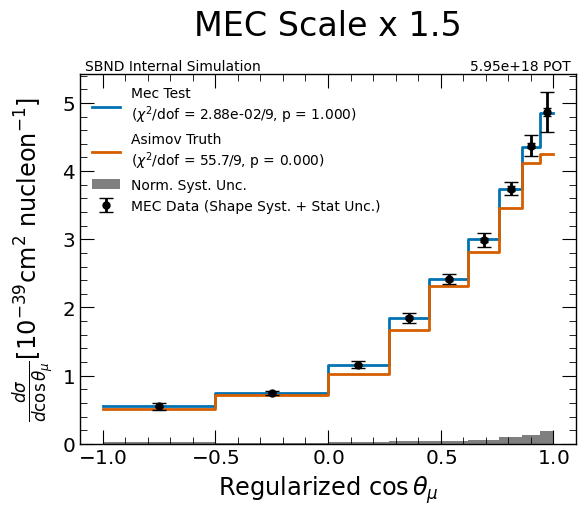

In [47]:
fig,ax = xsec_costheta.plot_unfold(names, model_labels, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('mec_unfold_costheta',fig=fig,folder_name=f'{PLOT_DIR}/mec')

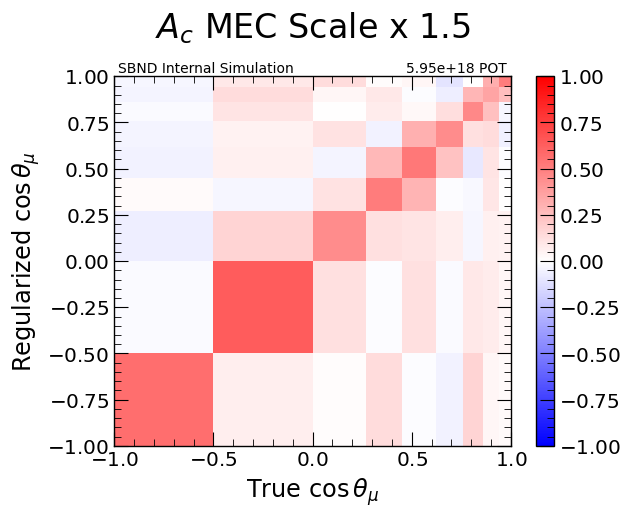

In [48]:
#Plot smearing matrix
fig,ax = xsec_costheta.plot_smear('mec', title=r'$A_c$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('mec_ac_costheta',fig=fig,folder_name=f'{PLOT_DIR}/mec')


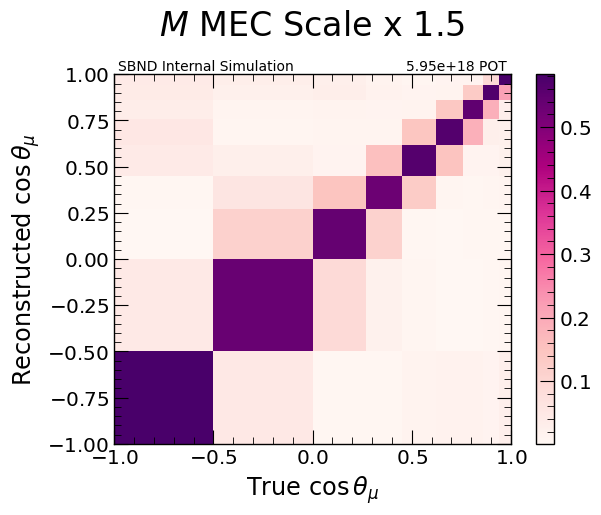

In [49]:
fig,ax = xsec_costheta.plot_response('mec', title=r'$M$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('mec_response_costheta',fig=fig,folder_name=f'{PLOT_DIR}/mec')


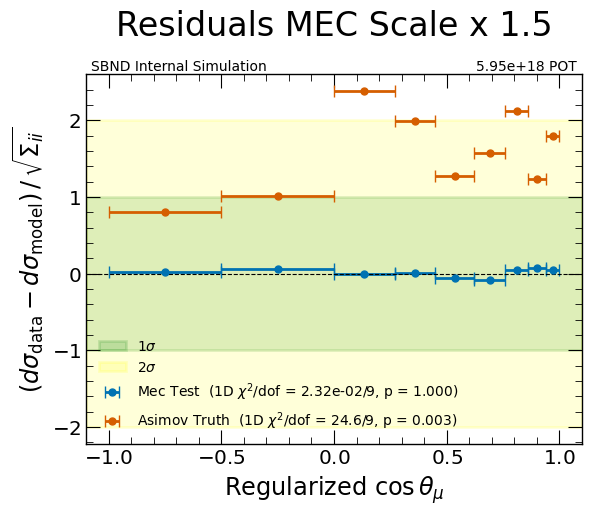

In [50]:
fig,ax = xsec_costheta.plot_residuals(names,model_labels, title='Residuals ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('mec_residuals_costheta',fig=fig,folder_name=f'{PLOT_DIR}/mec')

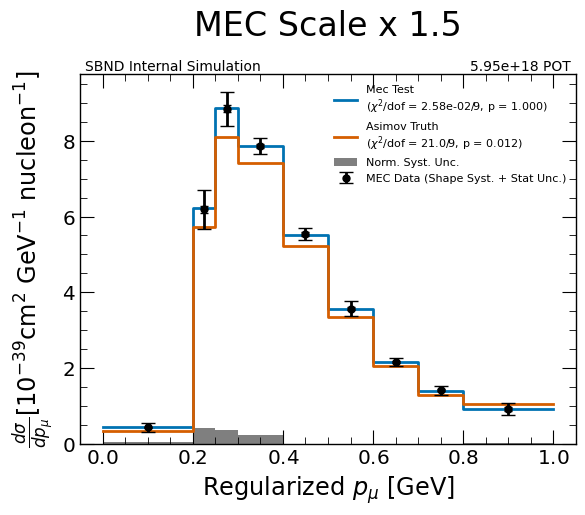

In [51]:
fig,ax = xsec_momentum.plot_unfold(names, model_labels, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label,legend_fontsize=8)
plotters.save_plot('mec_unfold_momentum',fig=fig,folder_name=f'{PLOT_DIR}/mec')

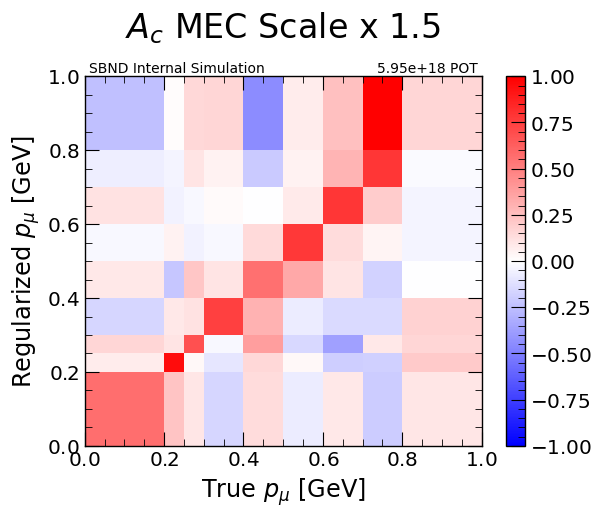

In [52]:
fig,ax = xsec_momentum.plot_smear('mec', title=r'$A_c$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('mec_ac_momentum',fig=fig,folder_name=f'{PLOT_DIR}/mec')

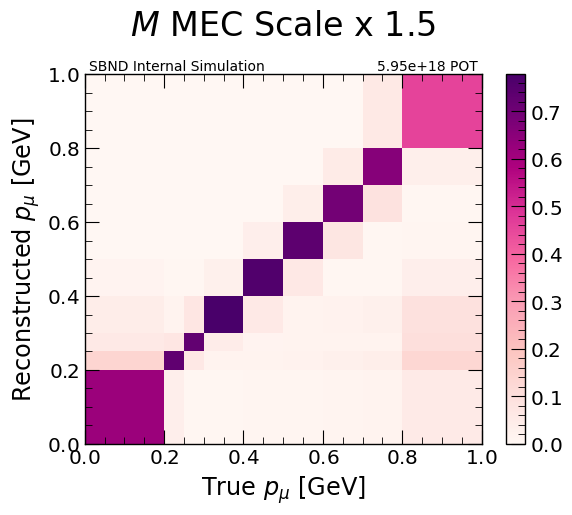

In [53]:
fig,ax = xsec_momentum.plot_response('mec', title=r'$M$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('mec_response_momentum',fig=fig,folder_name=f'{PLOT_DIR}/mec')

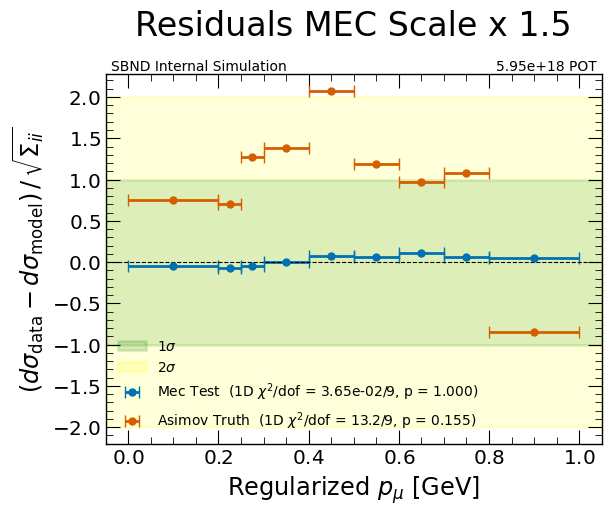

In [54]:
fig,ax = xsec_momentum.plot_residuals(names,model_labels, title='Residuals ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL, verbose=False)
plotters.save_plot('mec_residuals_momentum',fig=fig,folder_name=f'{PLOT_DIR}/mec')

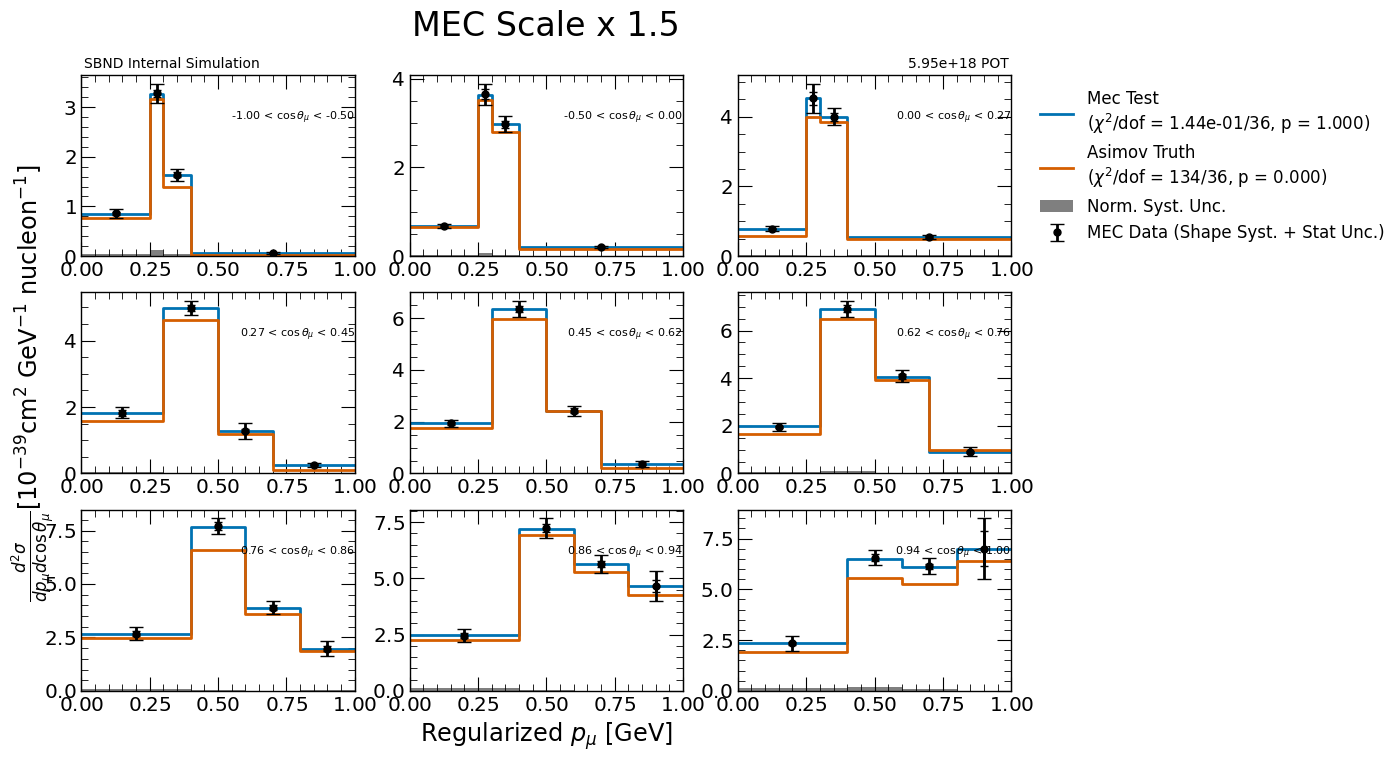

In [55]:
fig,axs = xsec_differential.plot_unfold_2d(names, model_labels, binning2D, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('mec_unfold_differential',fig=fig,folder_name=f'{PLOT_DIR}/mec')

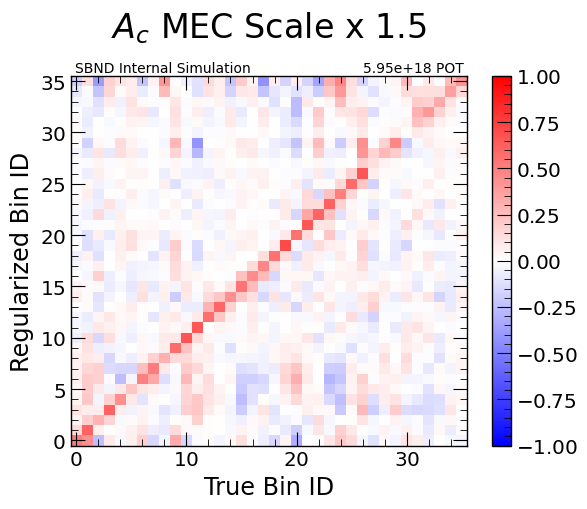

In [56]:
fig,ax = xsec_differential.plot_smear('mec', title=r'$A_c$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('mec_ac_differential',fig=fig,folder_name=f'{PLOT_DIR}/mec')

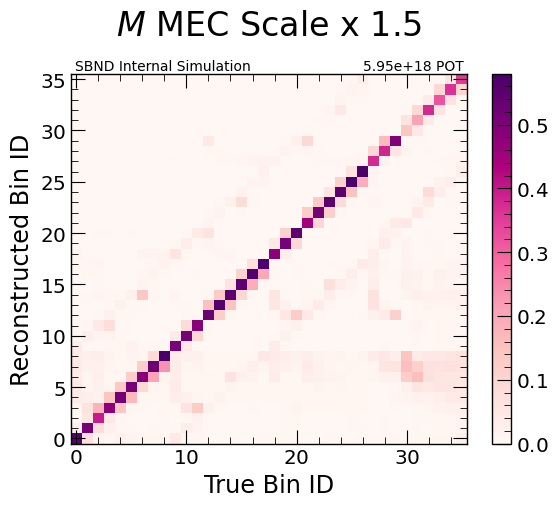

In [57]:
fig,ax = xsec_differential.plot_response('mec', title=r'$M$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('mec_response_differential',fig=fig,folder_name=f'{PLOT_DIR}/mec')

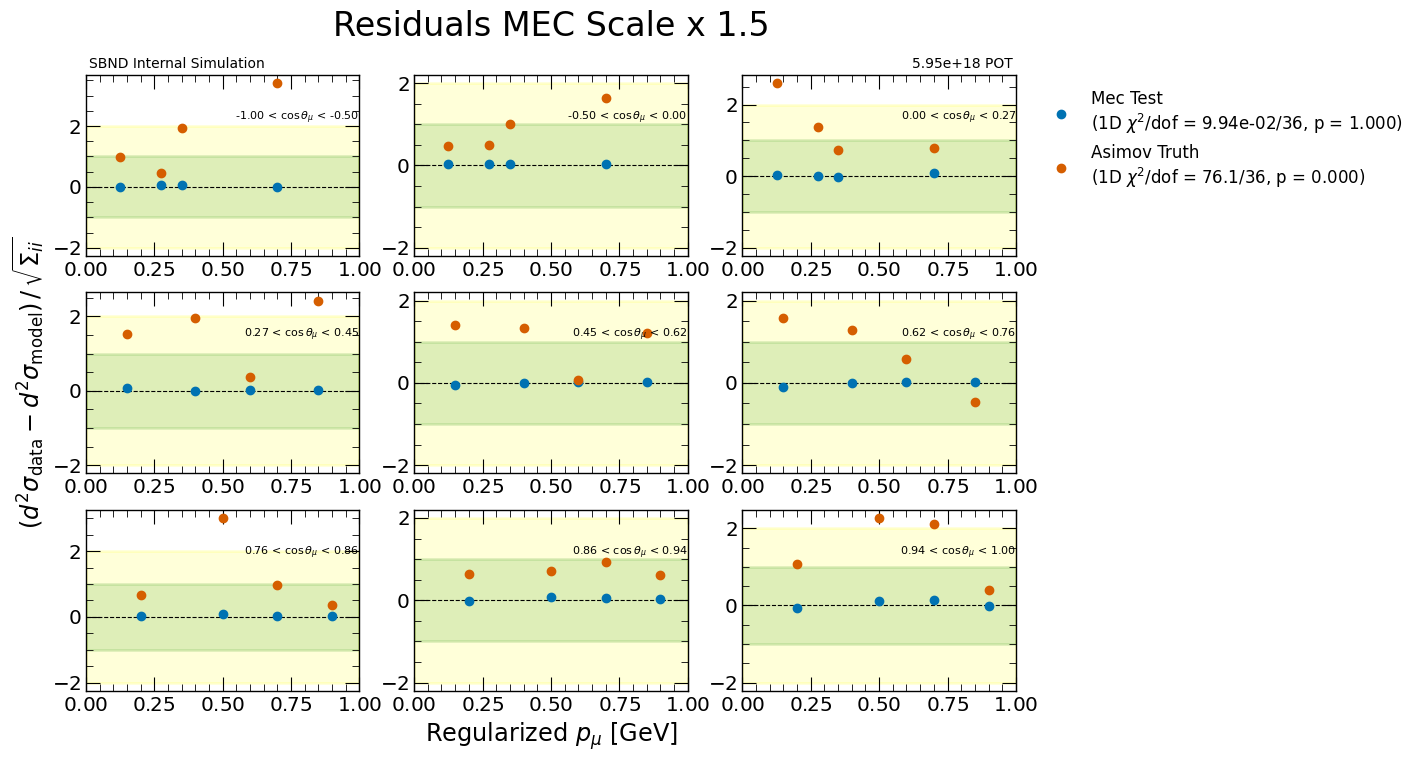

In [58]:
fig,ax = xsec_differential.plot_residuals_2d(names,model_labels,binning2D, title='Residuals ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL, verbose=False)
plotters.save_plot('mec_residuals_differential',fig=fig,folder_name=f'{PLOT_DIR}/mec')

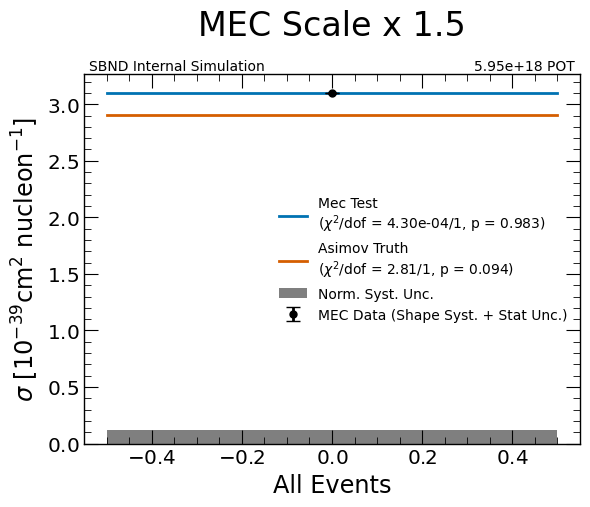

In [59]:
fig,ax = xsec_overall.plot_unfold(names, model_labels, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('mec_unfold_overall',fig=fig,folder_name=f'{PLOT_DIR}/mec')

In [60]:
xsec_overall.unfold_results['asimov']['fracunc_unfold_stat'],xsec_overall.unfold_results['asimov']['fracunc_unfold_shape'],xsec_overall.unfold_results['asimov']['fracunc_unfold_norm']

(array([0.00419682]), array([0.]), array([0.00419682]))

### 2.3. Scale QE (fake data)

In [61]:
qe_scale = 1.5

#Signal
mask = slc_mc_signal.data.truth.genie_mode == 1
col = slc_mc_signal.get_key('genweight')
# Variables
genweights_sig_qe = genweights_sig.copy()
genweights_sig_qe[mask]*=qe_scale
# Histograms
# --truth
costheta_sig_qe,_ = np.histogram(costheta_sig_vals,bins=costheta_bins,weights=genweights_sig_qe)
momentum_sig_qe,_ = np.histogram(momentum_sig_vals,bins=momentum_bins,weights=genweights_sig_qe)
diff_sig_qe,_ = np.histogram(diff_sig_vals,bins=binning2D.differential_edges,weights=genweights_sig_qe)
overall_sig_qe,_ = np.histogram(overall_sig_vals,bins=overall_bins,weights=genweights_sig_qe)

# --reco
costheta_sig_qe_reco,_ = np.histogram(costheta_sig_reco_vals,bins=costheta_bins,weights=genweights_sig_qe)
momentum_sig_qe_reco,_ = np.histogram(momentum_sig_reco_vals,bins=momentum_bins,weights=genweights_sig_qe)
diff_sig_qe_reco,_ = np.histogram(diff_sig_reco_vals,bins=binning2D.differential_edges,weights=genweights_sig_qe)
overall_sig_qe_reco,_ = np.histogram(overall_sig_reco_vals,bins=overall_bins,weights=genweights_sig_qe)

#Selected
mask = slc_mc_sel.data.truth.genie_mode == 1
col = slc_mc_sel.get_key('genweight')
# Variables
genweights_sel_qe = genweights_sel.copy()
genweights_sel_qe[mask]*=qe_scale

# Histograms
# --truth
costheta_sel_qe,_ = np.histogram(costheta_sel_vals,bins=costheta_bins,weights=genweights_sel_qe)
momentum_sel_qe,_ = np.histogram(momentum_sel_vals,bins=momentum_bins,weights=genweights_sel_qe)
diff_sel_qe,_ = np.histogram(diff_sel_vals,bins=binning2D.differential_edges,weights=genweights_sel_qe)
overall_sel_qe,_ = np.histogram(overall_sel_vals,bins=overall_bins,weights=genweights_sel_qe)

# --reco
costheta_sel_qe_reco,_ = np.histogram(costheta_sel_reco_vals,bins=costheta_bins,weights=genweights_sel_qe)
momentum_sel_qe_reco,_ = np.histogram(momentum_sel_reco_vals,bins=momentum_bins,weights=genweights_sel_qe)
diff_sel_qe_reco,_ = np.histogram(diff_sel_reco_vals,bins=binning2D.differential_edges,weights=genweights_sel_qe)
overall_sel_qe_reco,_ = np.histogram(overall_sel_reco_vals,bins=overall_bins,weights=genweights_sel_qe)

#Selected signal
m2 = np.isin(slc_mc_sel.data.truth.event_type,CATEGORIES)
#Variables
genweights_sel_sig_qe = genweights_sel_qe[m2]
# Histograms
# --truth
costheta_sel_sig_qe,_ = np.histogram(costheta_sel_sig_vals,bins=costheta_bins,weights=genweights_sel_sig_qe)
momentum_sel_sig_qe,_ = np.histogram(momentum_sel_sig_vals,bins=momentum_bins,weights=genweights_sel_sig_qe)
diff_sel_sig_qe,_ = np.histogram(diff_sel_sig_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig_qe)
overall_sel_sig_qe,_ = np.histogram(overall_sel_sig_vals,bins=overall_bins,weights=genweights_sel_sig_qe)

costheta_sel_sig,_ = np.histogram(costheta_sel_sig_vals,bins=costheta_bins,weights=genweights_sel_sig)
momentum_sel_sig,_ = np.histogram(momentum_sel_sig_vals,bins=momentum_bins,weights=genweights_sel_sig)
diff_sel_sig,_ = np.histogram(diff_sel_sig_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig)
overall_sel_sig,_ = np.histogram(overall_sel_sig_vals,bins=overall_bins,weights=genweights_sel_sig)

# --reco
costheta_sel_sig_qe_reco,_ = np.histogram(costheta_sel_sig_reco_vals,bins=costheta_bins,weights=genweights_sel_sig_qe)
momentum_sel_sig_qe_reco,_ = np.histogram(momentum_sel_sig_reco_vals,bins=momentum_bins,weights=genweights_sel_sig_qe)
diff_sel_sig_qe_reco,_ = np.histogram(diff_sel_sig_reco_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig_qe)
overall_sel_sig_qe_reco,_ = np.histogram(overall_sel_sig_reco_vals,bins=overall_bins,weights=genweights_sel_sig_qe)

# Selected background
# --truth
costheta_sel_bkg_qe = costheta_sel_qe - costheta_sel_sig_qe
momentum_sel_bkg_qe = momentum_sel_qe - momentum_sel_sig_qe
diff_sel_bkg_qe = diff_sel_qe - diff_sel_sig_qe
overall_sel_bkg_qe = overall_sel_qe - overall_sel_sig_qe
# --reco
costheta_sel_bkg_qe_reco = costheta_sel_qe_reco - costheta_sel_sig_qe_reco
momentum_sel_bkg_qe_reco = momentum_sel_qe_reco - momentum_sel_sig_qe_reco
diff_sel_bkg_qe_reco = diff_sel_qe_reco - diff_sel_sig_qe_reco
overall_sel_bkg_qe_reco = overall_sel_qe_reco - overall_sel_sig_qe_reco

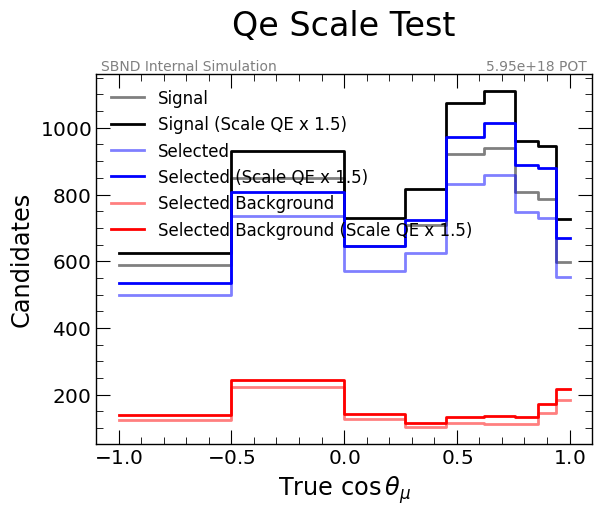

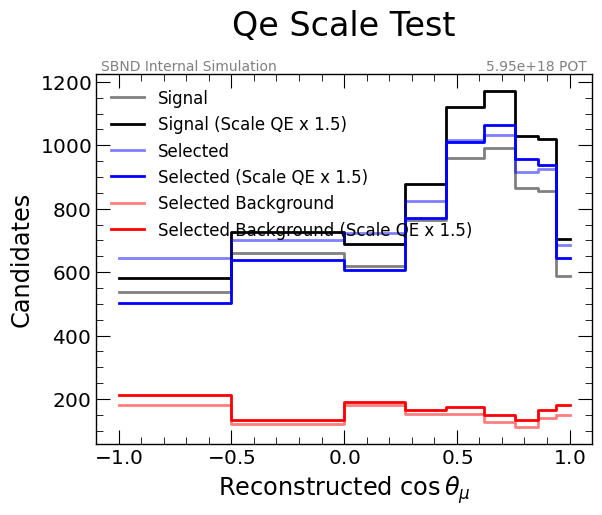

In [62]:
#Check the scaled distributions - costheta
# --truth
fig,ax = plt.subplots()

makeplot.plot_hist_edges(costheta_bins,costheta_sig,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sig_qe,errors=None,label=f'Signal (Scale QE x {qe_scale})',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig_qe,errors=None,label=f'Selected (Scale QE x {qe_scale})',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg,errors=None,label='Selected Background',ax=ax,color='red',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg_qe,errors=None,label=f'Selected Background (Scale QE x {qe_scale})',ax=ax,color='red',alpha=1)

ax.legend()
ax.set_xlabel(r'True $\cos\theta_\mu$')
ax.set_ylabel(r'Candidates')
ax.set_title(f'Qe Scale Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside',color='gray')
plotters.save_plot('qe_scale_eventrate_costheta_truth',fig=fig,folder_name=f'{PLOT_DIR}/qe')

# --reco
fig,ax = plt.subplots()

makeplot.plot_hist_edges(costheta_bins,costheta_sig_reco,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sig_qe_reco,errors=None,label=f'Signal (Scale QE x {qe_scale})',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_reco,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig_qe_reco,errors=None,label=f'Selected (Scale QE x {qe_scale})',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg_reco,errors=None,label='Selected Background',ax=ax,color='red',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg_qe_reco,errors=None,label=f'Selected Background (Scale QE x {qe_scale})',ax=ax,color='red',alpha=1)

ax.legend()
ax.set_xlabel(r'Reconstructed $\cos\theta_\mu$')
ax.set_ylabel(r'Candidates')
ax.set_title(f'Qe Scale Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside',color='gray')
plotters.save_plot('qe_scale_eventrate_costheta_reco',fig=fig,folder_name=f'{PLOT_DIR}/qe')


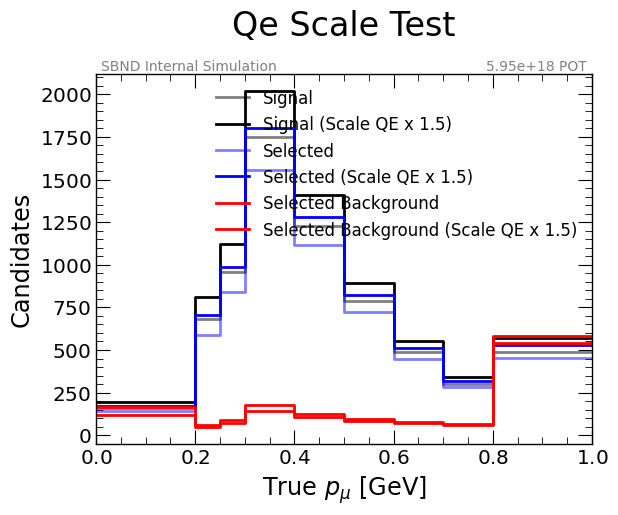

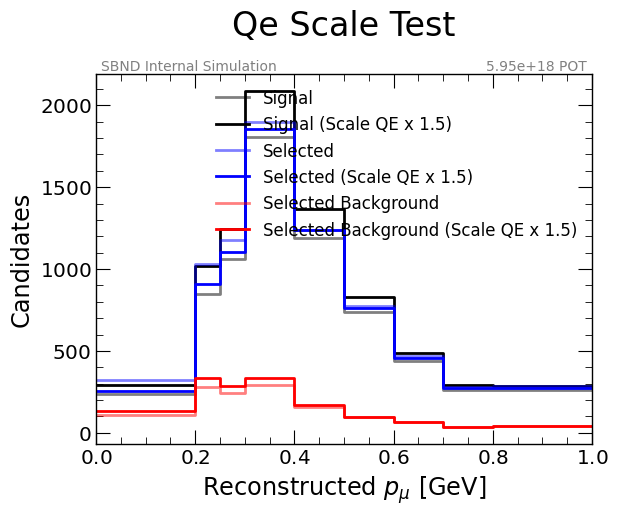

In [63]:
# Check the scaled distributions - momentum
# --truth
fig,ax = plt.subplots()

makeplot.plot_hist_edges(momentum_bins,momentum_sig,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sig_qe,errors=None,label=f'Signal (Scale QE x {qe_scale})',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig_qe,errors=None,label=f'Selected (Scale QE x {qe_scale})',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg,errors=None,label='Selected Background',ax=ax,color='red',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg_qe,errors=None,label=f'Selected Background (Scale QE x {qe_scale})',ax=ax,color='red',alpha=1)

ax.legend()
ax.set_xlabel(r'True $p_\mu$ [GeV]')
ax.set_xlim(0,MAX_PMOM)
ax.set_ylabel(r'Candidates')
ax.set_title(f'Qe Scale Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside',color='gray')
plotters.save_plot('qe_scale_eventrate_momentum_truth',fig=fig,folder_name=f'{PLOT_DIR}/qe')

# --reco
fig,ax = plt.subplots()

makeplot.plot_hist_edges(momentum_bins,momentum_sig_reco,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sig_qe_reco,errors=None,label=f'Signal (Scale QE x {qe_scale})',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_reco,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig_qe_reco,errors=None,label=f'Selected (Scale QE x {qe_scale})',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg_reco,errors=None,label='Selected Background',ax=ax,color='red',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg_qe_reco,errors=None,label=f'Selected Background (Scale QE x {qe_scale})',ax=ax,color='red',alpha=1)

ax.set_xlim(0,MAX_PMOM)
ax.legend()
ax.set_xlabel(r'Reconstructed $p_\mu$ [GeV]')
ax.set_ylabel(r'Candidates')
ax.set_title(f'Qe Scale Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside',color='gray')
plotters.save_plot('qe_scale_eventrate_momentum_reco',fig=fig,folder_name=f'{PLOT_DIR}/qe')

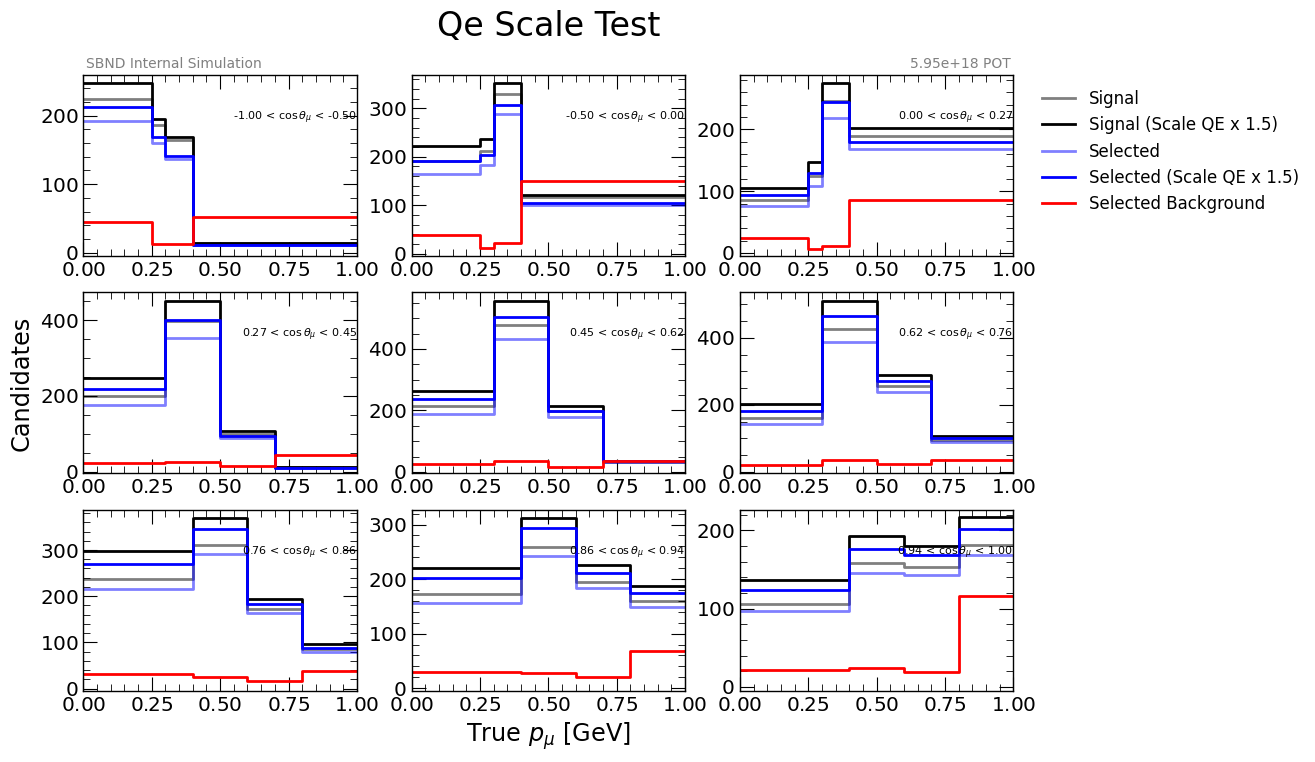

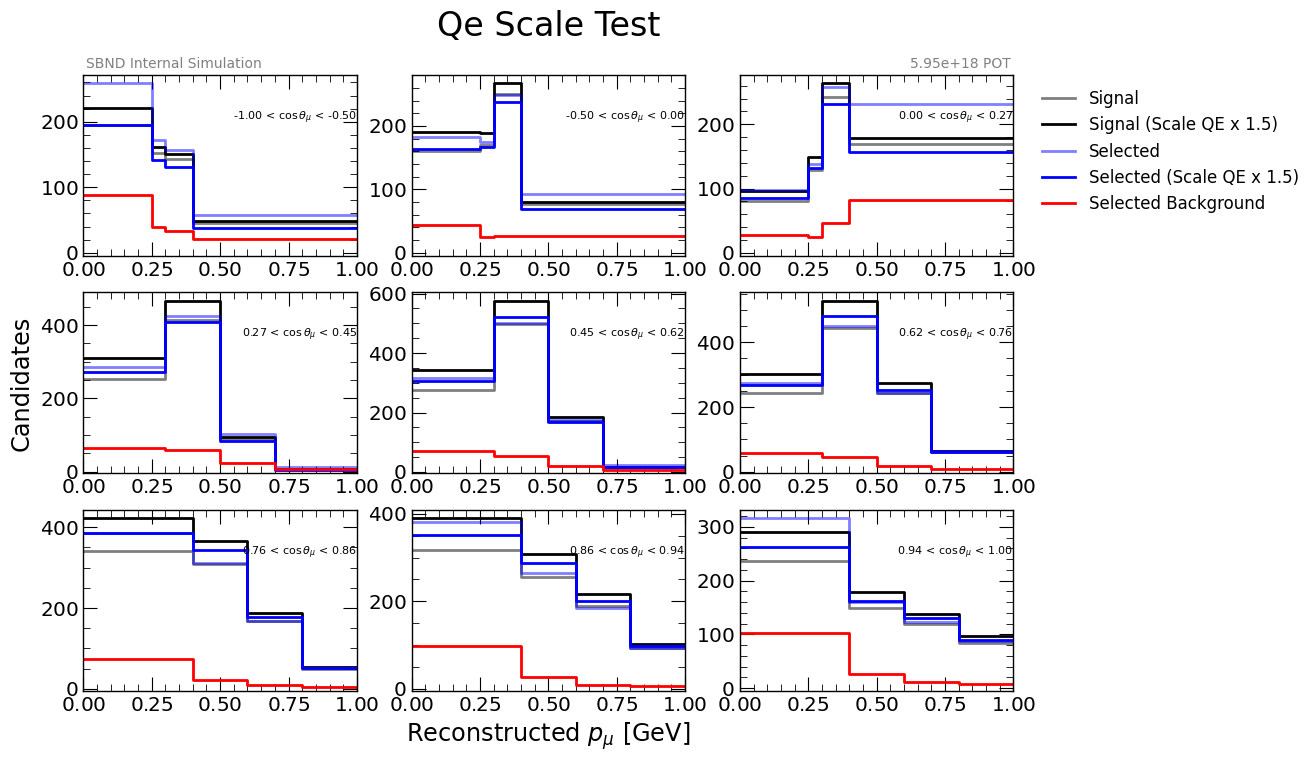

In [64]:
# Check the scaled distributions - differential
# --truth
fig,axs = binning2D.plot_differential_hist_binned(diff_sig,yerrs=None,label='Signal',color='black',alpha=0.5)
fig,axs = binning2D.plot_differential_hist_binned(diff_sig_qe,yerrs=None,label=f'Signal (Scale QE x {qe_scale})',color='black',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig,yerrs=None,label='Selected',color='blue',alpha=0.5,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig_qe,yerrs=None,label=f'Selected (Scale QE x {qe_scale})',color='blue',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_bkg,yerrs=None,label='Selected Background',color='red',alpha=1,fig=fig,axs=axs,
  xlabel=r'True $p_\mu$ [GeV]',ylabel=r'Candidates',add_labels=True,legend=True)

axs[0,1].set_title('Qe Scale Test')
for ax in axs.flatten():
  ylims = ax.get_ylim()
  ax.set_ylim(-5,None)
plotters.add_label(axs[0,2],POT_LABEL,where='toprightoutsidepad',color='gray')
plotters.add_label(axs[0,0],INTERNAL_LABEL,where='topleftoutsidepad',color='gray')
plotters.save_plot('qe_scale_eventrate_differential_truth',fig=fig,folder_name=f'{PLOT_DIR}/qe')

# --reco
fig,axs = binning2D.plot_differential_hist_binned(diff_sig_reco,yerrs=None,label='Signal',color='black',alpha=0.5,fig=None,axs=None)
fig,axs = binning2D.plot_differential_hist_binned(diff_sig_qe_reco,yerrs=None,label=f'Signal (Scale QE x {qe_scale})',color='black',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_reco,yerrs=None,label='Selected',color='blue',alpha=0.5,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig_qe_reco,yerrs=None,label=f'Selected (Scale QE x {qe_scale})',color='blue',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_bkg_reco,yerrs=None,label='Selected Background',color='red',alpha=1,fig=fig,axs=axs,
  xlabel=r'Reconstructed $p_\mu$ [GeV]',ylabel=r'Candidates',add_labels=True,legend=True)

axs[0,1].set_title('Qe Scale Test')
for ax in axs.flatten():
  ylims = ax.get_ylim()
  ax.set_ylim(-5,None)
plotters.add_label(axs[0,2],POT_LABEL,where='toprightoutsidepad',color='gray')
plotters.add_label(axs[0,0],INTERNAL_LABEL,where='topleftoutsidepad',color='gray')
plotters.save_plot('qe_scale_eventrate_differential_reco',fig=fig,folder_name=f'{PLOT_DIR}/qe')

In [65]:
#Costheta
fracxsec_cov_costheta_qe = (csystematics_rw.systematics['xsec']['xsec_fraccov'] \
  + csystematics_rw.systematics['stat']['xsec_fraccov'])
xsec_cov_stat_costheta_qe = csystematics_rw.systematics['stat']['xsec_fraccov']

xsec_costheta.unfold(fracxsec_cov_costheta_qe, #fractional covariance
  costheta_sel_sig_qe_reco, #selected signal
  costheta_sig_qe, #truth signal
  costheta_sel_bkg_qe_reco, #selected background
  name='qe',
  response=xsec_costheta.unfold_results['asimov']['response'],
  stat_cov=xsec_cov_stat_costheta_qe,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=True,
  tikhonov=tikhonov)

fracxsec_cov_momentum_qe = (msystematics_rw.systematics['xsec']['xsec_fraccov'] \
  + msystematics_rw.systematics['stat']['xsec_fraccov'])
xsec_cov_stat_momentum_qe = msystematics_rw.systematics['stat']['xsec_fraccov']

# Overall
xsec_cov_overall_qe = np.array([[np.sum(xsec_costheta.unfold_results['qe']['input_cov'])]])
xsec_cov_stat_overall_qe = np.array([[np.sum(xsec_costheta.unfold_results['qe']['input_stat_cov'])]])

xsec_overall.unfold(xsec_cov_overall_qe, #covariance
  overall_sel_sig_qe_reco, #selected signal
  overall_sig_qe, #truth signal
  overall_sel_bkg_qe, #selected background
  name='qe',
  response=xsec_overall.unfold_results['asimov']['response'],
  stat_cov=xsec_cov_stat_overall_qe,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=False,
  tikhonov=tikhonov)
# Momentum
xsec_momentum.unfold(fracxsec_cov_momentum_qe, #fractional covariance
  momentum_sel_sig_qe_reco, #selected signal
  momentum_sig_qe, #truth signal
  momentum_sel_bkg_qe, #selected background
  name='qe',
  response=xsec_momentum.unfold_results['asimov']['response'],
  stat_cov=xsec_cov_stat_momentum_qe,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=True,
  tikhonov=tikhonov)

fracxsec_cov_differential_qe = (dsystematics_rw.systematics['xsec']['xsec_fraccov'] \
  + dsystematics_rw.systematics['stat']['xsec_fraccov'])[1:,1:]
xsec_cov_stat_differential_qe = dsystematics_rw.systematics['stat']['xsec_fraccov'][1:,1:]

xsec_differential.unfold(fracxsec_cov_differential_qe, #fractional covariance
  diff_sel_sig_qe_reco, #selected signal
  diff_sig_qe, #truth signal
  diff_sel_bkg_qe, #selected background
  name='qe',
  response=xsec_differential.unfold_results['asimov']['response'],
  stat_cov=xsec_cov_stat_differential_qe,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=True,
  tikhonov=tikhonov)

names = ['qe','asimov']
model_labels = ['QE Test','Asimov Truth']
data_label = 'QE Data'
title=f'QE Scale x {qe_scale}'

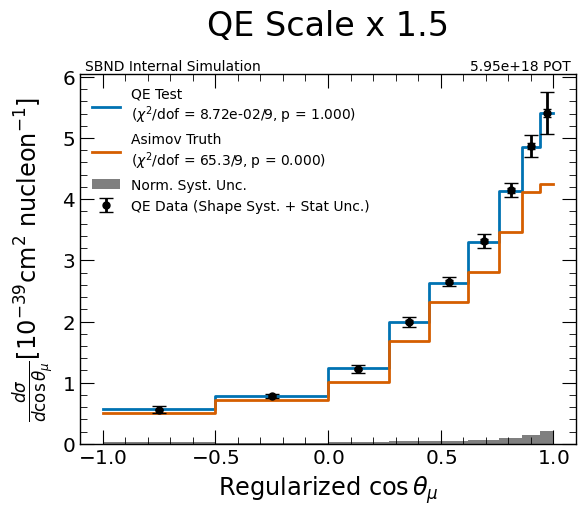

In [66]:
fig,ax = xsec_costheta.plot_unfold(names, model_labels, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('qe_unfold_costheta',fig=fig,folder_name=f'{PLOT_DIR}/qe')


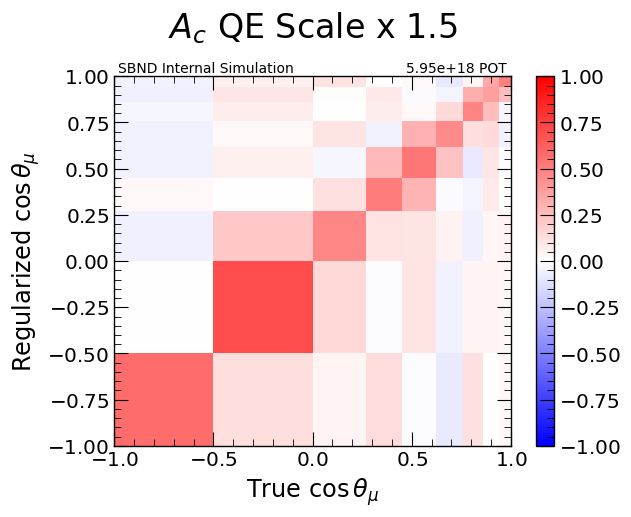

In [67]:
#Smear matrix
fig,ax = xsec_costheta.plot_smear('qe', title=r'$A_c$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('qe_ac_costheta',fig=fig,folder_name=f'{PLOT_DIR}/qe')


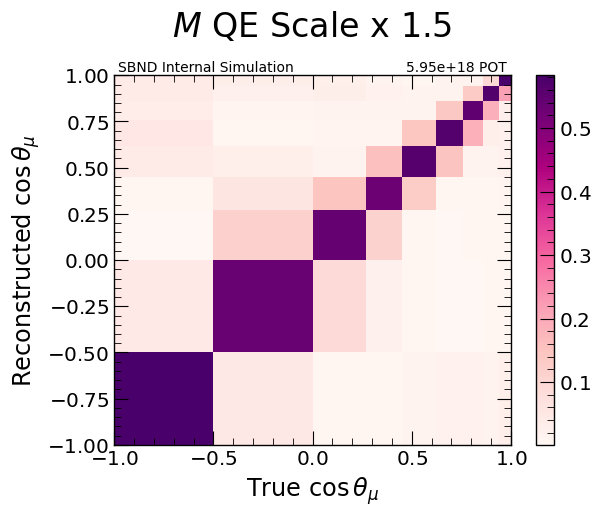

In [68]:
fig,ax = xsec_costheta.plot_response('qe', title=r'$M$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('qe_response_costheta',fig=fig,folder_name=f'{PLOT_DIR}/qe')

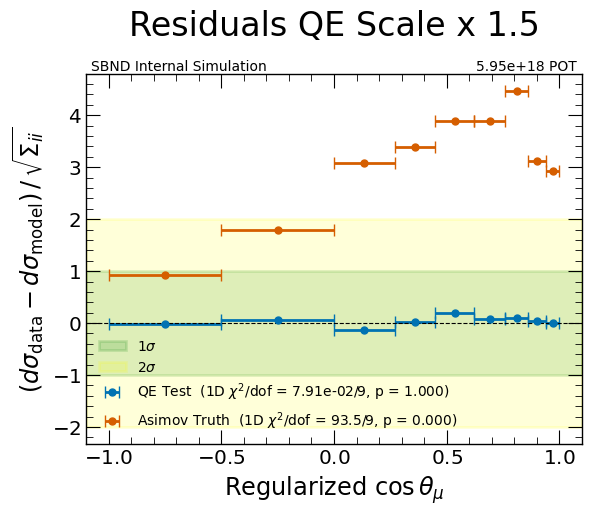

In [69]:
fig,ax = xsec_costheta.plot_residuals(names,model_labels, title='Residuals ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL, verbose=False)
plotters.save_plot('qe_residuals_costheta',fig=fig,folder_name=f'{PLOT_DIR}/qe')

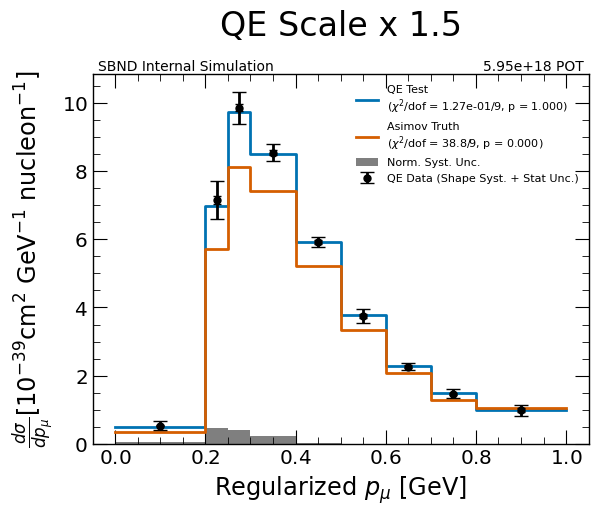

In [70]:
fig,ax = xsec_momentum.plot_unfold(names, model_labels, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label,
  legend_fontsize=8)
plotters.save_plot('qe_unfold_momentum',fig=fig,folder_name=f'{PLOT_DIR}/qe')

In [71]:
# fracxsec_corr_momentum_qe = (msystematics_rw.systematics['xsec']['xsec_corr'] \
#   + msystematics_rw.systematics['stat']['xsec_corr'])
# fracxsec_corr_momentum_qe = msystematics_rw.systematics['xsec']['xsec_corr']
# plt.imshow(fracxsec_corr_momentum_qe,cmap='bwr',vmin=-1,vmax=1)
# plt.colorbar()

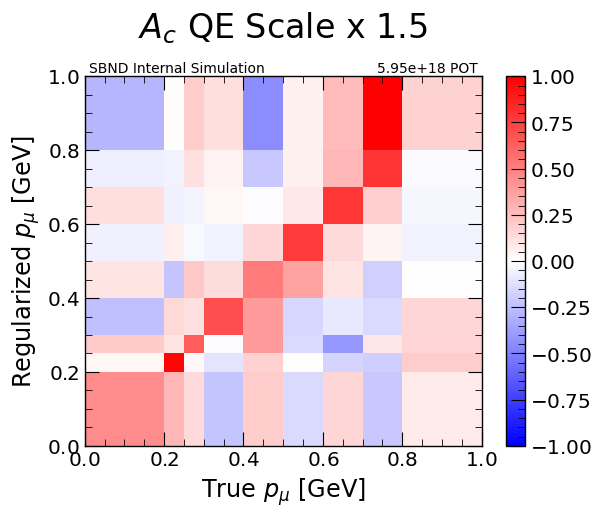

In [72]:
fig,ax = xsec_momentum.plot_smear('qe', title=r'$A_c$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('qe_ac_momentum',fig=fig,folder_name=f'{PLOT_DIR}/qe')

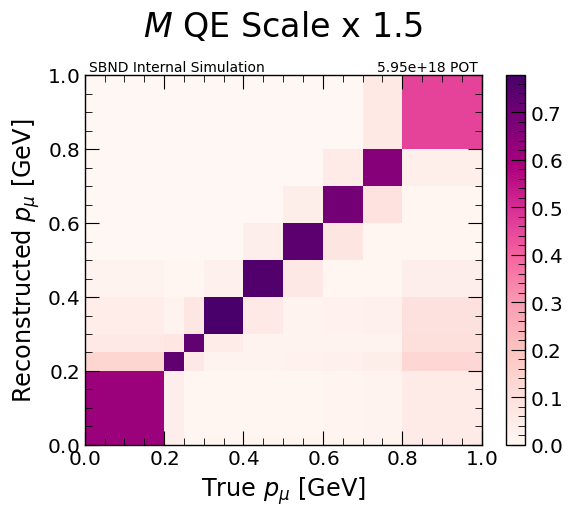

In [73]:
fig,ax = xsec_momentum.plot_response('qe', title=r'$M$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('qe_response_momentum',fig=fig,folder_name=f'{PLOT_DIR}/qe')

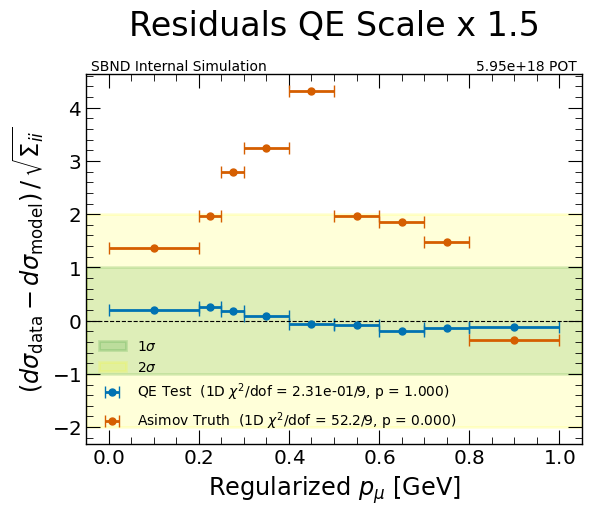

In [74]:
fig,ax = xsec_momentum.plot_residuals(names,model_labels, title='Residuals ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL, verbose=False)
plotters.save_plot('qe_residuals_momentum',fig=fig,folder_name=f'{PLOT_DIR}/qe')

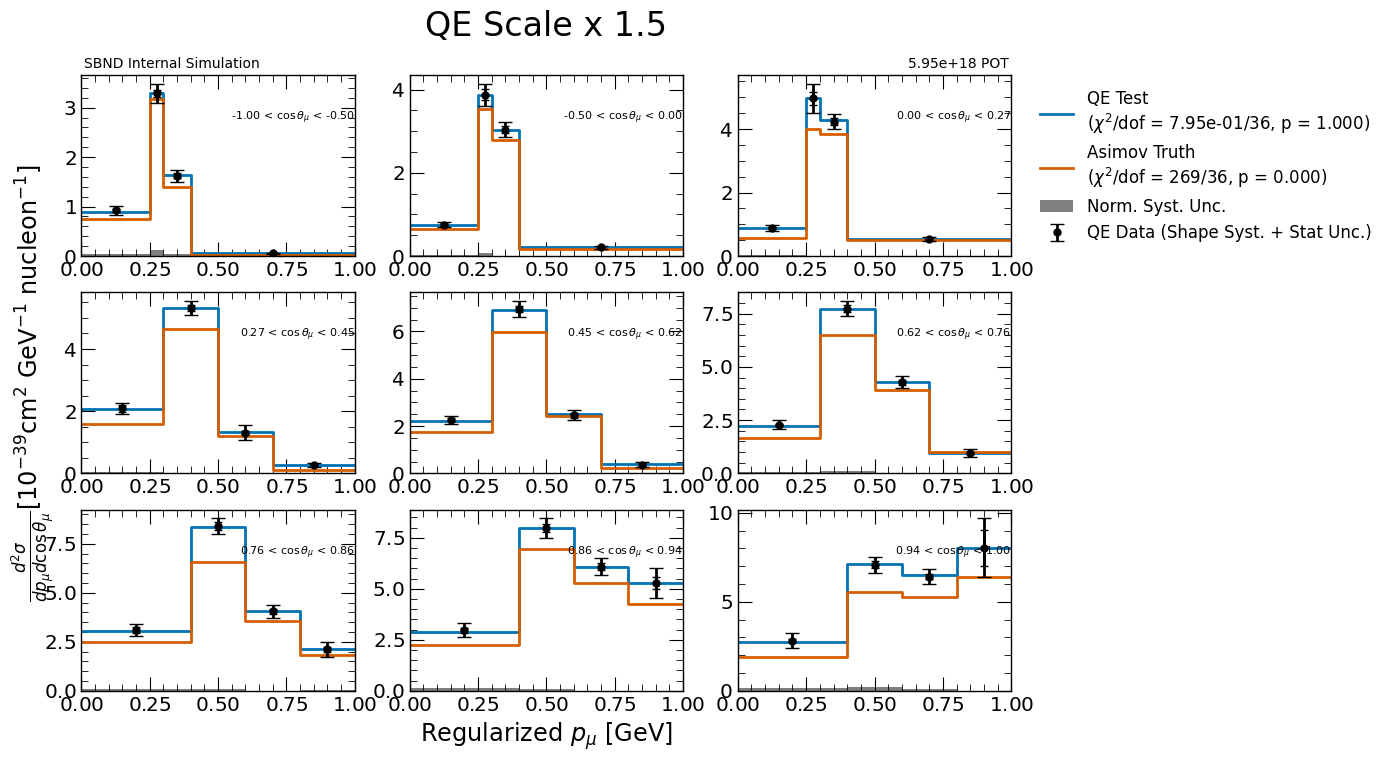

In [75]:
fig,axs = xsec_differential.plot_unfold_2d(names, model_labels, binning2D, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('qe_unfold_differential',fig=fig,folder_name=f'{PLOT_DIR}/qe')

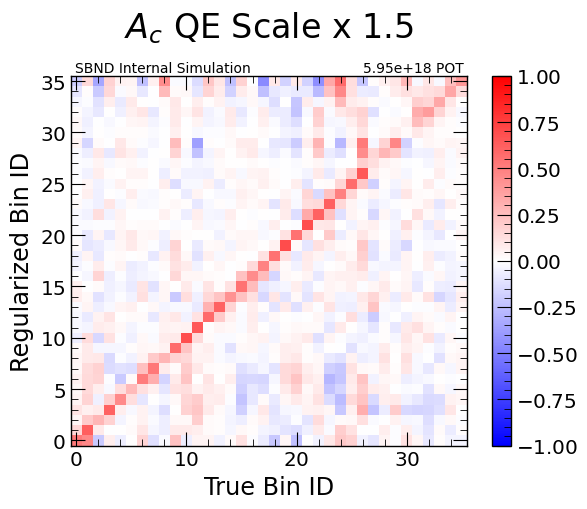

In [76]:
fig,ax = xsec_differential.plot_smear('qe', title=r'$A_c$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('qe_ac_differential',fig=fig,folder_name=f'{PLOT_DIR}/qe')

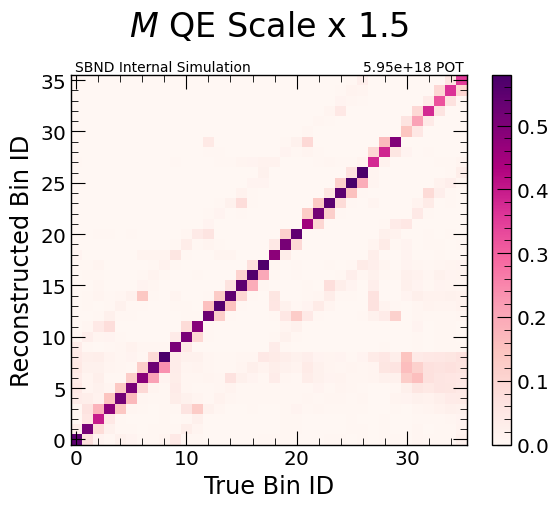

In [77]:
fig,ax = xsec_differential.plot_response('qe', title=r'$M$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('qe_response_differential',fig=fig,folder_name=f'{PLOT_DIR}/qe')


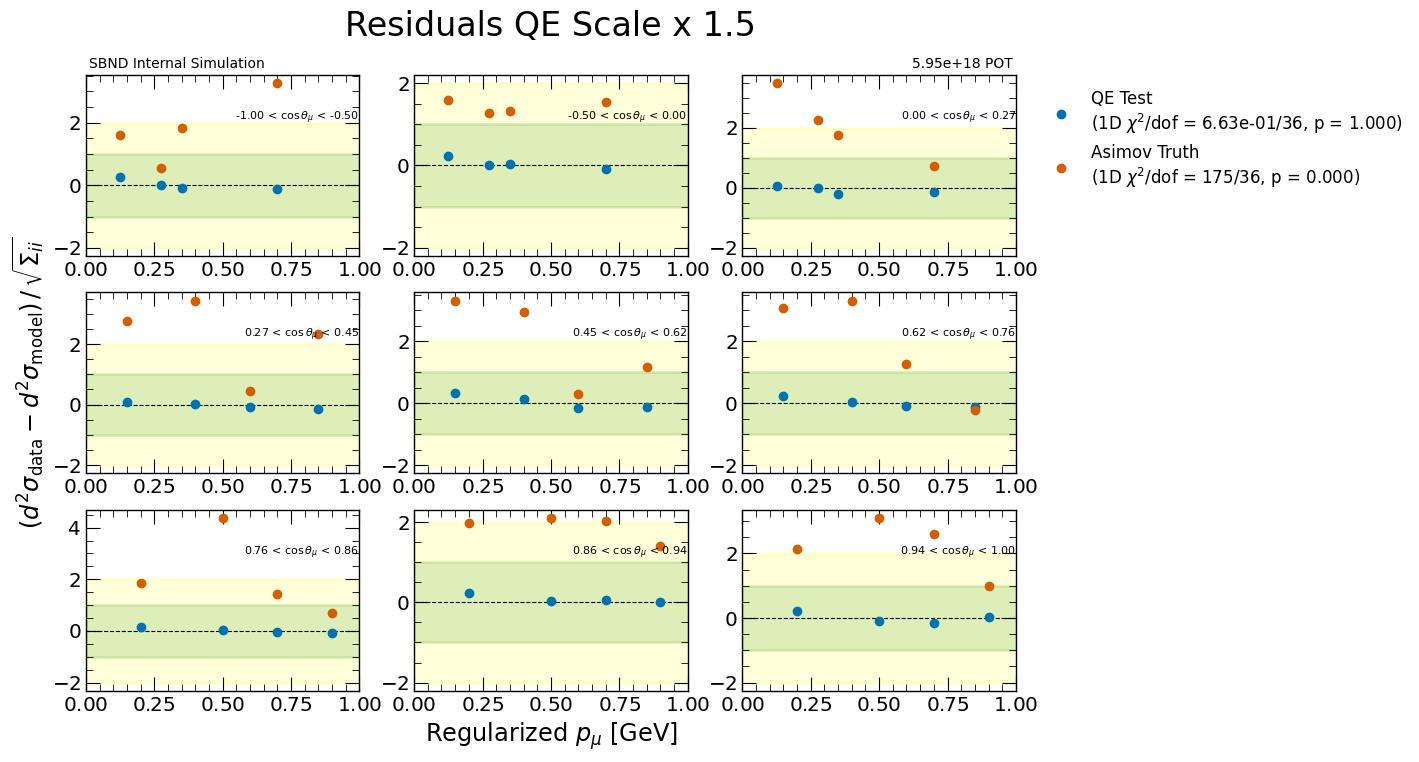

In [78]:
fig,ax = xsec_differential.plot_residuals_2d(names,model_labels, binning2D, title='Residuals ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL, verbose=False)
plotters.save_plot('qe_residuals_differential',fig=fig,folder_name=f'{PLOT_DIR}/qe')

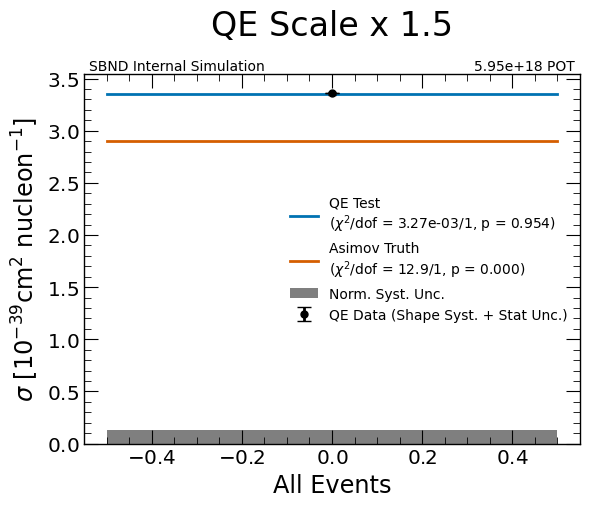

In [79]:
fig,ax = xsec_overall.plot_unfold(names, model_labels, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('qe_unfold_overall',fig=fig,folder_name=f'{PLOT_DIR}/qe')

### 2.4. Remove high momentum muons (fake data)

In [80]:
mom_cutoff = 0.9

#Signal
mask = slc_mc_signal.data.truth.mu.totp > mom_cutoff
col = slc_mc_signal.get_key('genweight')
# Variables
genweights_sig_momcut = genweights_sig.copy()
genweights_sig_momcut[mask] = 0.
# Histograms
# --truth
costheta_sig_momcut,_ = np.histogram(costheta_sig_vals,bins=costheta_bins,weights=genweights_sig_momcut)
momentum_sig_momcut,_ = np.histogram(momentum_sig_vals,bins=momentum_bins,weights=genweights_sig_momcut)
diff_sig_momcut,_ = np.histogram(diff_sig_vals,bins=binning2D.differential_edges,weights=genweights_sig_momcut)
overall_sig_momcut,_ = np.histogram(overall_sig_vals,bins=overall_bins,weights=genweights_sig_momcut)
# --reco
costheta_sig_momcut_reco,_ = np.histogram(costheta_sig_reco_vals,bins=costheta_bins,weights=genweights_sig_momcut)
momentum_sig_momcut_reco,_ = np.histogram(momentum_sig_reco_vals,bins=momentum_bins,weights=genweights_sig_momcut)
diff_sig_momcut_reco,_ = np.histogram(diff_sig_reco_vals,bins=binning2D.differential_edges,weights=genweights_sig_momcut)
overall_sig_momcut_reco,_ = np.histogram(overall_sig_reco_vals,bins=overall_bins,weights=genweights_sig_momcut)
#Selected
mask = slc_mc_sel.data.truth.mu.totp > mom_cutoff
col = slc_mc_sel.get_key('genweight')
# Variables
genweights_sel_momcut = genweights_sel.copy()
genweights_sel_momcut[mask] = 0.
# Histograms
# --truth
costheta_sel_momcut,_ = np.histogram(costheta_sel_vals,bins=costheta_bins,weights=genweights_sel_momcut)
momentum_sel_momcut,_ = np.histogram(momentum_sel_vals,bins=momentum_bins,weights=genweights_sel_momcut)
diff_sel_momcut,_ = np.histogram(diff_sel_vals,bins=binning2D.differential_edges,weights=genweights_sel_momcut)
overall_sel_momcut,_ = np.histogram(overall_sel_vals,bins=overall_bins,weights=genweights_sel_momcut)

# --reco
costheta_sel_momcut_reco,_ = np.histogram(costheta_sel_reco_vals,bins=costheta_bins,weights=genweights_sel_momcut)
momentum_sel_momcut_reco,_ = np.histogram(momentum_sel_reco_vals,bins=momentum_bins,weights=genweights_sel_momcut)
diff_sel_momcut_reco,_ = np.histogram(diff_sel_reco_vals,bins=binning2D.differential_edges,weights=genweights_sel_momcut)
overall_sel_momcut_reco,_ = np.histogram(overall_sel_reco_vals,bins=overall_bins,weights=genweights_sel_momcut)

#Selected signal
m2 = np.isin(slc_mc_sel.data.truth.event_type,CATEGORIES)
#Variables
genweights_sel_sig_momcut = genweights_sel_momcut[m2]
# Histograms
# --truth
costheta_sel_sig_momcut,_ = np.histogram(costheta_sel_sig_vals,bins=costheta_bins,weights=genweights_sel_sig_momcut)
momentum_sel_sig_momcut,_ = np.histogram(momentum_sel_sig_vals,bins=momentum_bins,weights=genweights_sel_sig_momcut)
diff_sel_sig_momcut,_ = np.histogram(diff_sel_sig_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig_momcut)
overall_sel_sig_momcut,_ = np.histogram(overall_sel_sig_vals,bins=overall_bins,weights=genweights_sel_sig_momcut)

# --reco
costheta_sel_sig_momcut_reco,_ = np.histogram(costheta_sel_sig_reco_vals,bins=costheta_bins,weights=genweights_sel_sig_momcut)
momentum_sel_sig_momcut_reco,_ = np.histogram(momentum_sel_sig_reco_vals,bins=momentum_bins,weights=genweights_sel_sig_momcut)
diff_sel_sig_momcut_reco,_ = np.histogram(diff_sel_sig_reco_vals,bins=binning2D.differential_edges,weights=genweights_sel_sig_momcut)
overall_sel_sig_momcut_reco,_ = np.histogram(overall_sel_sig_reco_vals,bins=overall_bins,weights=genweights_sel_sig_momcut)

# Selected background
costheta_sel_bkg_momcut = costheta_sel_momcut - costheta_sel_sig_momcut
momentum_sel_bkg_momcut = momentum_sel_momcut - momentum_sel_sig_momcut
diff_sel_bkg_momcut = diff_sel_momcut - diff_sel_sig_momcut
overall_sel_bkg_momcut = overall_sel_momcut - overall_sel_sig_momcut

costheta_sel_bkg_momcut_reco = costheta_sel_momcut_reco - costheta_sel_sig_momcut_reco
momentum_sel_bkg_momcut_reco = momentum_sel_momcut_reco - momentum_sel_sig_momcut_reco
diff_sel_bkg_momcut_reco = diff_sel_momcut_reco - diff_sel_sig_momcut_reco
overall_sel_bkg_momcut_reco = overall_sel_momcut_reco - overall_sel_sig_momcut_reco


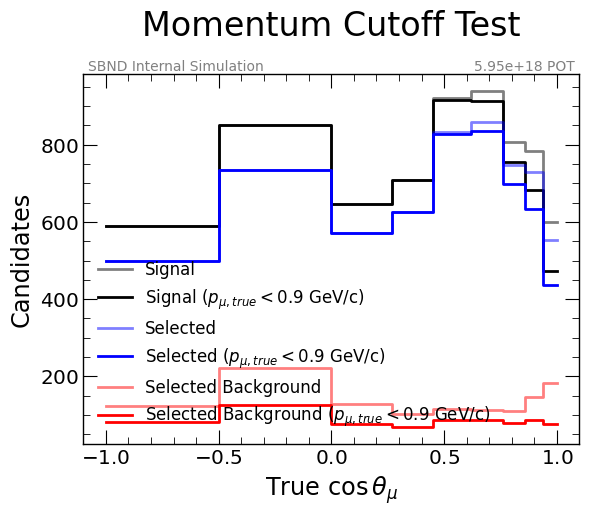

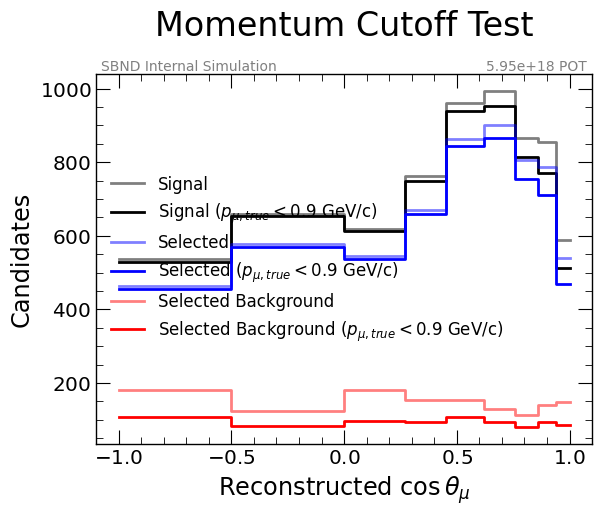

In [81]:
#Check the scaled distributions - costheta
#--truth
fig,ax = plt.subplots()

makeplot.plot_hist_edges(costheta_bins,costheta_sig,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sig_momcut,errors=None,label=f'Signal ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig_momcut,errors=None,label=f'Selected ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg,errors=None,label='Selected Background',ax=ax,color='red',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg_momcut,errors=None,label=f'Selected Background ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='red',alpha=1)

ax.legend()
ax.set_xlabel(r'True $\cos\theta_\mu$')
ax.set_ylabel(r'Candidates')
ax.set_title(f'Momentum Cutoff Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside',color='gray')
plotters.save_plot('costheta_momentum_cutoff_eventrate_truth',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

#--reco
fig,ax = plt.subplots()

makeplot.plot_hist_edges(costheta_bins,costheta_sig_reco,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sig_momcut_reco,errors=None,label=f'Signal ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig_reco,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_sig_momcut_reco,errors=None,label=f'Selected ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg_reco,errors=None,label='Selected Background',ax=ax,color='red',alpha=0.5)
makeplot.plot_hist_edges(costheta_bins,costheta_sel_bkg_momcut_reco,errors=None,label=f'Selected Background ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='red',alpha=1)

ax.legend()
ax.set_xlabel(r'Reconstructed $\cos\theta_\mu$')
ax.set_ylabel(r'Candidates')
ax.set_title(f'Momentum Cutoff Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside',color='gray')
plotters.save_plot('costheta_momentum_cutoff_eventrate_reco',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')


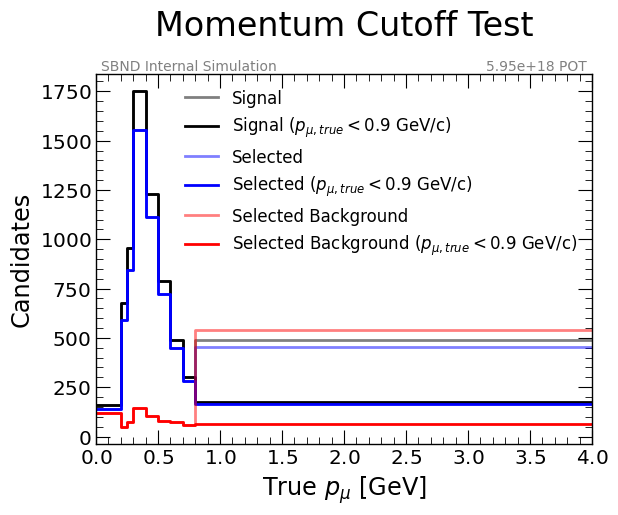

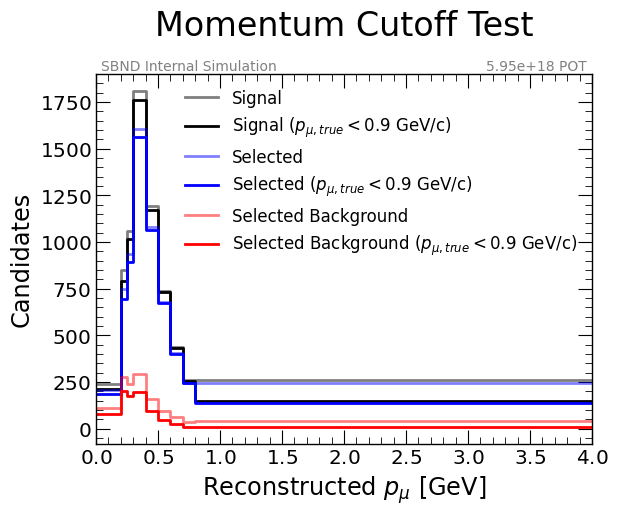

In [82]:
# Check the scaled distributions - momentum
# --truth
fig,ax = plt.subplots()

makeplot.plot_hist_edges(momentum_bins,momentum_sig,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sig_momcut,errors=None,label=f'Signal ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig_momcut,errors=None,label=f'Selected ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg,errors=None,label='Selected Background',ax=ax,color='red',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg_momcut,errors=None,label=f'Selected Background ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='red',alpha=1)

ax.legend()
ax.set_xlim(0,4)
ax.set_xlabel(r'True $p_\mu$ [GeV]')
ax.set_ylabel(r'Candidates')
ax.set_title(f'Momentum Cutoff Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside',color='gray')
plotters.save_plot('momentum_momentum_cutoff_eventrate_truth',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

#--reco
fig,ax = plt.subplots()

makeplot.plot_hist_edges(momentum_bins,momentum_sig_reco,errors=None,label='Signal',ax=ax,color='black',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sig_momcut_reco,errors=None,label=f'Signal ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='black',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig_reco,errors=None,label='Selected',ax=ax,color='blue',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_sig_momcut_reco,errors=None,label=f'Selected ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='blue',alpha=1)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg_reco,errors=None,label='Selected Background',ax=ax,color='red',alpha=0.5)
makeplot.plot_hist_edges(momentum_bins,momentum_sel_bkg_momcut_reco,errors=None,label=f'Selected Background ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',ax=ax,color='red',alpha=1)

ax.legend()
ax.set_xlim(0,4)
ax.set_xlabel(r'Reconstructed $p_\mu$ [GeV]')
ax.set_ylabel(r'Candidates')
ax.set_title(f'Momentum Cutoff Test')
plotters.add_label(ax,POT_LABEL,where='toprightoutside',color='gray')
plotters.add_label(ax,INTERNAL_LABEL,where='topleftoutside',color='gray')
plotters.save_plot('momentum_momentum_cutoff_eventrate_reco',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')


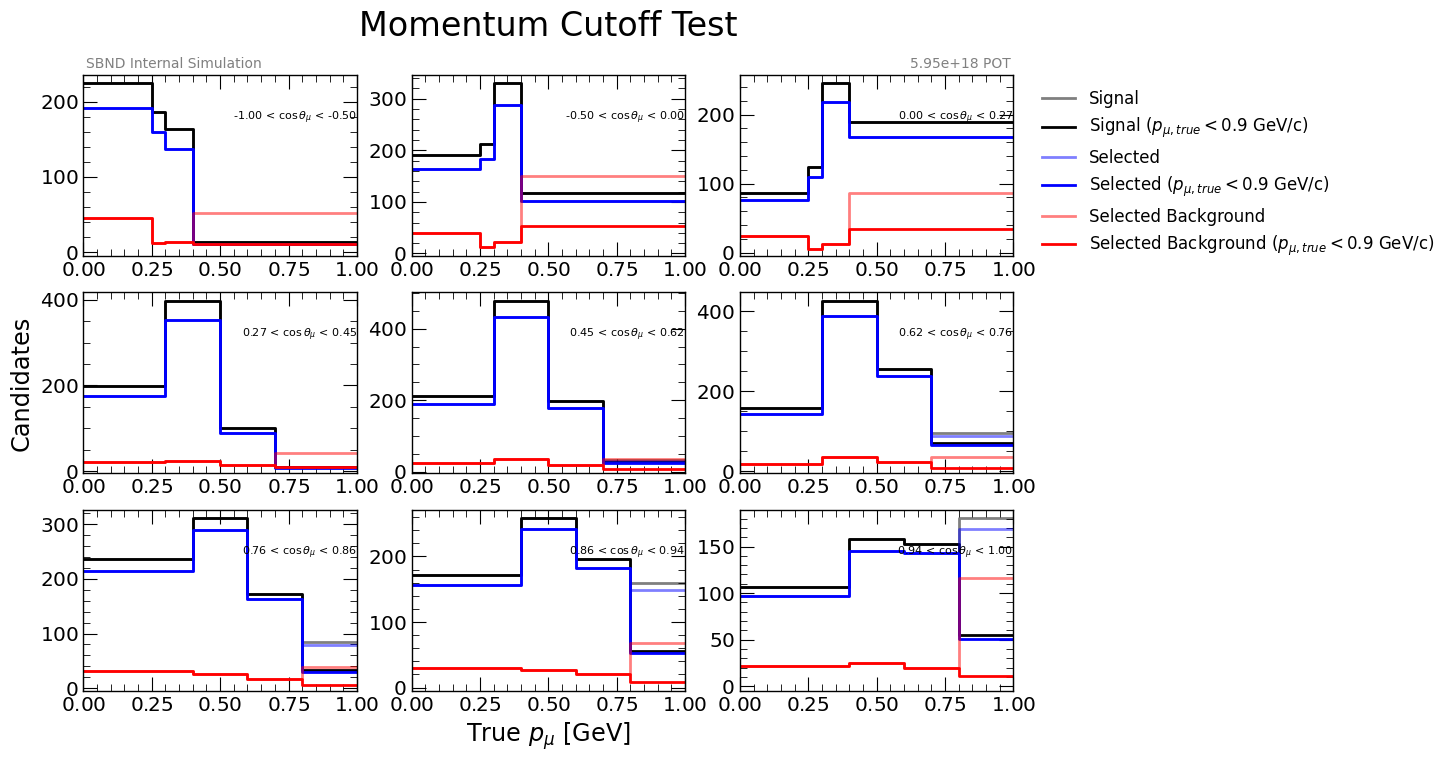

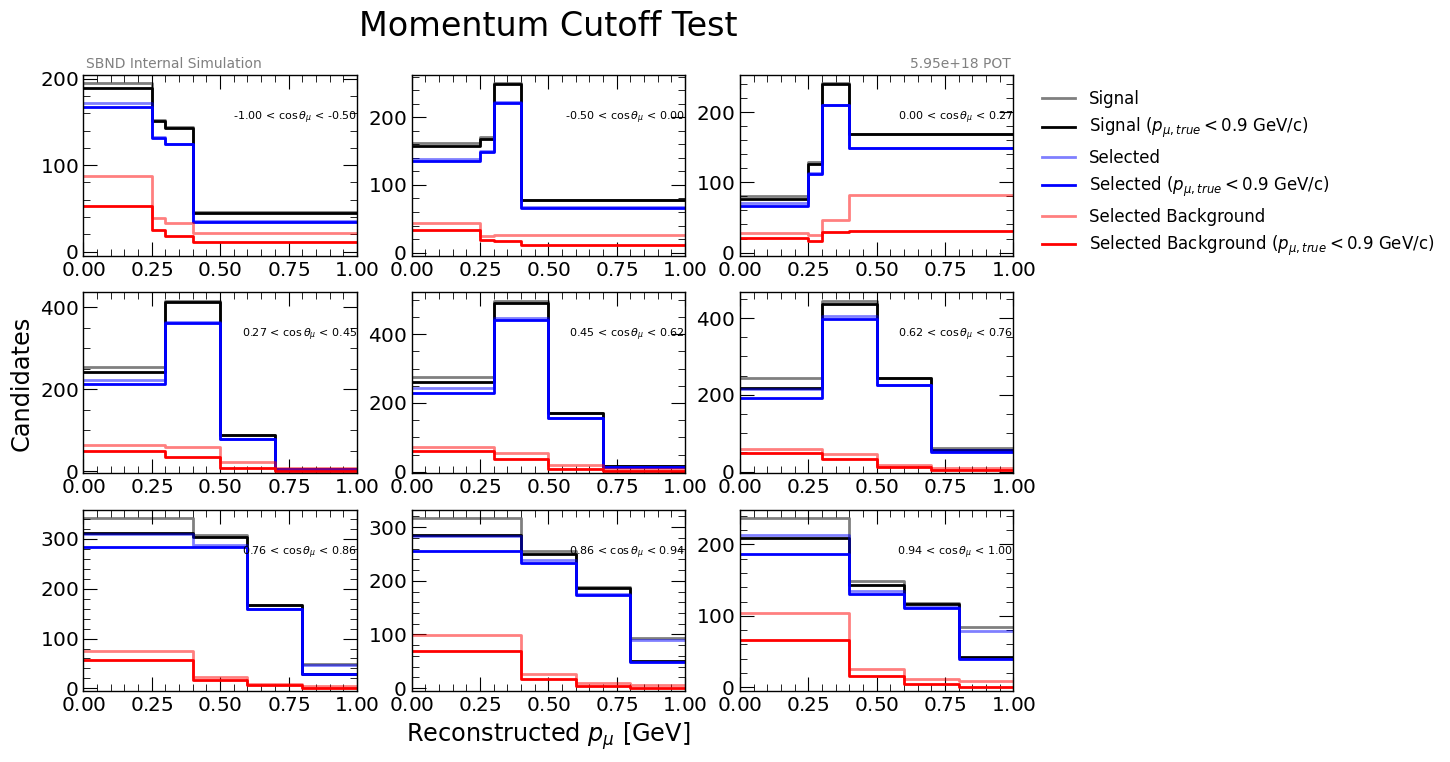

In [83]:
# Check the scaled distributions - differential
# --truth
fig,axs = binning2D.plot_differential_hist_binned(diff_sig,yerrs=None,label='Signal',color='black',alpha=0.5)
fig,axs = binning2D.plot_differential_hist_binned(diff_sig_momcut,yerrs=None,label=f'Signal ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',color='black',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig,yerrs=None,label='Selected',color='blue',alpha=0.5,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig_momcut,yerrs=None,label=f'Selected ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',color='blue',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_bkg,yerrs=None,label='Selected Background',color='red',alpha=0.5,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_bkg_momcut,yerrs=None,label=f'Selected Background ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',color='red',alpha=1,fig=fig,axs=axs,
  xlabel=r'True $p_\mu$ [GeV]',ylabel=r'Candidates',add_labels=True,legend=True)

axs[0,1].set_title('Momentum Cutoff Test')
for ax in axs.flatten():
  ylims = ax.get_ylim()
  ax.set_ylim(-5,None)
plotters.add_label(axs[0,2],POT_LABEL,where='toprightoutsidepad',color='gray')
plotters.add_label(axs[0,0],INTERNAL_LABEL,where='topleftoutsidepad',color='gray')
plotters.save_plot('differential_momentum_cutoff_eventrate_truth',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

# --reco
fig,axs = binning2D.plot_differential_hist_binned(diff_sig_reco,yerrs=None,label='Signal',color='black',alpha=0.5,fig=None,axs=None)
fig,axs = binning2D.plot_differential_hist_binned(diff_sig_momcut_reco,yerrs=None,label=f'Signal ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',color='black',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig_reco,yerrs=None,label='Selected',color='blue',alpha=0.5,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_sig_momcut_reco,yerrs=None,label=f'Selected ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',color='blue',alpha=1,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_bkg_reco,yerrs=None,label='Selected Background',color='red',alpha=0.5,fig=fig,axs=axs)
fig,axs = binning2D.plot_differential_hist_binned(diff_sel_bkg_momcut_reco,yerrs=None,label=f'Selected Background ' + r'($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV/c)',color='red',alpha=1,fig=fig,axs=axs,
  xlabel=r'Reconstructed $p_\mu$ [GeV]',ylabel=r'Candidates',add_labels=True,legend=True)

axs[0,1].set_title('Momentum Cutoff Test')
for ax in axs.flatten():
  ylims = ax.get_ylim()
  ax.set_ylim(-5,None)
plotters.add_label(axs[0,2],POT_LABEL,where='toprightoutsidepad',color='gray')
plotters.add_label(axs[0,0],INTERNAL_LABEL,where='topleftoutsidepad',color='gray')
plotters.save_plot('differential_momentum_cutoff_eventrate_reco',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')


In [84]:
#Costheta
fracxsec_cov_costheta_momcut = (csystematics_rw.systematics['xsec']['xsec_fraccov'] \
  + csystematics_rw.systematics['stat']['xsec_fraccov'])
fracxsec_stat_cov_costheta_momcut = csystematics_rw.systematics['stat']['xsec_fraccov']

xsec_costheta.unfold(fracxsec_cov_costheta_momcut, #fractional covariance
  costheta_sel_sig_momcut_reco, #selected signal
  costheta_sig_momcut, #truth signal
  costheta_sel_bkg_momcut_reco, #selected background
  name='momcut',
  response=xsec_costheta.unfold_results['asimov']['response'],
  stat_cov=fracxsec_stat_cov_costheta_momcut,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=True,
  tikhonov=tikhonov)

fracxsec_cov_momentum_momcut = (msystematics_rw.systematics['xsec']['xsec_fraccov'] \
  + msystematics_rw.systematics['stat']['xsec_fraccov'])
fracxsec_stat_cov_momentum_momcut = msystematics_rw.systematics['stat']['xsec_fraccov']

#Overall
xsec_cov_overall_momcut = np.array([[np.sum(xsec_costheta.unfold_results['momcut']['input_cov'])]])
xsec_cov_stat_overall_momcut = np.array([[np.sum(xsec_costheta.unfold_results['momcut']['input_stat_cov'])]])

xsec_overall.unfold(xsec_cov_overall_momcut, #covariance
  overall_sel_sig_momcut_reco, #selected signal
  overall_sig_momcut, #truth signal
  overall_sel_bkg_momcut, #selected background
  name='momcut',
  response=xsec_overall.unfold_results['asimov']['response'],
  stat_cov=xsec_cov_stat_overall_momcut,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=False,
  tikhonov=tikhonov)

# Momentum
xsec_momentum.unfold(fracxsec_cov_momentum_momcut, #fractional covariance
  momentum_sel_sig_momcut_reco, #selected signal
  momentum_sig_momcut, #truth signal
  momentum_sel_bkg_momcut, #selected background
  name='momcut',
  response=xsec_momentum.unfold_results['asimov']['response'],
  stat_cov=fracxsec_stat_cov_momentum_momcut,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=True,
  tikhonov=tikhonov)

fracxsec_cov_differential_momcut = (dsystematics_rw.systematics['xsec']['xsec_fraccov'] \
  + dsystematics_rw.systematics['stat']['xsec_fraccov'])[1:,1:]
fracxsec_stat_cov_differential_momcut = dsystematics_rw.systematics['stat']['xsec_fraccov'][1:,1:]

xsec_differential.unfold(fracxsec_cov_differential_momcut, #fractional covariance
  diff_sel_sig_momcut_reco, #selected signal
  diff_sig_momcut, #truth signal
  diff_sel_bkg_momcut, #selected background
  name='momcut',
  response=xsec_differential.unfold_results['asimov']['response'],
  stat_cov=fracxsec_stat_cov_differential_momcut,
  C_type=C_type, Norm_type=Norm_type,verbose=False,fractional_cov=True,
  tikhonov=tikhonov)

names = ['momcut','asimov']
model_labels = ['Momentum Cutoff Test','Asimov Truth']
data_label = 'Momentum Cut Data'
title = r'Momentum Cutoff Test ($p_{\mu,true} < $' + f'{mom_cutoff:.1f} GeV)'

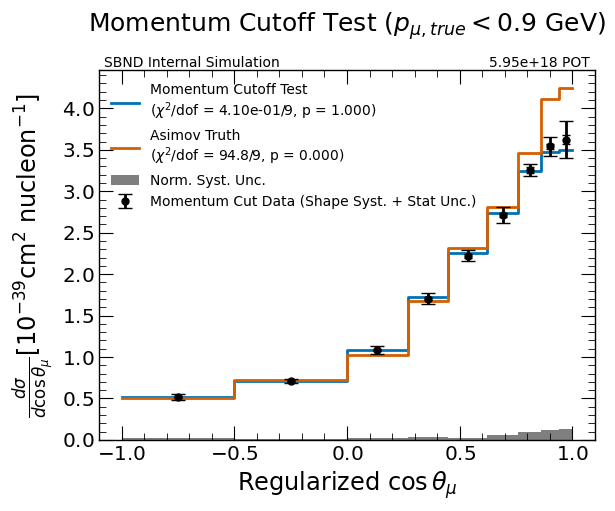

In [85]:
fig,ax = xsec_costheta.plot_unfold(names, model_labels, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('momentum_cutoff_unfold_costheta',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

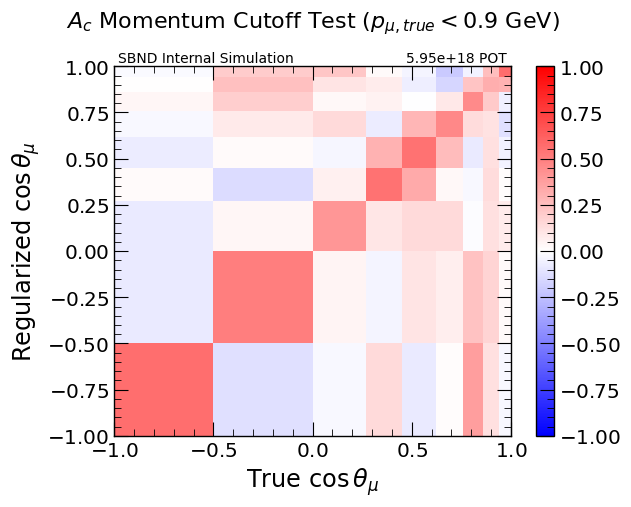

In [86]:
fig, ax = xsec_costheta.plot_smear('momcut', title=r'$A_c$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('momentum_ac_cutoff_costheta',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

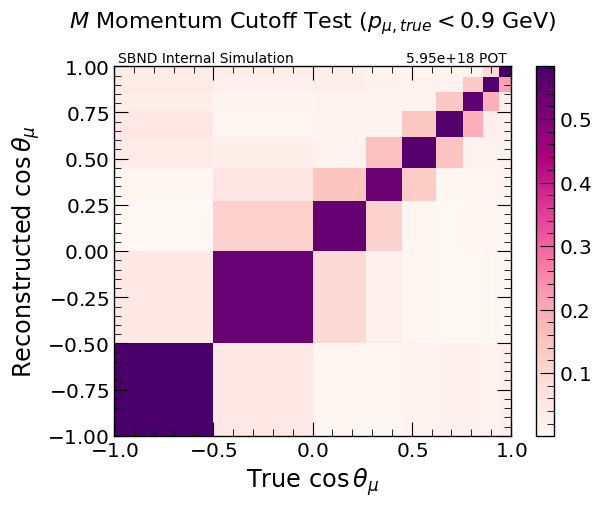

In [87]:
fig,ax = xsec_costheta.plot_response('momcut', title=r'$M$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('momentum_cutoff_response_costheta',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

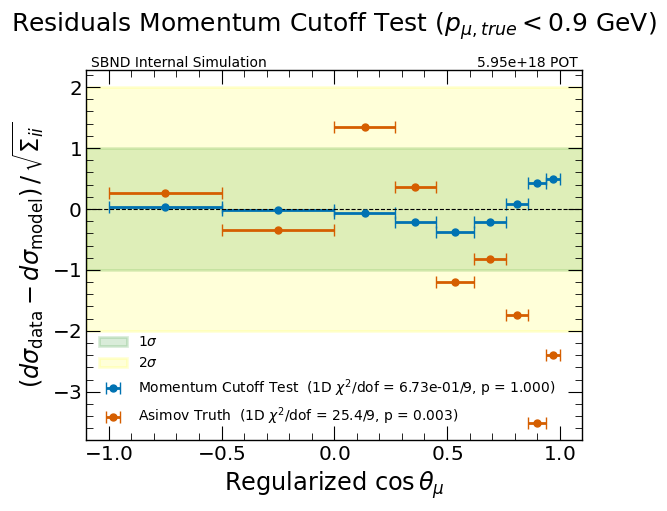

In [88]:
fig,ax = xsec_costheta.plot_residuals(names,model_labels, title='Residuals ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL, verbose=False)
plotters.save_plot('momentum_cutoff_residuals_costheta',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

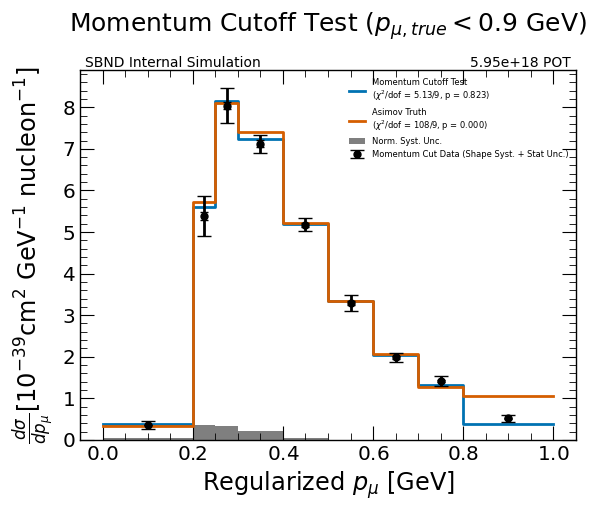

In [89]:
fig,ax = xsec_momentum.plot_unfold(names, model_labels, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label, legend_fontsize=6)
plotters.save_plot('momentum_cutoff_unfold_momentum',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

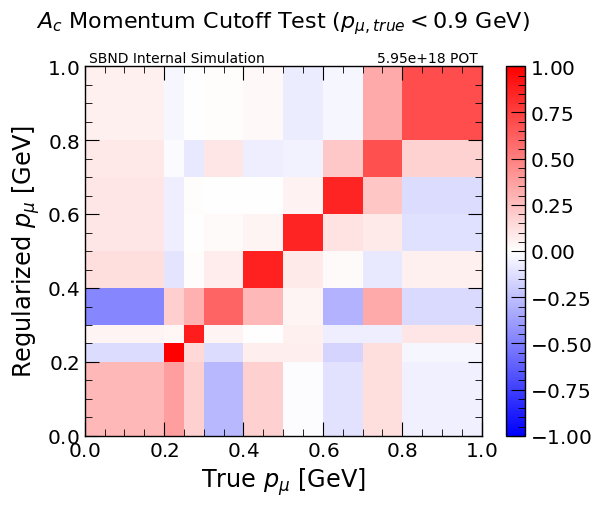

In [90]:
fig,ax = xsec_momentum.plot_smear('momcut', title=r'$A_c$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('momentum_cutoff_momentum_ac',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

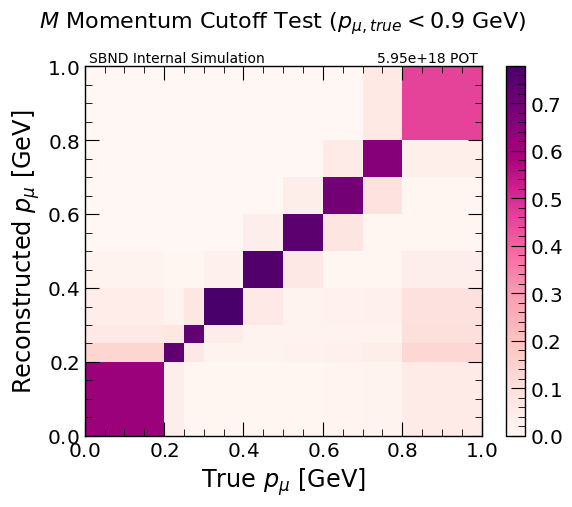

In [91]:
fig,ax = xsec_momentum.plot_response('momcut', title=r'$M$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('momentum_cutoff_response_momentum',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

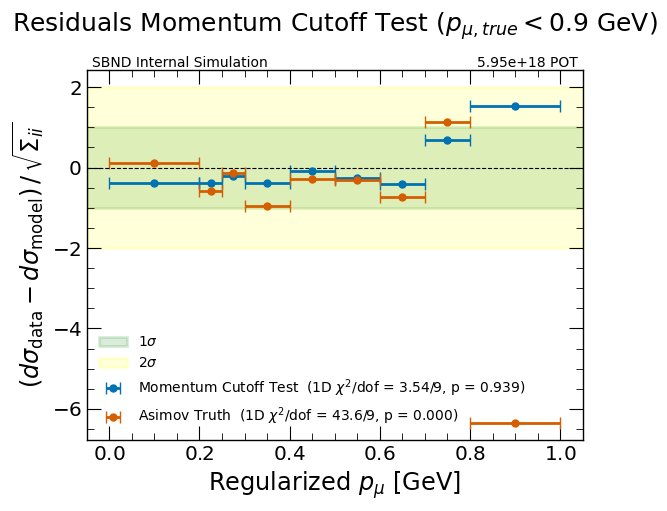

In [92]:
fig,ax = xsec_momentum.plot_residuals(names,model_labels, title='Residuals ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL, verbose=False)
plotters.save_plot('momentum_cutoff_residuals_momentum',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

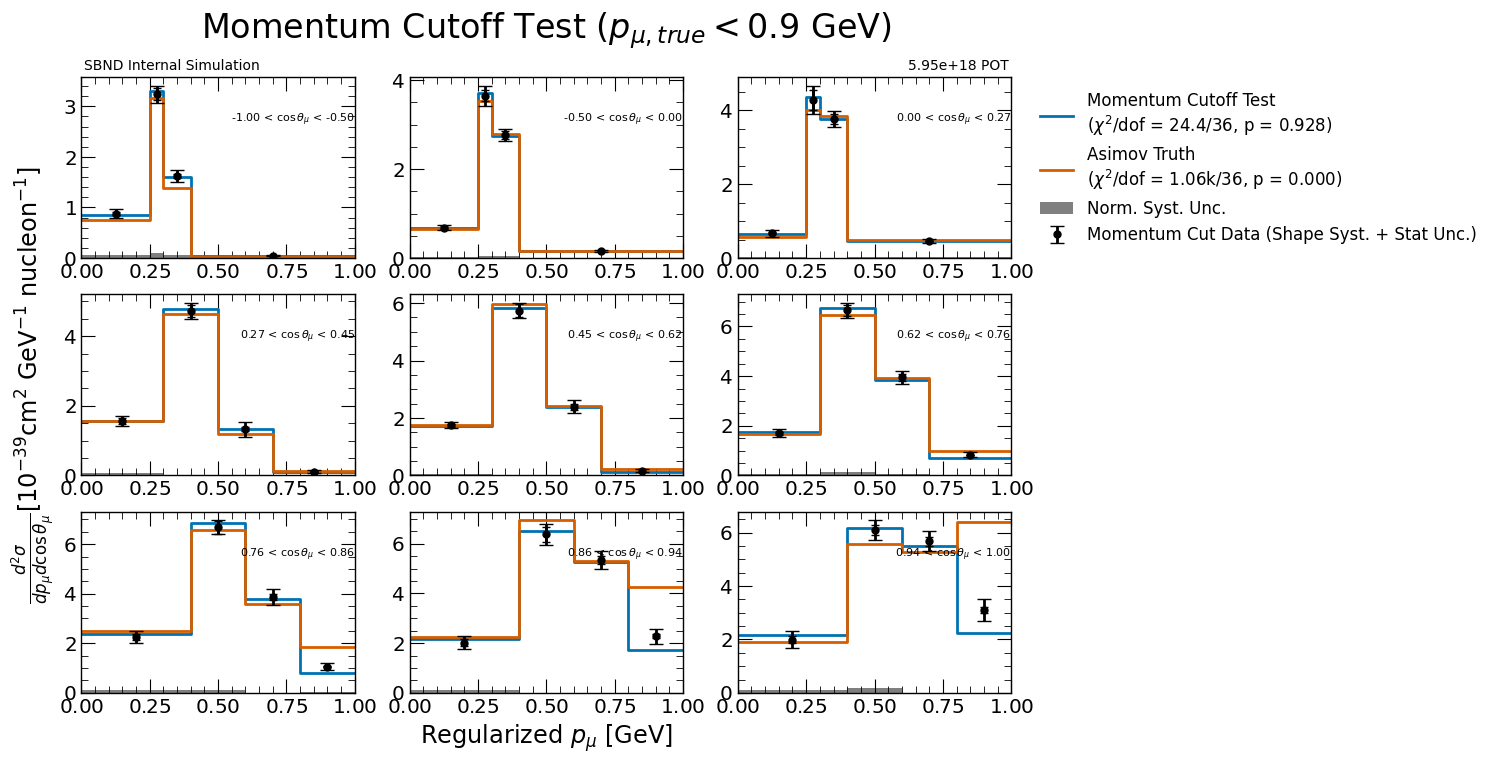

In [93]:
fig,axs = xsec_differential.plot_unfold_2d(names, model_labels, binning2D, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('momentum_cutoff_unfold_differential',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

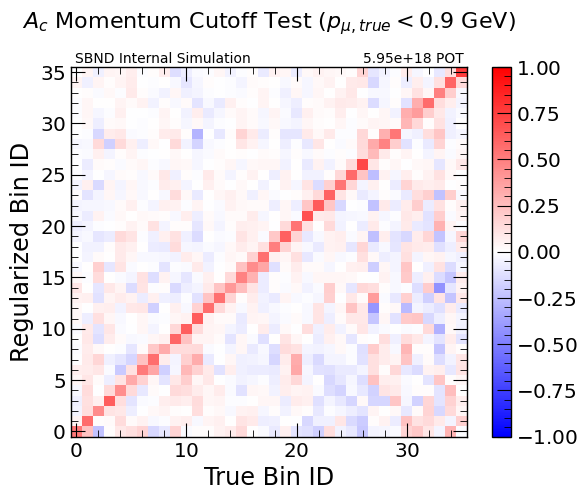

In [94]:
fig,ax = xsec_differential.plot_smear('momcut', title=r'$A_c$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('momentum_ac_cutoff_differential',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

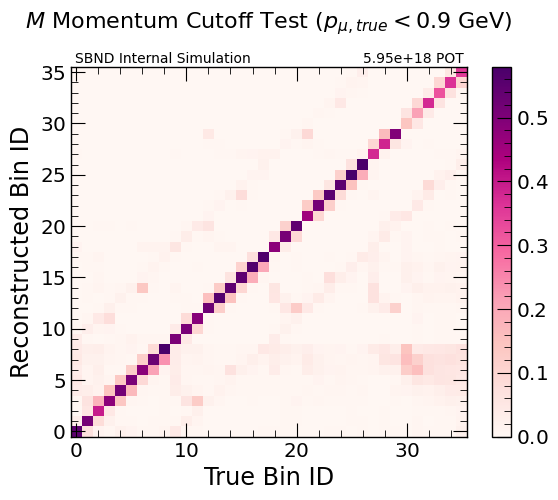

In [95]:
fig,ax = xsec_differential.plot_response('momcut', title=r'$M$ ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL)
plotters.save_plot('momentum_cutoff_response_differential',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

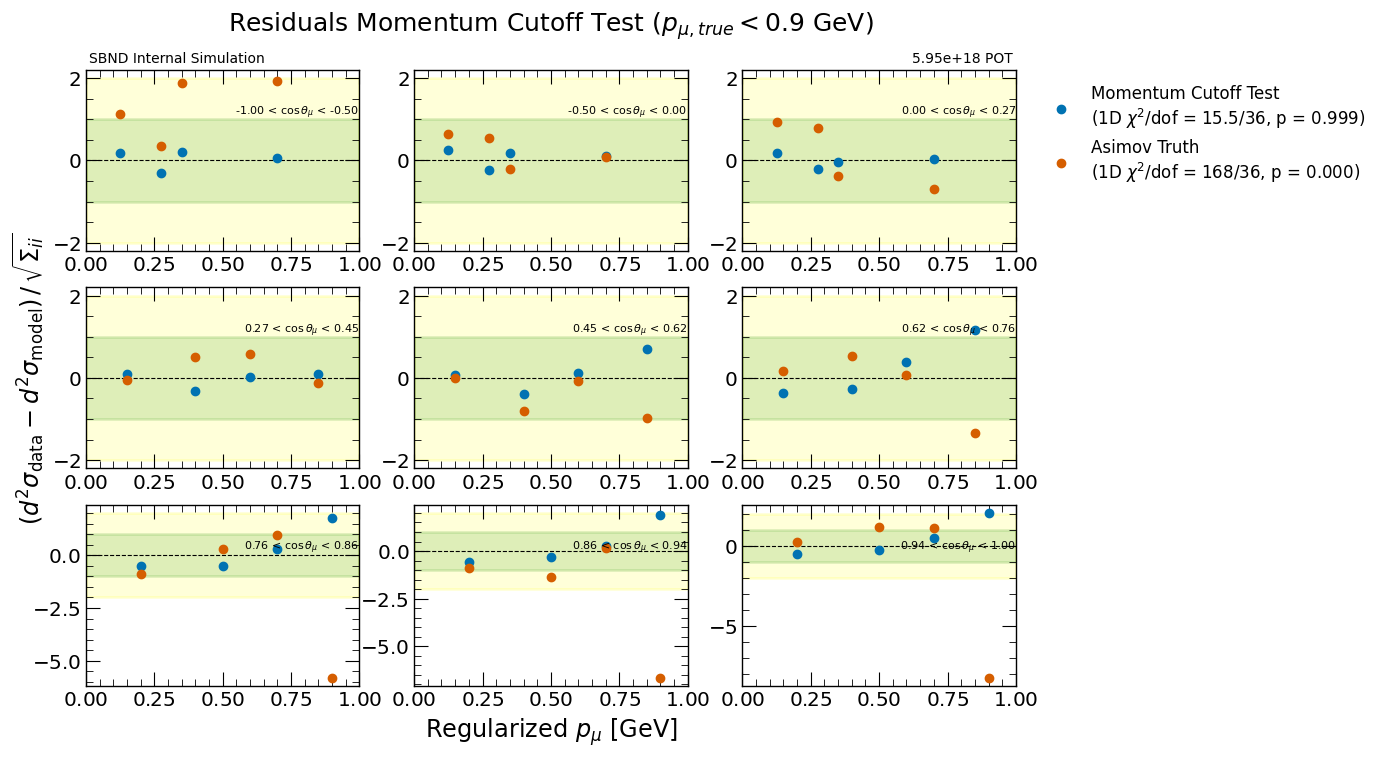

In [96]:
fig,ax = xsec_differential.plot_residuals_2d(names,model_labels, binning2D, title='Residuals ' + title, label=INTERNAL_LABEL, pot_label=POT_LABEL, verbose=False)
plotters.save_plot('momentum_cutoff_residuals_differential',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

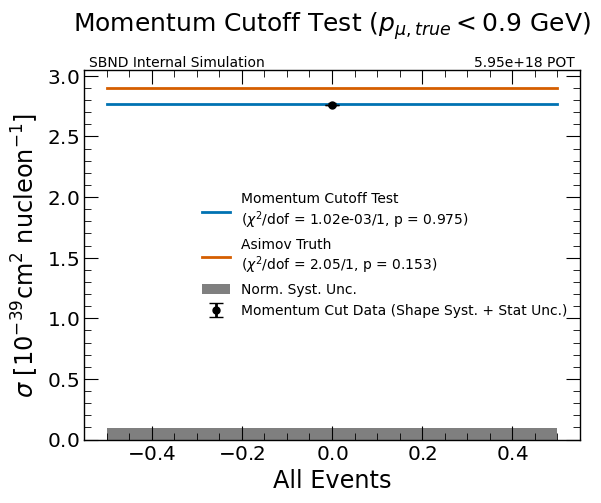

In [97]:
fig,ax = xsec_overall.plot_unfold(names, model_labels, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('momentum_cutoff_unfold_overall',fig=fig,folder_name=f'{PLOT_DIR}/momentum_cutoff')

### 2.5 Save everything for reproducibility

In [98]:
SAVE_DIR

'/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/checkpoint7_xsec_contsig2/xsec'

In [99]:
for xsec in [xsec_costheta,xsec_momentum,xsec_differential,xsec_overall]:
  xsec.save(SAVE_DIR)
  xsec.to_nuisance(SAVE_DIR)

## 3. Data

In [100]:
def make_bogus_cov(n,diag_frac=0.1**2,offdiag_frac=0.05**2):
  """
  Make a bogus fractional covariance matrix with n bins
  """
  print(f'diag_frac: {diag_frac}, offdiag_frac: {offdiag_frac}')
  cov = np.eye(n)
  diag = np.array([diag_frac]*n)
  offdiag = np.array([offdiag_frac]*(n*(n-1)//2))
  cov = np.diag(np.sqrt(diag)) @ cov @ np.diag(np.sqrt(diag))
  cov[np.triu_indices(n,k=1)] = offdiag
  cov[np.tril_indices(n,k=-1)] = offdiag
  return cov


In [101]:
dumbycov = False
use_statonly = False
names = ['data']
title = 'Data'
tikhonov = False
use_fraccov = False
use_AR23 = False # This uses only AR23, not the additional systs
####
# Note: I was using frac cov for only costheta before, now I'm using it for none of them
# This impacts results in compared to the v4 tech note, but is very minor
####

if use_statonly:
  if use_AR23:
    raise ValueError('AR23 and statonly cannot both be True')
  xsec_key = 'stat'
  model_labels = ['GENIE v3 Stat Only']
elif use_AR23:
  xsec_key = 'total_AR23'
  model_labels = ['GENIE v3 AR23']
else:
  xsec_key = 'total'
  model_labels = ['GENIE v3 AR23+']

cov_key = 'xsec_fraccov' if use_fraccov else 'xsec_cov'
xsec_cov_costheta = csystematics_rw.systematics[xsec_key][cov_key]
xsec_cov_costheta_stat = csystematics_rw.systematics['stat'][cov_key]

xsec_cov_momentum = msystematics_rw.systematics[xsec_key][cov_key]
xsec_cov_momentum_stat = msystematics_rw.systematics['stat'][cov_key]

xsec_cov_differential = dsystematics_rw.systematics[xsec_key][cov_key][1:,1:]
xsec_cov_differential_stat = dsystematics_rw.systematics['stat'][cov_key][1:,1:]

if use_statonly:
  if use_AR23:
    raise ValueError('AR23 and statonly cannot both be True')
  save_suffix = '_statonly'
elif use_AR23:
  save_suffix = '_AR23'
else:
  save_suffix = ''
print('*'*50)
print(f'Using xsec_key: {xsec_key}')
print(f'Using model_labels: {model_labels}')
print(f'Frac cov? {use_fraccov}')
print('*'*50)

if dumbycov:
  xsec_cov_costheta = make_bogus_cov(xsec_cov_costheta.shape[0])
  xsec_cov_momentum = make_bogus_cov(xsec_cov_momentum.shape[0])
  xsec_cov_differential = make_bogus_cov(xsec_cov_differential.shape[0])
  save_suffix = '_dumbycov'

#Costheta
xsec_costheta.unfold(xsec_cov_costheta,  #fractional covariance
  costheta_sel_sig_data, #selection
  costheta_sig, #signal
  #sel_background=costheta_sel_bkg_reco, #background
  sigma_tilde=xsec_costheta.unfold_results['asimov']['sigma_tilde'],
  name='data',
  response=xsec_costheta.unfold_results['asimov']['response'],
  fractional_cov=use_fraccov, #fractional covariance
  stat_cov=xsec_cov_costheta_stat,
  C_type=C_type, Norm_type=Norm_type,
  tikhonov=tikhonov,
  verbose=False)

#Overall
xsec_cov_overall = np.array([[np.sum(xsec_costheta.unfold_results['data']['input_cov'])]])
xsec_cov_stat_overall = np.array([[np.sum(xsec_costheta.unfold_results['data']['input_stat_cov'])]])
xsec_overall.unfold(xsec_cov_overall,  #covariance
  overall_sel_sig_data, #selection
  overall_sig, #signal
  overall_sel_bkg, #background
  name='data',
  response=xsec_overall.unfold_results['asimov']['response'],
  stat_cov=xsec_cov_stat_overall,
  C_type=C_type, Norm_type=Norm_type,
  tikhonov=tikhonov,
  verbose=False,
  fractional_cov=False)

xsec_momentum.unfold(xsec_cov_momentum,  #fractional covariance
  momentum_sel_sig_data, #selection
  momentum_sig, #signal
  #sel_background=momentum_sel_bkg_reco, #background
  sigma_tilde=xsec_momentum.unfold_results['asimov']['sigma_tilde'],
  name='data',
  response=xsec_momentum.unfold_results['asimov']['response'],
  fractional_cov=use_fraccov, #fractional covariance
  stat_cov=xsec_cov_momentum_stat,
  C_type=C_type, Norm_type=Norm_type,
  tikhonov=tikhonov,
  verbose=False)

xsec_differential.unfold(xsec_cov_differential,  #fractional covariance
  diff_sel_sig_data, #selection
  diff_sig, #signal
  #sel_background=diff_sel_bkg_reco, #background
  sigma_tilde=xsec_differential.unfold_results['asimov']['sigma_tilde'],
  name='data',
  response=xsec_differential.unfold_results['asimov']['response'],
  fractional_cov=use_fraccov, #fractional covariance
  stat_cov=xsec_cov_differential_stat,
  C_type=C_type, Norm_type=Norm_type,
  tikhonov=tikhonov,
  verbose=False)

**************************************************
Using xsec_key: total
Using model_labels: ['GENIE v3 AR23+']
Frac cov? False
**************************************************


In [102]:
from naming import *

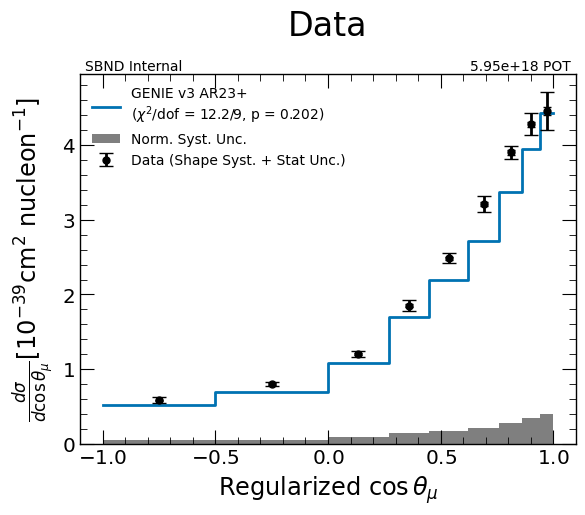

In [103]:
fig,ax = xsec_costheta.plot_unfold(names,model_labels,title=title,label=INTERNAL_DATA_LABEL,pot_label=POT_LABEL)
plotters.save_plot(f'data_unfold_costheta{save_suffix}',fig=fig,folder_name=f'{PLOT_DIR}/data')

In [104]:
xsec_costheta.unfold_results['data']['fracunc']*100

array([10.99408485,  7.63776439,  8.14016157,  8.5813259 ,  7.31463182,
        7.35799511,  7.61913245,  8.88968623, 10.63946259])

In [105]:
xsec_costheta.unfold_results['data']['chi2'],xsec_costheta.unfold_results['data']['chi2_1d']

(12.211268184480382, 17.397118808917)

In [106]:
xsec_costheta.unfold_results['data']['fracunc_unfold_shape']*100

array([6.44529806, 3.20143955, 3.35220065, 3.80610417, 2.72056643,
       3.32499612, 2.14856162, 3.41037941, 5.76242264])

In [107]:
xsec_costheta.unfold_results['data']['fracunc_unfold_norm']*100

array([8.90662869, 6.93442354, 7.41788253, 7.69108089, 6.78987164,
       6.56387788, 7.30991534, 8.20949654, 8.94386099])

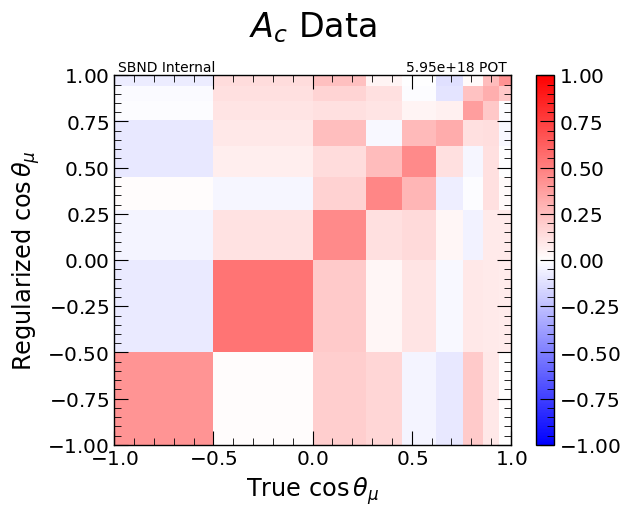

In [108]:
fig,ax = xsec_costheta.plot_smear('data', title=r'$A_c$ ' + title, label=INTERNAL_DATA_LABEL, pot_label=POT_LABEL)
plotters.save_plot(f'data_ac_costheta{save_suffix}',fig=fig,folder_name=f'{PLOT_DIR}/data')

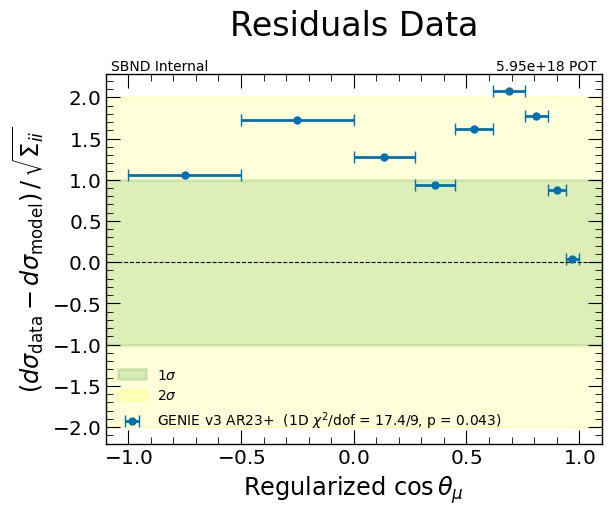

In [109]:
fig,ax = xsec_costheta.plot_residuals(names,model_labels, title='Residuals ' + title, label=INTERNAL_DATA_LABEL, pot_label=POT_LABEL, verbose=False)
plotters.save_plot(f'data_residuals_costheta{save_suffix}',fig=fig,folder_name=f'{PLOT_DIR}/data')

Text(0, 0.5, 'Regularized $\\cos\\theta_\\mu$')

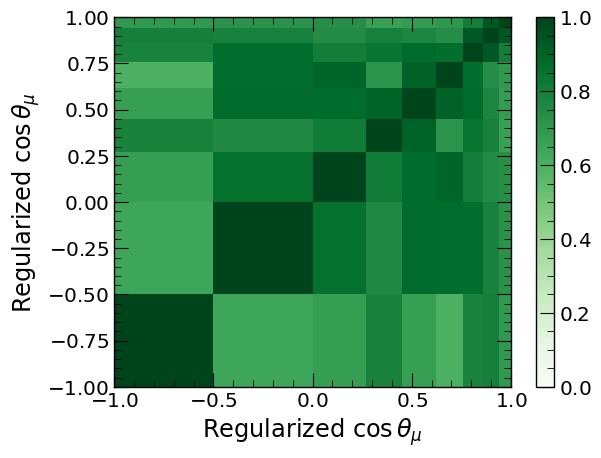

In [110]:
#Plot correlation matrix
fig,ax = plt.subplots()
im = ax.pcolormesh(xsec_costheta.bins,xsec_costheta.bins,xsec_costheta.unfold_results['data']['unfold_corr'],
    vmin=0, vmax=1)
fig.colorbar(im, ax=ax)
ax.set_xlabel(xsec_costheta.regularized_label)
ax.set_ylabel(xsec_costheta.regularized_label)

Text(0.5, 1.0, 'Input Covariance')

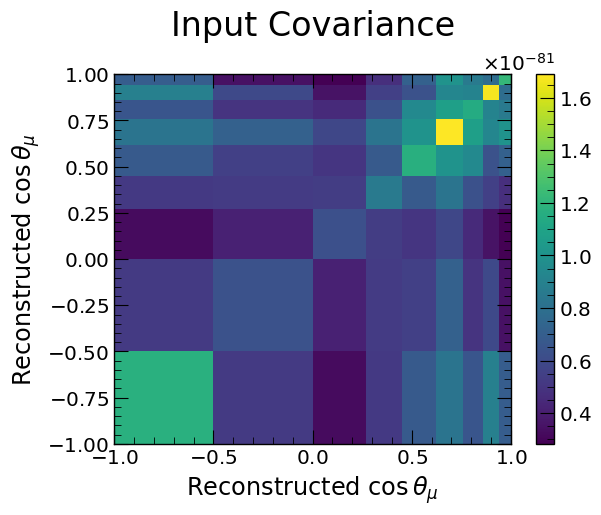

In [111]:
# Plot the input covariance
fig,ax = plt.subplots()
im = ax.pcolormesh(xsec_costheta.bins,xsec_costheta.bins,xsec_cov_costheta,cmap='viridis')
fig.colorbar(im, ax=ax)
ax.set_xlabel(xsec_costheta.reco_label)
ax.set_ylabel(xsec_costheta.reco_label)
ax.set_title('Input Covariance')

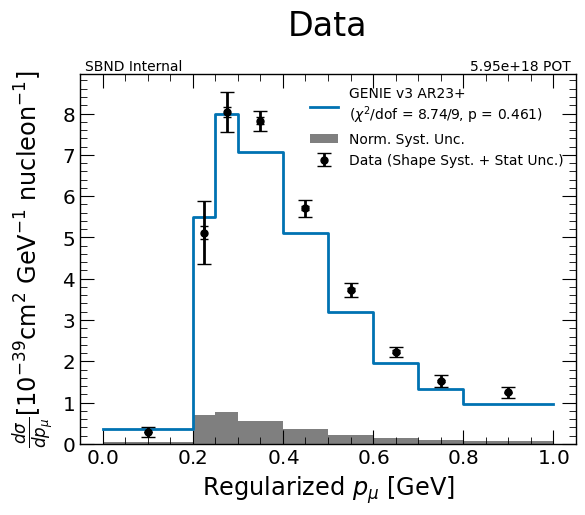

In [112]:
fig,ax = xsec_momentum.plot_unfold(names,model_labels,title=title,label=INTERNAL_DATA_LABEL,pot_label=POT_LABEL)
plotters.save_plot(f'data_unfold_momentum{save_suffix}',fig=fig,folder_name=f'{PLOT_DIR}/data')

In [113]:
xsec_momentum.unfold_results['data']['chi2'],xsec_momentum.unfold_results['data']['chi2_1d']

(8.742003494884802, 15.203215677090684)

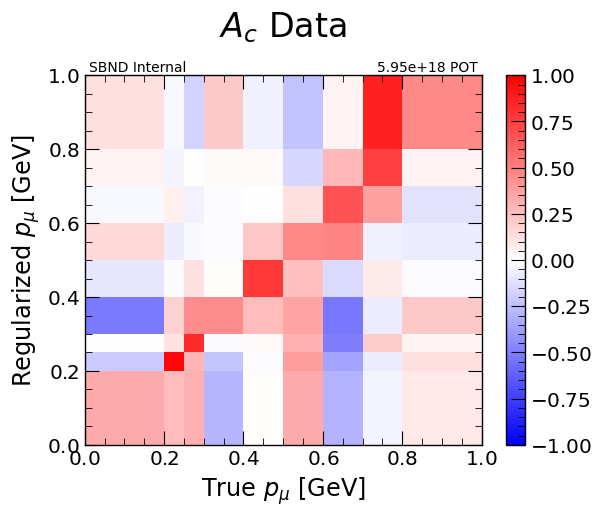

In [114]:
fig,ax = xsec_momentum.plot_smear('data', title=r'$A_c$ ' + title, label=INTERNAL_DATA_LABEL, pot_label=POT_LABEL)
plotters.save_plot(f'data_ac_momentum{save_suffix}',fig=fig,folder_name=f'{PLOT_DIR}/data')

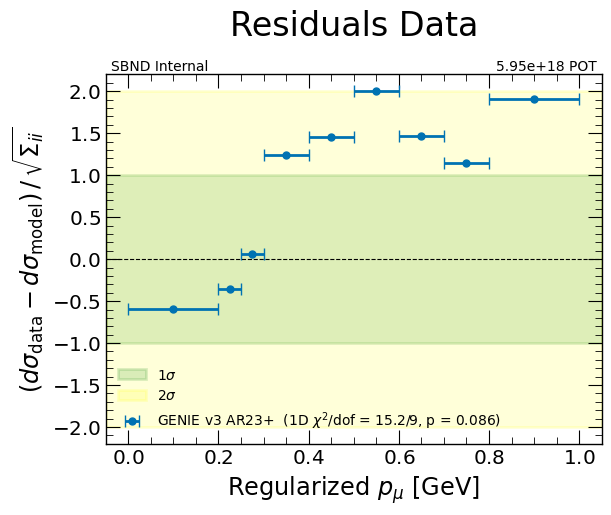

In [115]:
fig,ax = xsec_momentum.plot_residuals(names,model_labels, title='Residuals ' + title, label=INTERNAL_DATA_LABEL, pot_label=POT_LABEL, verbose=False)
plotters.save_plot(f'data_residuals_momentum{save_suffix}',fig=fig,folder_name=f'{PLOT_DIR}/data')

Text(0, 0.5, 'Regularized $p_\\mu$ [GeV]')

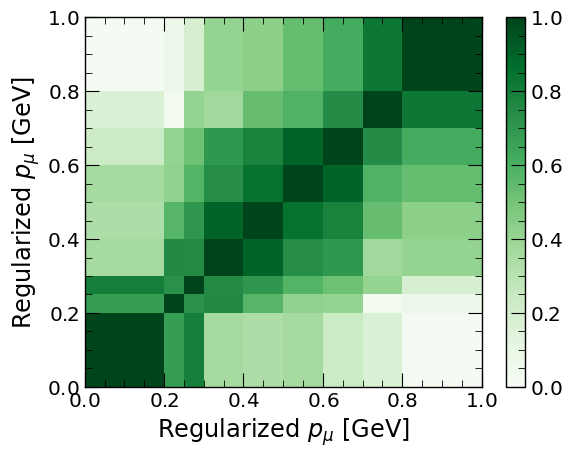

In [116]:
# Plot correlation 
fig,ax = plt.subplots()
im = ax.pcolormesh(xsec_momentum.bins,xsec_momentum.bins,xsec_momentum.unfold_results['data']['unfold_corr'],
    vmin=0, vmax=1)
fig.colorbar(im, ax=ax)
ax.set_xlabel(xsec_momentum.regularized_label)
ax.set_ylabel(xsec_momentum.regularized_label)
#ax.set_title('Test 6: Systematic Correlation Matrix')
#plotters.save_plot('test6_corr', fig=fig, folder_name=PLOT_DIR)


In [117]:
xsec_momentum.unfold_results['data']['residuals_norm']

array([-0.59911332, -0.35345642,  0.06275754,  1.23471083,  1.45108428,
        2.00068432,  1.46477967,  1.14569802,  1.90376242])

In [118]:
xsec_momentum.unfold_results['data']['fracunc']

array([0.45001728, 0.20130815, 0.11410683, 0.07841363, 0.07193207,
       0.07376536, 0.08334537, 0.1133153 , 0.11831385])

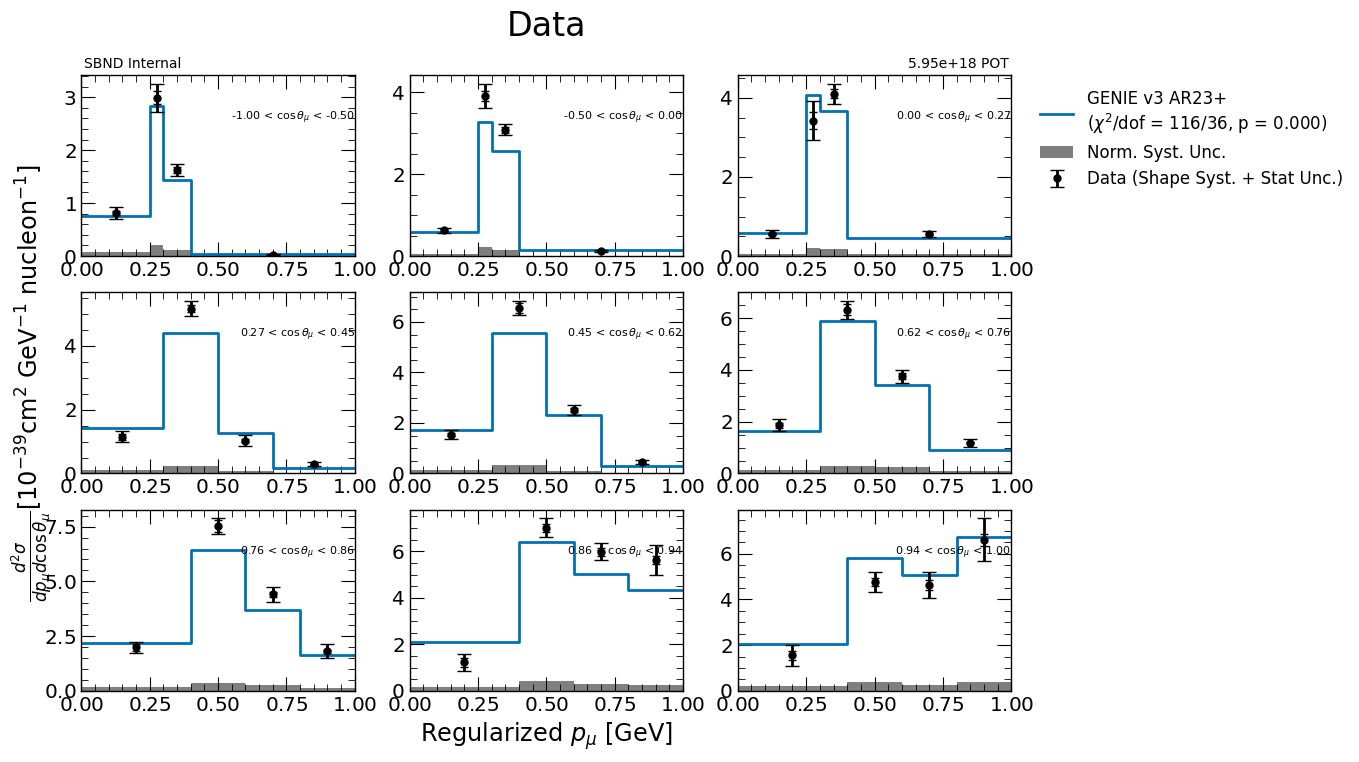

In [119]:
fig,axs = xsec_differential.plot_unfold_2d(names,model_labels,binning2D,title='Data',label=INTERNAL_DATA_LABEL,pot_label=POT_LABEL,data_label='Data')
plotters.save_plot(f'data_unfold_differential{save_suffix}',fig=fig,folder_name=f'{PLOT_DIR}/data')

In [120]:
xsec_differential.unfold_results['data']['chi2'],xsec_differential.unfold_results['data']['chi2_1d']

(115.79887760189693, 73.0725217917648)

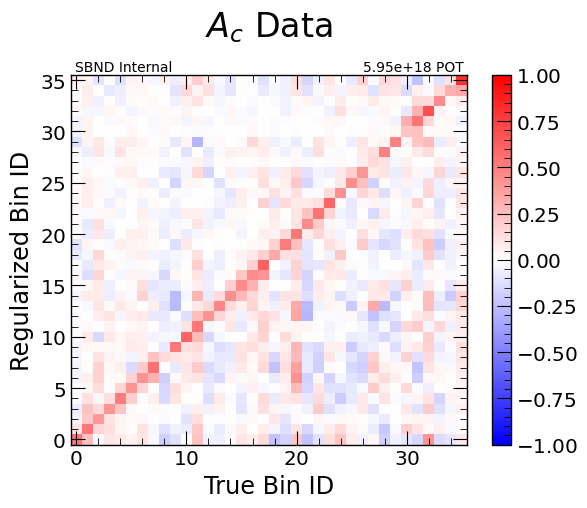

In [121]:
fig,ax = xsec_differential.plot_smear('data', title=r'$A_c$ ' + title, label=INTERNAL_DATA_LABEL, pot_label=POT_LABEL)
plotters.save_plot(f'data_ac_differential{save_suffix}',fig=fig,folder_name=f'{PLOT_DIR}/data')

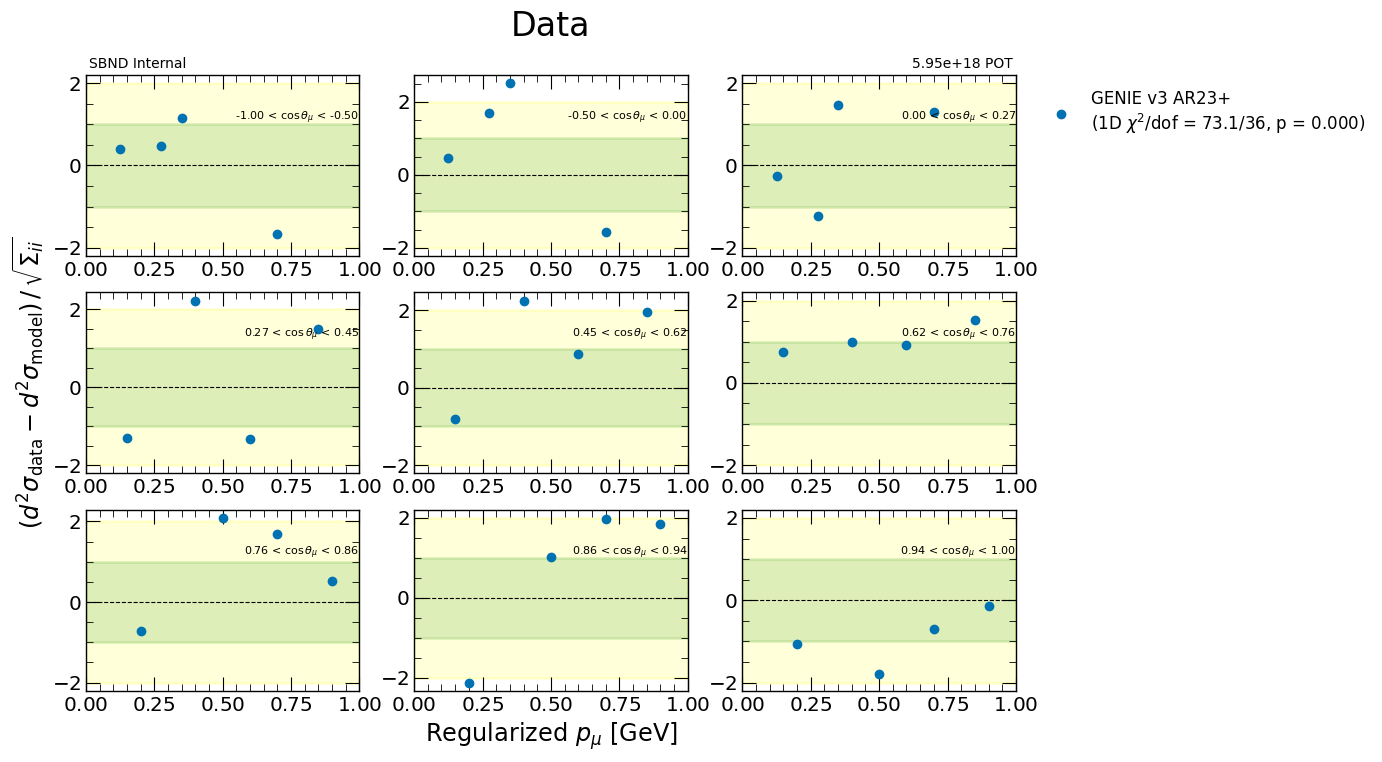

In [122]:
fig,axs = xsec_differential.plot_residuals_2d(names,model_labels,binning2D,title='Data',label=INTERNAL_DATA_LABEL,pot_label=POT_LABEL,verbose=True)
plotters.save_plot(f'data_residuals_differential{save_suffix}',fig=fig,folder_name=f'{PLOT_DIR}/data')

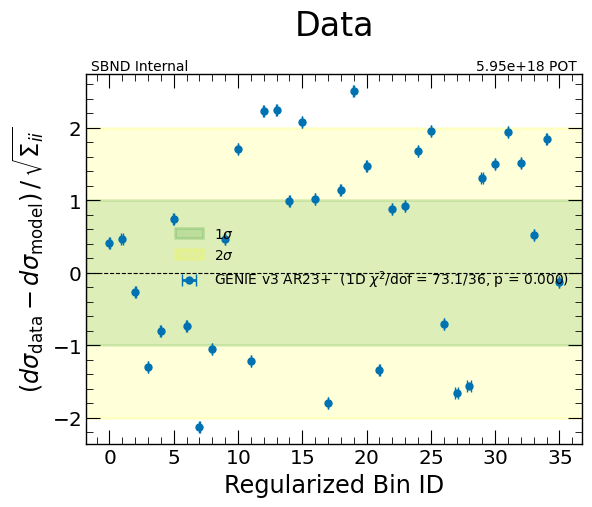

In [123]:
fig,axs = xsec_differential.plot_residuals(names,model_labels,title='Data',label=INTERNAL_DATA_LABEL,pot_label=POT_LABEL,verbose=True)
plotters.save_plot(f'data_residuals_differential_1d{save_suffix}',fig=fig,folder_name=f'{PLOT_DIR}/data')

Text(0, 0.5, 'Regularized Bin ID')

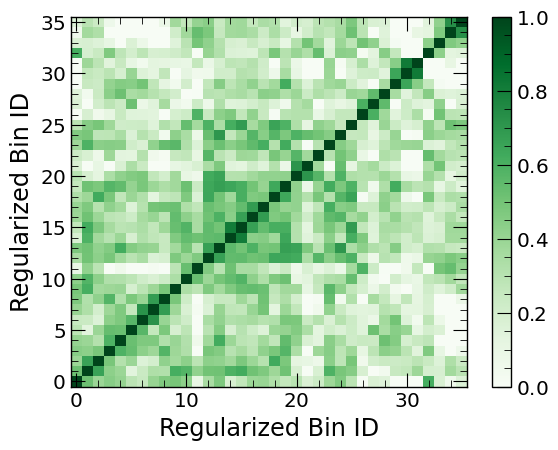

In [124]:
#Plot correlation matrix
fig,ax = plt.subplots()
im = ax.pcolormesh(xsec_differential.bins,xsec_differential.bins,xsec_differential.unfold_results['data']['unfold_corr'],
    vmin=0, vmax=1)
fig.colorbar(im, ax=ax)
ax.set_xlabel(xsec_differential.regularized_label)
ax.set_ylabel(xsec_differential.regularized_label)

Text(0, 0.5, 'Regularized Bin ID')

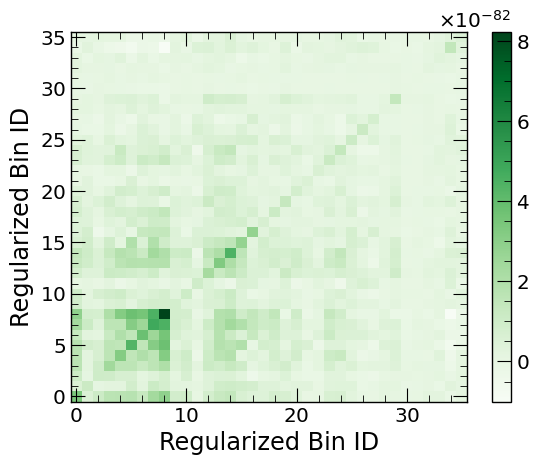

In [125]:
#Plot correlation matrix
fig,ax = plt.subplots()
im = ax.pcolormesh(xsec_differential.bins,xsec_differential.bins,xsec_differential.unfold_results['data']['input_cov'])
fig.colorbar(im, ax=ax)
ax.set_xlabel(xsec_differential.regularized_label)
ax.set_ylabel(xsec_differential.regularized_label)

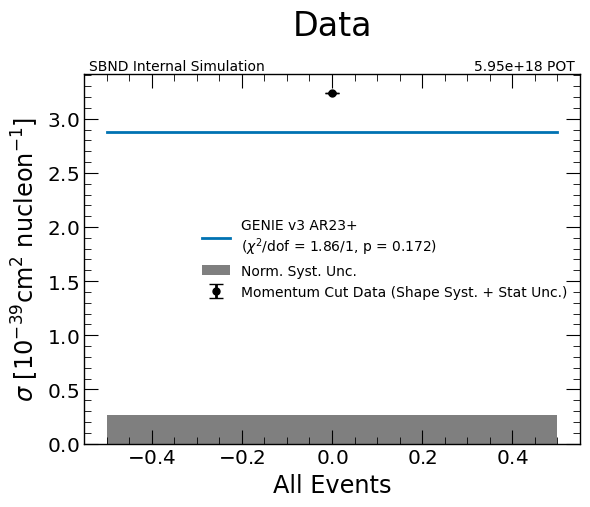

In [126]:
fig,ax = xsec_overall.plot_unfold(names, model_labels, title=title, label=INTERNAL_LABEL, pot_label=POT_LABEL, data_label=data_label)
plotters.save_plot('data_unfold_overall',fig=fig,folder_name=f'{PLOT_DIR}/data')

### 3.1. Construct p-value, chi2 table

In [127]:
for xsec in [xsec_costheta,xsec_momentum,xsec_differential,xsec_overall]:
  print('*'*25,xsec.variable,'*'*25)
  print(f"chi2: {xsec.unfold_results['data']['chi2']:.3f}, dof: {xsec.unfold_results['data']['dof']}, pval: {xsec.unfold_results['data']['pval']:.3e}, sigma: {xsec.unfold_results['data']['sigma']:.3f}")


************************* costheta *************************
chi2: 12.211, dof: 9, pval: 2.017e-01, sigma: 0.836
************************* momentum *************************
chi2: 8.742, dof: 9, pval: 4.614e-01, sigma: 0.097
************************* differential *************************
chi2: 115.799, dof: 36, pval: 2.605e-10, sigma: 6.213
************************* overall *************************
chi2: 1.864, dof: 1, pval: 1.722e-01, sigma: 0.946


### 3.2 Save

In [128]:
for xsec in [xsec_costheta,xsec_momentum,xsec_differential,xsec_overall]:
  xsec.save(SAVE_DIR)
  xsec.to_nuisance(SAVE_DIR)

## Testing

In [159]:
# Test the uncontained measurement
stat_dict = {
  'costheta': {
    'chi2': [],
    'dof': [],
    'pval': [],
    'sigma': []
  },
}
stats_dict = {
  'costheta': {**stat_dict.copy()},
  'momentum': {**stat_dict.copy()},
  'differential': {**stat_dict.copy()}
}

In [160]:
#Filled from uncontained result
stats_dict['costheta']['chi2'] = 51.5
stats_dict['costheta']['dof'] = 8
stats_dict['momentum']['chi2'] = 106
stats_dict['momentum']['dof'] = 7
stats_dict['differential']['chi2'] = 191
stats_dict['differential']['dof'] = 35

In [162]:
from scipy.stats import norm
from scipy.stats import chi2
for key,vals in stats_dict.items():
  vals['pval'] = chi2.sf(vals['chi2'],vals['dof'])
  vals['sigma'] = norm.isf(vals['pval'])

In [164]:
for key,vals in stats_dict.items():
  print('*'*25,key,'*'*25)
  print(f"chi2: {vals['chi2']:.3f}, dof: {vals['dof']}, pval: {vals['pval']:.3e}, sigma: {vals['sigma']:.3f}")

************************* costheta *************************
chi2: 51.500, dof: 8, pval: 2.102e-08, sigma: 5.482
************************* momentum *************************
chi2: 106.000, dof: 7, pval: 6.196e-20, sigma: 9.066
************************* differential *************************
chi2: 191.000, dof: 35, pval: 2.206e-23, sigma: 9.894


In [165]:
sel_sig_datas = [costheta_sel_sig_data,momentum_sel_sig_data,diff_sel_sig_data]
sig_datas = [costheta_sig,momentum_sig,diff_sig]
xsec_covs = [xsec_cov_costheta,xsec_cov_momentum,xsec_cov_differential]
xsec_stat_covs = [xsec_cov_costheta_stat,xsec_cov_momentum_stat,xsec_cov_differential_stat]

chi2s = { 
  'costheta': {'2d': [],'1d': []},
  'momentum': {'2d': [],'1d': []},
  'differential': {'2d': [],'1d': []}
}
# Test which bins contribute the most to the chi2
for j,xsec in tqdm(enumerate([xsec_costheta,xsec_momentum,xsec_differential])):
  for i in tqdm(range(xsec_cov_differential.shape[0])):
    if i > xsec.unfold_results['data']['input_cov'].shape[0]:
      chi2s[xsec.variable]['2d'].append(xsec.unfold_results['data']['chi2'])
      chi2s[xsec.variable]['1d'].append(xsec.unfold_results['data']['chi2_1d'])
      break
    mask_bins = [i]
    name = f'data_masked_{i}'
    xsec.unfold(xsec_covs[j],  #fractional covariance
      sel_sig_datas[j], #selection
      sig_datas[j], #signal
      #sel_background=costheta_sel_bkg_reco, #background
      sigma_tilde=xsec.unfold_results['asimov']['sigma_tilde'],
      name=name,
      response=xsec.unfold_results['asimov']['response'],
      fractional_cov=use_fraccov, #fractional covariance
      stat_cov=xsec_stat_covs[j],
      C_type=C_type, Norm_type=Norm_type,
      tikhonov=tikhonov,
      mask_bins=mask_bins,
      verbose=False)
    chi2s[xsec.variable]['2d'].append(xsec.unfold_results[name]['chi2'])
    chi2s[xsec.variable]['1d'].append(xsec.unfold_results[name]['chi2_1d'])



100%|██████████| 36/36 [00:01<00:00, 34.28it/s]
3it [00:01,  2.65it/s]


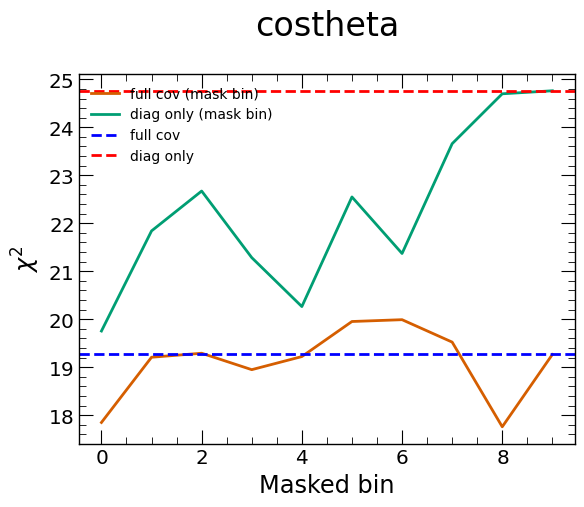

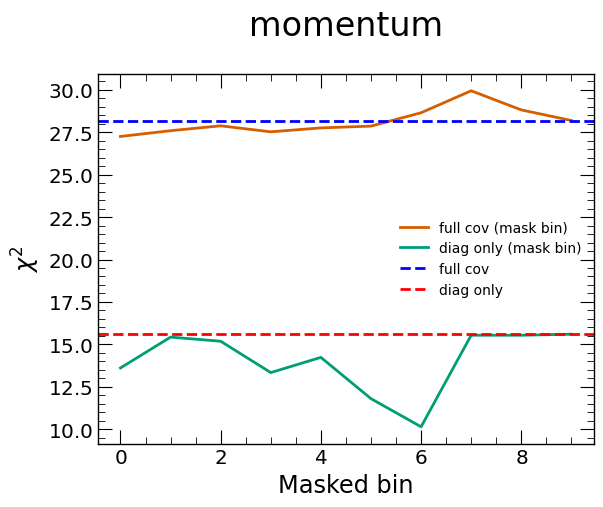

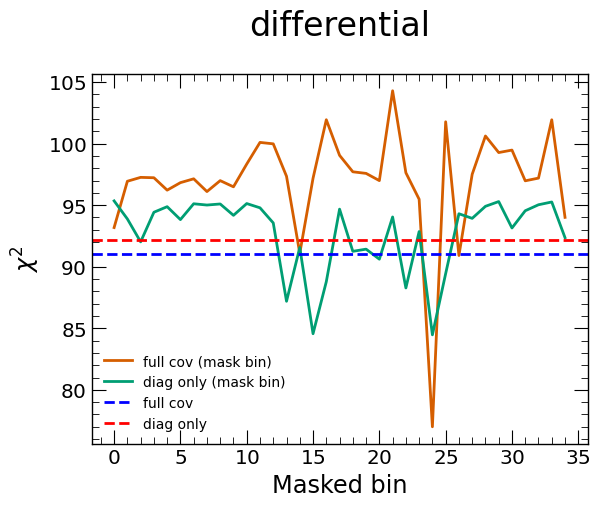

In [167]:
for key,vals in chi2s.items():
  fig,ax = plt.subplots()
  # All but last bin
  ax.plot(vals['2d'][:-1],label='full cov (mask bin)')
  ax.plot(vals['1d'][:-1],label='diag only (mask bin)')
  # Last bin is the chi2 from the full cov
  ax.axhline(vals['2d'][-1],color='b',linestyle='--',label='full cov')
  ax.axhline(vals['1d'][-1],color='r',linestyle='--',label='diag only')
  ax.set_ylabel(r'$\chi^2$')
  ax.set_xlabel('Masked bin')
  ax.legend()
  ax.set_title(key)



In [1022]:
fname = '/exp/sbnd/data/users/lynnt/xsection/for_bear/energy_cov.npy'
fname = '/exp/sbnd/data/users/lynnt/xsection/for_bear/angle_cov.npy'
energy_cov = np.load(fname)
eigvals, eigvecs, cond, min_eig, max_eig = stats._cov_eigenvalue_diagnostics(energy_cov)

In [1023]:
max_eig/min_eig

58.276911961258826

In [1024]:
my_cov = xsec_momentum.unfold_results['mec']['unfold_cov']
eigvals, eigvecs, cond, min_eig, max_eig = stats._cov_eigenvalue_diagnostics(my_cov)


In [1025]:
max_eig/min_eig


7177.045139142987

In [ ]:
fname = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/mc_syst/v6/mc_smallpand_nosyst_nocuts_recomb.df'
df = pd.read_hdf(fname,key='trk_0')
df

In [ ]:
df.pfp.trk.chi2pid

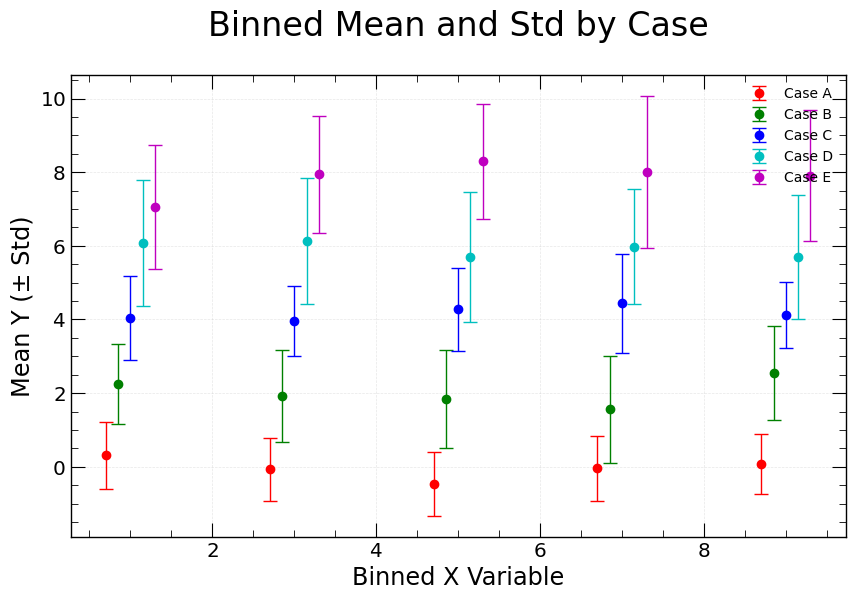

In [68]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic

# 1. Generate synthetic data (5 cases)
np.random.seed(42)
n_points = 100
x = np.random.uniform(0, 10, n_points)
cases = ['Case A', 'Case B', 'Case C', 'Case D', 'Case E']
colors = ['r', 'g', 'b', 'c', 'm']
bins = np.linspace(0, 10, 6) # 5 bins

plt.figure(figsize=(10, 6))

# 2. Binning and plotting with offset
for i, case in enumerate(cases):
    # Generate random y-data for each case
    y = np.random.normal(loc=i*2, scale=1 + i*0.2, size=n_points)
    
    # Calculate binned mean and std
    bin_means, _, _ = binned_statistic(x, y, statistic='mean', bins=bins)
    bin_std, _, _ = binned_statistic(x, y, statistic='std', bins=bins)
    
    # Calculate bin centers
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Apply offset to x-position for each case
    offset = (i - 2) * 0.15 
    x_offset = bin_centers + offset
    
    # Plot errorbars
    plt.errorbar(x_offset, bin_means, yerr=bin_std, fmt='o', 
                 label=case, capsize=5, color=colors[i], elinewidth=1)

plt.xlabel('Binned X Variable')
plt.ylabel('Mean Y (± Std)')
plt.title('Binned Mean and Std by Case')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
folder = '/exp/sbnd/data/users/brindenc/analyze_sbnd/numu/v10_06_00_validation/pandora/data/2026_02_12/syst/lowz'
_csytematics = Systematics.from_saved(folder,'costheta',metadata_dir='metadata_detsys',n_cpus=80)

In [ ]:
#sys_dict = _csytematics.systematics['GENIE']
sys_dict = csystematics_rw.systematics['']
xsec_cv = sys_dict['sigma_tilde']
sigma_tilde_list = np.array([s for s in sys_dict['sigma_tilde'] if s is not None])
# Make a sigma_tilde_list twice the size
sigma_tilde_list2 = np.concatenate([sigma_tilde_list, sigma_tilde_list])

In [ ]:
_xsec_fracunc

In [ ]:
plt.imshow(_xsec_cov_unaltered*160)
plt.colorbar()

In [ ]:
#Test that xsec is able to dump into a file readable by NUISANCE
uboone_fname = '/exp/sbnd/app/users/brindenc/develop/nuisance_area/nuisance/data/MicroBooNE/CCinc/microboone_numu_cc_inclusive.root'
uboone_xsec = uproot.open(uboone_fname)

In [ ]:
for k in uboone_xsec.keys():
  print(f'{k}: {uboone_xsec[k]}')

In [ ]:
uboone_xsec['covariance_matrix']

In [ ]:
sys.path